In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# Introduction

Sleep gets talked about constantly in health circles, but in day-to-day clinical practice it's often the last thing anyone actually measures. Insomnia and sleep apnea are both linked to cardiovascular and metabolic problems, yet how sleep actually interacts with lifestyle and physiology remains fairly murky, especially once you try to look at it through a data-driven lens.

We use the Sleep Health and Lifestyle Dataset from Kaggle: 374 synthetic records, 13 variables. It covers demographics (age, gender, occupation), behavioural factors (physical activity, stress, daily steps), physiological measurements (BMI, blood pressure, heart rate) and sleep variables (duration, perceived quality, diagnosed disorder: none, insomnia, or sleep apnea). Since it's synthetic data, none of this can be assumed to generalise to a real clinical population without checking it against real-world data first.

We're not trying to build a classifier for the existing labels. Does the structure that emerges from the data on its own actually line up with those diagnoses? Someone with no diagnosis but high stress and poor sleep quality might end up sitting closer to the insomnia patients than to the healthy group; a sleep apnea patient who is physically active and has stable cardiovascular numbers might land somewhere else entirely. That's the question we're chasing.

In [2]:
! pip install pgmpy

In [3]:
! pip install kneed

In [4]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
from pgmpy.estimators.BaseConstraintEstimator import BaseConstraintEstimator
import warnings
warnings.simplefilter(action='ignore', category=DeprecationWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)
from itertools import chain, combinations
%matplotlib inline
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference import VariableElimination
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import fcluster
import numpy as np
from pgmpy.estimators import PC
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.express as px
from itertools import product
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.special import comb
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    pairwise_distances,
    jaccard_score,
    adjusted_rand_score,
    fowlkes_mallows_score
)
from sklearn.metrics.cluster import (
    contingency_matrix,
    homogeneity_score,
    completeness_score,
    v_measure_score,
)

np.random.seed(0)

from pgmpy.estimators import PC
from pgmpy.estimators import HillClimbSearch
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination
from pgmpy.metrics import SHD
from pgmpy.inference import ApproxInference

/usr/local/lib/python3.13/dist-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


In [5]:
# Custom functions for clustering plotting and evaluation
#####  Path K %run '/content/drive/MyDrive/Colab Notebooks/Unsupervised Learning/helper.ipynb'
#####  Path Angy %run '/content/drive/MyDrive/Unsupervised Learning/helper.ipynb'
%run '/content/drive/MyDrive/Unsupervised Learning/helper.ipynb'

# Loading the Dataset

We load the raw data into a pandas DataFrame . 13 attributes, 374 records.

Attributes:
- Nominal: Person ID, Gender, Occupation, Sleep Disorder, Blood Pressure (raw form,becomes ratio after we split it)
- Ordinal: Quality of Sleep, Stress Level, BMI Category
- Ratio: Age, Sleep Duration (hours/day), Physical Activity Level (minutes/day), Heart Rate (bpm), Daily Steps (steps/day)

In [6]:
#####  Path K %run '/content/drive/MyDrive/Colab Notebooks/Unsupervised Learning/'
#####  Path Angy %run '/content/drive/MyDrive/Unsupervised Learning/'
path = '/content/drive/MyDrive/Unsupervised Learning/'
sleep_data = pd.read_csv(path + "Sleep_health_and_lifestyle_dataset.csv")
sleep_data.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


# Data Pre-processing & Exploration

## Checking for Missing Values

Real data is never as clean as you'd like. This cell gives a quick boolean per column telling you which ones have at least one `NaN`. In this dataset, only `Sleep Disorder` has missing entries.

In [7]:
# Verify if there are more variables with NaNs
pd.isna(sleep_data).any()

,0
Person ID,False
Gender,False
Age,False
Occupation,False
Sleep Duration,False
Quality of Sleep,False
Physical Activity Level,False
Stress Level,False
BMI Category,False
Blood Pressure,False


## Imputing Missing Values in `Sleep Disorder`

The NaNs in `Sleep Disorder` aren't really missing in the usual sense,they just mean the person wasn't diagnosed with anything. That's a Missing Not At Random situation: the absence itself is informative, not noise. So instead of dropping rows or imputing statistically, we just fill `NaN` with `None`, which is what's actually going on.

In [8]:
sleep_data["Sleep Disorder"] = sleep_data["Sleep Disorder"].fillna("None")

## Separating Categorical and Numerical Attributes

We split off the categorical variables (no inherent numeric relationship between categories) from the numerical ones (usable directly once scaled). Keeping the two apart makes the encoding/scaling steps below much less messy to manage.

In [9]:
# List with the categorical variables
categorical_variables = ["Gender", "Occupation", "BMI Category", "Sleep Disorder"]

# List with the numeric variables
numeric_variables = [col for col in sleep_data.columns if col not in categorical_variables and col != "Person ID"]

## Encoding decision: Quality of Sleep and Stress Level

Both Quality of Sleep and Stress Level are ordinal variables measured on integer
scales (4–9 and 3–8, respectively). Strictly speaking, only order-preserving
operations (median, percentiles, rank correlation) are guaranteed to be valid
for ordinal data.

However, following common practice for Likert-type scales with a reasonably
high number of ordered levels, we assume approximately equal spacing between
consecutive values and treat both variables as pseudo-continuous. This allows
us to apply MinMaxScaler and use them directly in distance-based algorithms
(e.g., K-means, KNN) that internally rely on mean-based computations.

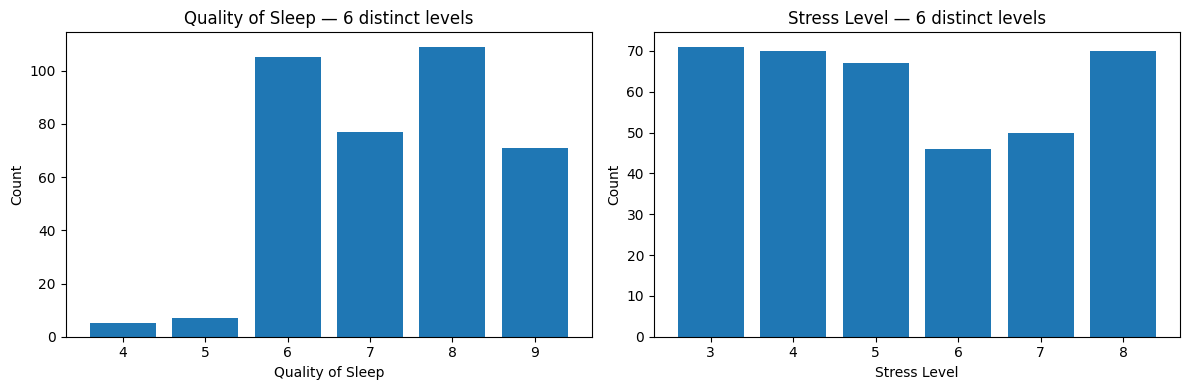


Quality of Sleep:
Quality of Sleep
4      5
5      7
6    105
7     77
8    109
9     71
  Distinct levels : 6
  Range           : 4 – 9

Stress Level:
Stress Level
3    71
4    70
5    67
6    46
7    50
8    70
  Distinct levels : 6
  Range           : 3 – 8


In [10]:
ordinal_candidates = ["Quality of Sleep", "Stress Level"]
analyze_ordinal_variables(sleep_data, ordinal_candidates)

To support this decision, we compared Pearson and Spearman correlation coefficients for these variables.

In [11]:
encoding_sensitivity_check(sleep_data, numeric_variables, ordinal_candidates , threshold=0.20)

Max absolute difference Spearman vs Pearson:
  Quality of Sleep: 0.0748  — ✓ continuous treatment justified
  Stress Level: 0.1503  — ✓ continuous treatment justified


,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
Age,0.000000,0.032340,0.055924,0.043313,0.003277,0.028758,0.099846
Sleep Duration,0.032340,0.000000,0.004185,0.003125,0.000390,0.092465,0.049619
Quality of Sleep,0.055924,0.004185,0.000000,0.014430,0.009395,0.074759,0.005988
Physical Activity Level,0.043313,0.003125,0.014430,0.000000,0.016637,0.023971,0.021252
Stress Level,0.003277,0.000390,0.009395,0.016637,0.000000,0.150270,0.015085
Heart Rate,0.028758,0.092465,0.074759,0.023971,0.150270,0.000000,0.123890
Daily Steps,0.099846,0.049619,0.005988,0.021252,0.015085,0.123890,0.000000


Stress Level has a non-trivial gap between its Spearman and Pearson correlation (0.15), mostly coming from its relationship with Heart Rate. We're keeping the continuous treatment anyway for consistency across variables, but the Stress Level–Heart Rate correlation is probably a bit underestimated by assuming linearity here.

# Categorical Variables

## Inspecting Cardinality of Categorical Variables

Before we encode anything, we check how many distinct levels each categorical variable has. Binary ones can just become a 0/1 column, low-cardinality ones are fine for one-hot encoding, and anything high-cardinality would need a different strategy so we don't blow up the number of dimensions.

In [12]:
#Which are and how many are the levels of our categorical variables
for variable in categorical_variables:
    values = sleep_data[variable].unique()
    print(f"{variable}: {values}, levels: {len(values)} \n")

Gender: ['Male' 'Female'], levels: 2 

Occupation: ['Software Engineer' 'Doctor' 'Sales Representative' 'Teacher' 'Nurse'
 'Engineer' 'Accountant' 'Scientist' 'Lawyer' 'Salesperson' 'Manager'], levels: 11 

BMI Category: ['Overweight' 'Normal' 'Obese' 'Normal Weight'], levels: 4 

Sleep Disorder: ['None' 'Sleep Apnea' 'Insomnia'], levels: 3 



## Binary Encoding of `Gender`

Only two levels here, so one 0/1 column does the job. One-hot encoding would instead give us two columns that always sum to 1: perfectly collinear, which breaks the full-rank assumption a lot of models rely on.

In [13]:
#Convert binary variables into 0-1
sleep_data['Gender'] = sleep_data['Gender'].replace({"Male": 0, "Female": 1})
sleep_data.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,0,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,2,0,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,3,0,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,4,0,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,0,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## Ordinal Encoding of `BMI Category`

`BMI Category` has a real medical ordering ,Normal < Overweight < Obese ,so ordinal encoding is the right call here, since one-hot would throw that ordering away and treat every level as equally different from every other. We merged `"Normal"` and `"Normal Weight"` into the same level (0), since that was just an inconsistent label in the raw data, not two different categories.

In [14]:
# Mapping values
bmi_mapping = {
    "Normal": 0,
    "Normal Weight": 0,
    "Overweight": 1,
    "Obese": 2
}

# Ordinal Encoding
sleep_data["BMI Category"] = sleep_data["BMI Category"].map(bmi_mapping)

## One-Hot Encoding of Nominal Attributes

`Occupation` has no natural ordering between its levels. Giving it arbitrary integers would invent a false sense of closeness between categories and mess up any distance-based algorithm downstream. One-hot avoids that: every occupation gets its own binary column, so all levels are equidistant in feature space ,which matters a lot for k-means or hierarchical clustering later. We cast from `bool` to `int` afterwards just so scikit-learn doesn't complain.

In [15]:
# Do one hot encoding
sleep_data = pd.get_dummies(sleep_data, columns=['Occupation'])

# Convert encoded columns from True/False to 0/1
bool_cols = sleep_data.select_dtypes(include='bool').columns
sleep_data[bool_cols] = sleep_data[bool_cols].astype(int)

sleep_data.head()


,Person ID,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,...,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher
0,1,0,27,6.1,6,42,6,1,126/83,77,...,0,0,0,0,0,0,0,0,1,0
1,2,0,28,6.2,6,60,8,0,125/80,75,...,1,0,0,0,0,0,0,0,0,0
2,3,0,28,6.2,6,60,8,0,125/80,75,...,1,0,0,0,0,0,0,0,0,0
3,4,0,28,5.9,4,30,8,2,140/90,85,...,0,0,0,0,0,1,0,0,0,0
4,5,0,28,5.9,4,30,8,2,140/90,85,...,0,0,0,0,0,1,0,0,0,0


## Nominal Response Attribute

`Sleep Disorder` is technically nominal too, but we encode it 0/1/2 anyway since we only ever use it as an external label to check the clustering against afterwards without be considered into the clustering itself.

In [16]:
sleep_mapping = {
    "None": 0,
    "Sleep Apnea": 1,
    "Insomnia": 2
}

sleep_data["Sleep Disorder"] = sleep_data["Sleep Disorder"].map(sleep_mapping)

# Numerical Variables

## Splitting `Blood Pressure` into Two Features

`Blood Pressure` comes as one string packing two physiologically different numbers together. We split it into Systolic and Diastolic as two separate ratio columns. Clinically these mean different things and can relate differently to everything else, so splitting them lets the model treat them independently and keeps scaling/distance calculations meaningful.

In [17]:
# Split the blood pressure in Systolic and Diastolic
sleep_data[["Systolic Pressure", "Diastolic Pressure"]] = sleep_data["Blood Pressure"].str.split("/", expand=True)

# Drop the original Blood Pressure column
sleep_data = sleep_data.drop("Blood Pressure", axis=1)

# Convert to numeric
sleep_data["Systolic Pressure"] = pd.to_numeric(sleep_data["Systolic Pressure"])
sleep_data["Diastolic Pressure"] = pd.to_numeric(sleep_data["Diastolic Pressure"])

# Remove Blood Pressure from numeric variables list
numeric_variables.remove("Blood Pressure")

# Add the two values of pressure as numeric features
numeric_variables.extend(["Systolic Pressure", "Diastolic Pressure"])

# Correlation Analysis

We plot scatterplot matrix across all pairs of numerical variables and scan it for anything correlated.

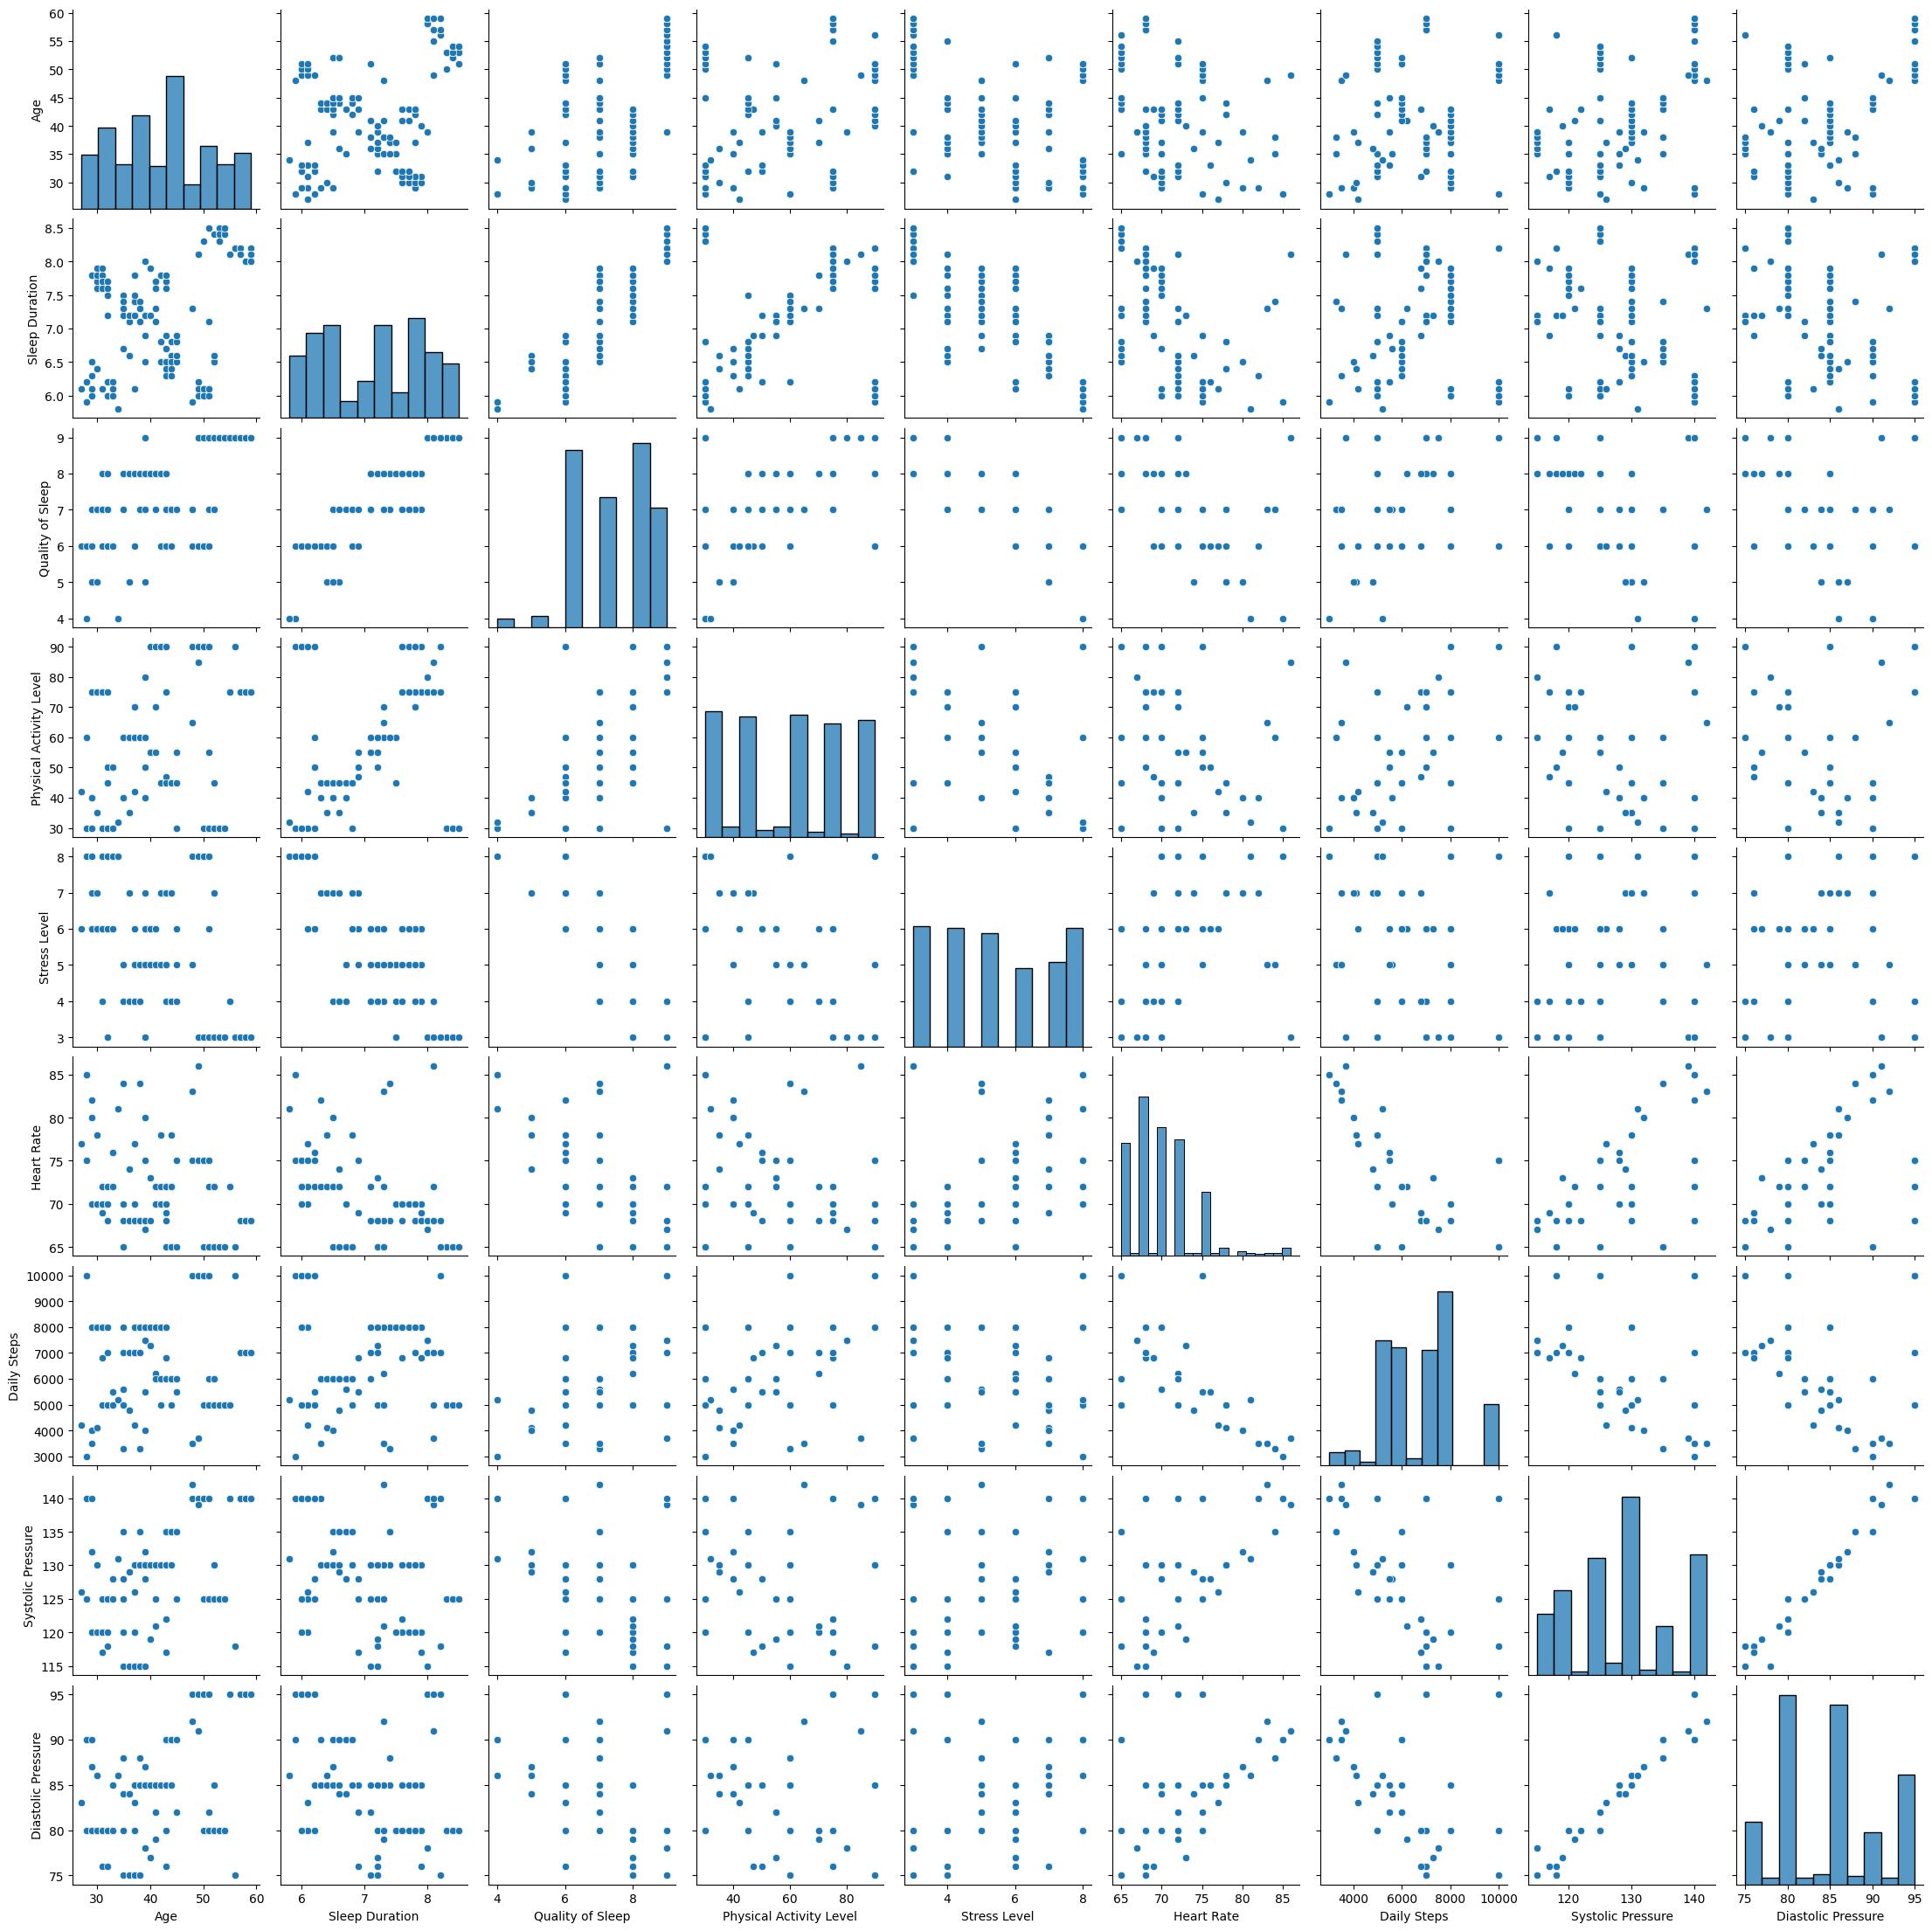

In [18]:
sns.pairplot(sleep_data[numeric_variables], height=2.5)

<Figure size 1200x960 with 0 Axes>

<Axes: >

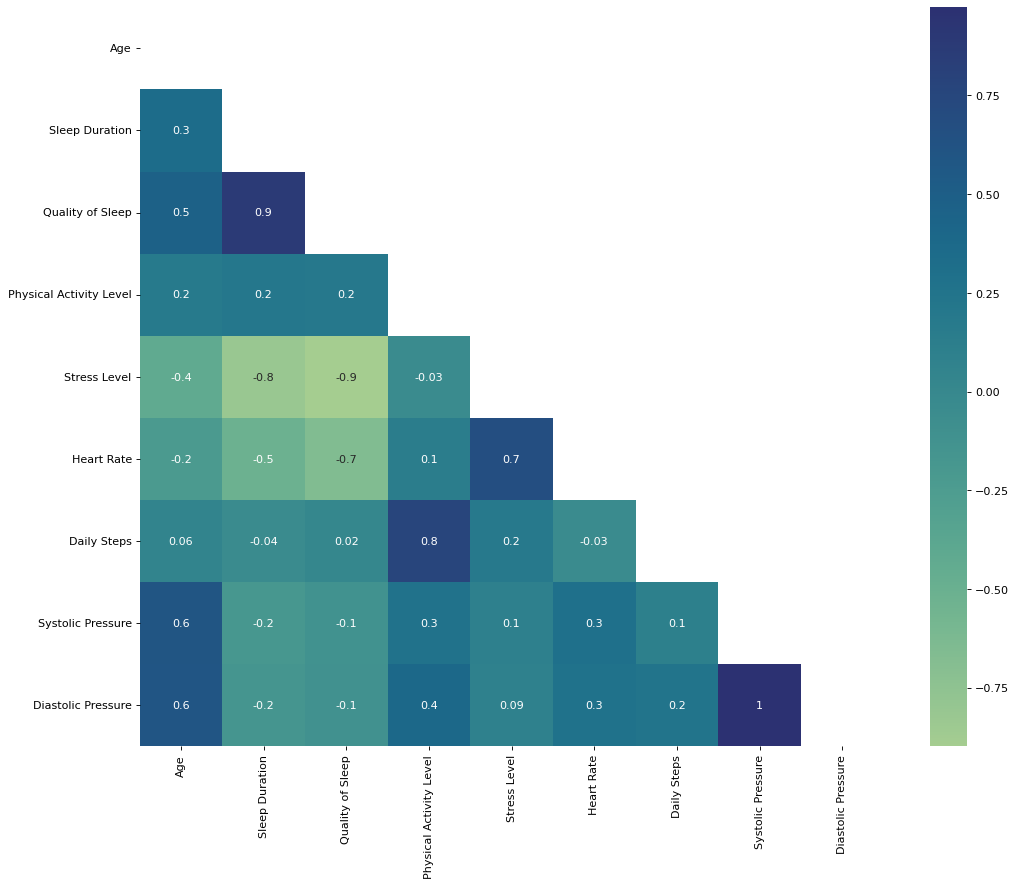

In [19]:
data_corr = sleep_data[numeric_variables].corr()
mask = np.triu(np.ones_like(data_corr, dtype=bool))
plt.figure(figsize=(15, 12), dpi=80)
sns.heatmap(data_corr, annot=True, fmt=".1g", cmap="crest", mask=mask)

The correlation matrix mostly confirms what we'd expect, plus one clear redundancy we need to deal with before clustering.

Quality of Sleep and Sleep Duration move together strongly (0.9), and both move opposite to Stress Level (-0.9 and -0.8). Heart Rate follows the same logic, positively tied to Stress (0.7) and negatively tied to Quality of Sleep (-0.7). Reading these four together, they don't look independent at all; they look like different windows onto the same underlying thing, where stress, sleep and cardiovascular activation all rise and fall together.

Physical Activity Level and Daily Steps are also strongly correlated (0.8), which makes sense since they're basically two ways of measuring the same underlying question of how active a person is.

The one that actually matters for feature selection is Systolic vs Diastolic Pressure: a perfect correlation (1.0). They move in lockstep here, so keeping both would just add a fully redundant column with zero extra information. We drop Diastolic Pressure.

Age stands apart from the rest. Its strongest tie is to blood pressure (0.6), which tracks the well known relationship between age and blood pressure, but it barely correlates with sleep quality, stress or activity.

# Unsupervised Learning

No labels here to guide us, just the data, and the goal is to see what structure comes out of it on its own. Two main tasks in this setting: clustering (grouping similar points) and dimensionality reduction (compressing dimensions while keeping the geometry roughly intact).

When unsupervised learning is used there's no ground truth to check against while training. So we either judge clusters with internal criteria (are points inside a cluster close together? are clusters well apart from each other?), or we use labels the algorithm never saw, purely post hoc, just to see afterwards how well it did.

 We scale everything with `MinMaxScaler`. The one hot columns are already 0/1, and standardizing would wreck that binary meaning. MinMaxScaler squashes every column into $[0, 1]$ via

$$
x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$$

so it leaves the binary columns basically alone while bringing the continuous features onto the same scale, which is what keeps every feature contributing comparably to the Euclidean distances used by k-means, Ward and DBSCAN downstream.

In [20]:
feature_list = sleep_data.drop(columns=["Sleep Disorder", "Person ID", "Diastolic Pressure"]).columns
new_categorical_variables = [i for i in feature_list if i not in numeric_variables]

X_raw = sleep_data[feature_list].to_numpy()
y = sleep_data["Sleep Disorder"].to_numpy()

## Outlier Detection

Before clustering we check whether the scaled feature matrix has anomalous points. This matters more for some algorithms than others: k-means and Ward hierarchical clustering are both distance based / variance minimizing, so one far away point can drag centroids toward it and inflate within cluster variance. We use two methods built on different assumptions and see where they agree.

**Grubbs' test** is univariate and iterative. For each feature separately it compares the most extreme standardized deviation

$$
G = \frac{\max_i \left| x_i - \bar{x} \right|}{s}
$$

against the critical value derived from the $t$ distribution,

$$
G_{\text{crit}} = \frac{n-1}{\sqrt{n}} \sqrt{\frac{t^2_{\alpha/(2n),\; n-2}}{\,n - 2 + t^2_{\alpha/(2n),\; n-2}}}
$$

and, whenever $G > G_{\text{crit}}$, drops the flagged point and repeats on what remains until nothing crosses the threshold anymore. Like a plain Z score cutoff it's a marginal, one feature at a time criterion with no notion of correlation between features, but the threshold itself adapts to sample size $n$ and significance level $\alpha$ instead of being fixed arbitrarily.

**Local Outlier Factor** works differently, comparing the local density of a point to the local density of its $k$ nearest neighbours $N_k(p)$:

$$
\mathrm{LOF}_k(p) = \frac{\dfrac{1}{|N_k(p)|} \sum_{o \in N_k(p)} \mathrm{lrd}_k(o)}{\mathrm{lrd}_k(p)}
$$

where $\mathrm{lrd}_k$ is the local reachability density. Values well above 1 mean the point sits in a much sparser neighbourhood than its own neighbours do, a density based notion of outlier.

The two end up complementing each other nicely: Grubbs catches marginal extremes on individual ratio scale features, LOF catches points sitting in low density pockets no matter which axis makes them stand out. Points flagged by both are the strongest candidates for removal.

Grubbs applied to 9 non-binary features (skipping 12 binary/one-hot columns)
Grubbs alpha      : 0.05
Outliers flagged  : 2 / 374 (0.5%)

Features triggering outlier flags:
Heart Rate    2
n_neighbors       : 20
Contamination     : 0.05
Outliers flagged  : 19 / 374 (5.1%)


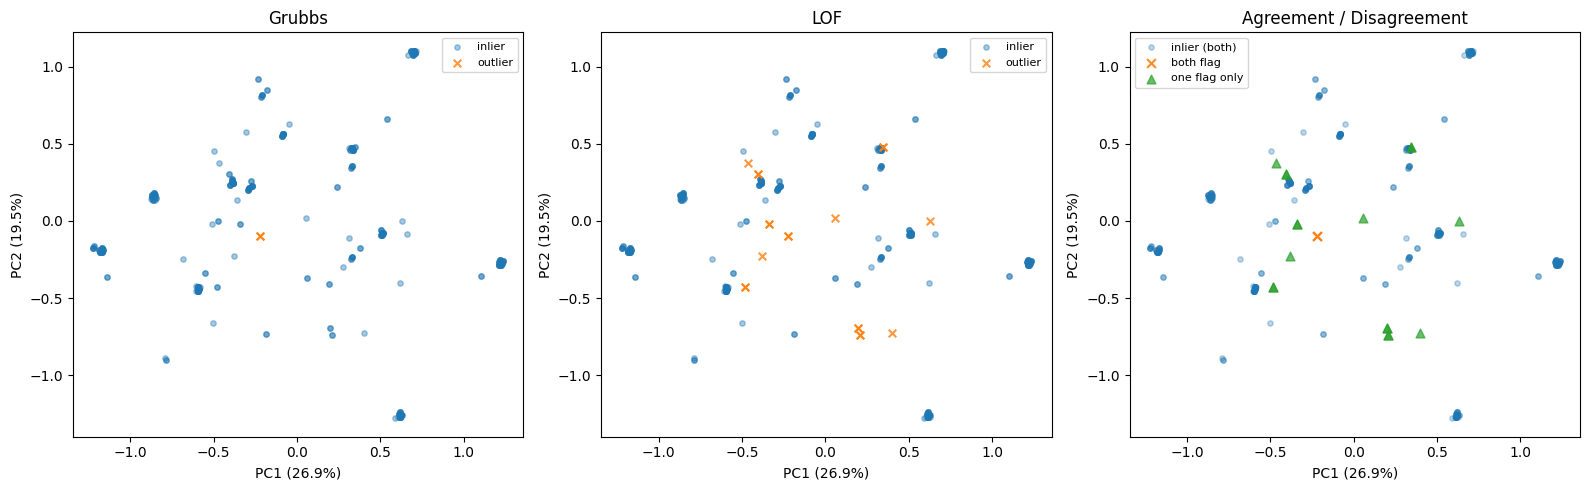


Flagged by both methods : 2
Flagged by Grubbs only : 0
Flagged by LOF only : 17
Points removed : 2
Points retained: 372


In [21]:
_scaler_tmp = MinMaxScaler()
X_tmp = _scaler_tmp.fit_transform(X_raw)

mask_grubbs = detect_outliers_grubbs(X_tmp, feature_names=list(feature_list), alpha=0.05, exclude_binary=True)
mask_lof    = detect_outliers_lof(X_tmp, n_neighbors=20, contamination=0.05)
plot_outliers_pca(X_tmp, mask_grubbs, mask_lof, label_a="Grubbs", label_b="LOF")

outlier_mask = mask_grubbs & mask_lof
print(f"Points removed : {outlier_mask.sum()}")
print(f"Points retained: {(~outlier_mask).sum()}")

X_raw_clean = X_raw[~outlier_mask]
y_clean     = y[~outlier_mask]

scaler = MinMaxScaler()
X = scaler.fit_transform(X_raw_clean)
y = y_clean

Grubbs flags just 2 points out of 374 (0.5%), both triggered by Heart Rate alone; nothing else crosses the critical value at $\alpha = 0.05$. LOF flags 19 points (5.1%, which is basically the `contamination` parameter by construction, so no surprise there), sitting in low density neighbourhoods.

The two methods agree on the same 2 points Grubbs found, but LOF also picks up 17 more that Grubbs completely misses. That makes sense: Grubbs only catches univariate extremes, so a point that looks perfectly normal on every feature taken alone but lands in a sparse corner of the joint feature space, an odd combination of stress, activity and sleep quality, say, is invisible to it, and exactly what LOF is built to catch.

We only drop the 2 points flagged by both. The 17 flagged by LOF alone stay in, mostly because there's no univariate backup for them: with `contamination` fixed at 5%, LOF has to flag roughly that fraction regardless of whether a real density gap exists underneath. That alone isn't strong enough evidence to throw out data, especially on a synthetic dataset where we don't expect actual measurement errors in the first place.

So we keep 372 of the original 374 observations (99.5%), and everything downstream, scaling, PCA, all ten clustering configurations, runs on this cleaned matrix.

<Figure size 1000x800 with 0 Axes>

Text(0.5, 0, 'PC1 (27.1% variance)')

Text(0, 0.5, 'PC2 (19.7% variance)')

Text(0.5, 1.0, 'PCA projection colored by Sleep Disorder')

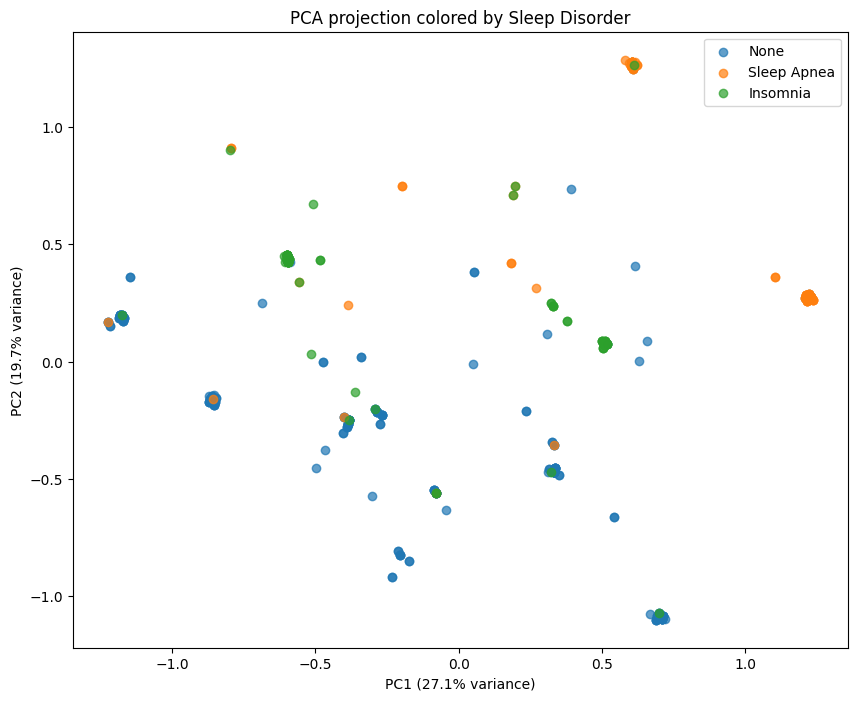

In [22]:
# Scatter plot colored by labels
plt.figure(figsize=(10, 8))

sleep_mapping = {0: "None", 1: "Sleep Apnea", 2: "Insomnia"}
pca_labels = PCA()
X_labels = pca_labels.fit_transform(X)
for label in np.unique(y):
    mask = y == label
    plt.scatter(
        X_labels[mask, 0],
        X_labels[mask, 1],
        label=sleep_mapping[label],
        alpha=0.7
    )

plt.xlabel(f'PC1 ({pca_labels.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca_labels.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA projection colored by Sleep Disorder')
plt.legend()
plt.show()

The first two principal components only capture 46.8% of total variance (27.1% + 19.7%).

Within that limitation, the three classes overlap a lot instead of forming clean regions. None (blue) dominates the plot and spreads across nearly the whole space, which makes sense since it's the majority class. Sleep Apnea (orange) and Insomnia (green) are scattered in among None though a few pockets do stand out , a small orange cluster top right, a green group near the bottom, another green pocket on the left edge. These hint that some subset of the pathological cases does have a distinct profile, but most points from all three classes are crammed into the same central region.

That's actually expected going into clustering :if the classes were cleanly separated here, clustering would just reproduce the labels and there wouldn't be much point to the unsupervised analysis. The overlap is what sets up the real question: does clustering find structure that the labels themselves don't capture?

## Clustering on the Full Feature Space

We start by running every clustering algorithm directly on the full scaled feature matrix X, before any dimensionality reduction. This gives us a baseline. Distance measures do get less discriminative as dimensionality grows (the usual curse-of-dimensionality argument), but with 374 observations and a moderate number of features this shouldn't bite us too hard here.

### Hierarchical Clustering

Agglomerative hierarchical clustering builds a nested sequence of partitions bottom-up: every point starts as its own cluster, and at each step the two closest clusters get merged. The whole merge sequence is stored in a linkage matrix and can be drawn as a dendrogram, where the height of a join is the dissimilarity at which that merge happened. Cutting the dendrogram at some height gives you a flat partition into k clusters.

Complexity-wise it needs O(n²) space for the dissimilarity matrix and O(n² log n) time in typical implementations. The nice thing compared to k-means is that we don't need to fix k up front: the dendrogram shows the whole hierarchy, and we can pick the cut afterwards by looking for the biggest gaps between merge heights.

The linkage criterion is really what matters here, since it decides how the distance between two clusters gets computed from the pairwise distances of their members, and it has a big effect on the shape and balance of what comes out. We compare two: Complete and Ward.

#### Complete Linkage

Complete linkage defines the distance between two clusters as the largest pairwise distance between their members:

$$
d(A, B) = \max \{\, d(a, b) : a \in A,\; b \in B \,\}
$$

It's a pessimistic rule, because two clusters only count as "close" if even their most distant members are still reasonably near each other. That tends to give compact, roughly spherical clusters, since an elongated chain of points can't merge until its extremes fall within threshold, though nothing about the rule enforces balanced cluster sizes the way Ward does. Downside: it's sensitive to outliers, since one far-away point can inflate the inter-cluster distance and hold off a merge that would otherwise have happened.

To pick k we look at the elbow in the WSS/BSS plot together with the silhouette curve. The elbow tells us where adding clusters stops meaningfully cutting variance, and the silhouette peak tells us which partition gives the best cohesion/separation balance.

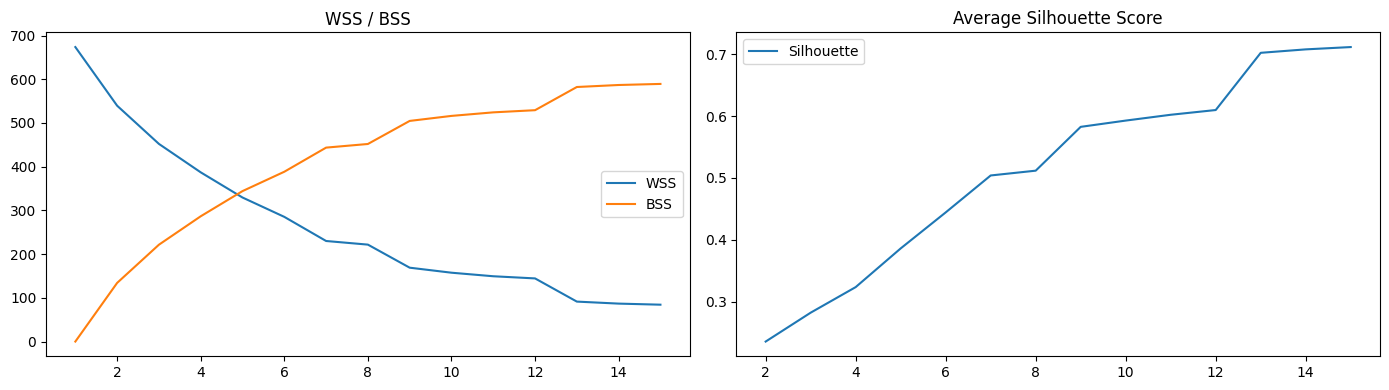

In [23]:
elbow_analysis(X, num_clus=15, method="hierarchical", linkage_method="complete", metric="euclidean")
Z_complete = linkage(X, method="complete", metric="euclidean")

In [24]:
for k in [6, 7, 8, 9, 10, 11, 12, 13, 14, 15]:
    labels = fcluster(Z_complete, t=k, criterion="maxclust")
    sizes = np.bincount(labels)[1:].tolist()   # Convert to Python list
    sizes_sorted = sorted(sizes, reverse=True)
    tiny_clusters = [s for s in sizes_sorted if s <= 3]

    print(
        f"k={k:2d} | "
        f"sizes={sizes_sorted} | "
        f"min={min(sizes_sorted)} | "
        f"tiny_clusters={tiny_clusters}"
    )

k= 6 | sizes=[143, 70, 45, 41, 37, 36] | min=36 | tiny_clusters=[]
k= 7 | sizes=[98, 70, 45, 45, 41, 37, 36] | min=36 | tiny_clusters=[]
k= 8 | sizes=[98, 70, 45, 41, 41, 37, 36, 4] | min=4 | tiny_clusters=[]
k= 9 | sizes=[70, 67, 45, 41, 41, 37, 36, 31, 4] | min=4 | tiny_clusters=[]
k=10 | sizes=[70, 67, 45, 41, 37, 37, 36, 31, 4, 4] | min=4 | tiny_clusters=[]
k=11 | sizes=[70, 67, 45, 37, 37, 37, 36, 31, 4, 4, 4] | min=4 | tiny_clusters=[]
k=12 | sizes=[68, 67, 45, 37, 37, 37, 36, 31, 4, 4, 4, 2] | min=2 | tiny_clusters=[2]
k=13 | sizes=[67, 45, 37, 37, 37, 36, 36, 32, 31, 4, 4, 4, 2] | min=2 | tiny_clusters=[2]
k=14 | sizes=[65, 45, 37, 37, 37, 36, 36, 32, 31, 4, 4, 4, 2, 2] | min=2 | tiny_clusters=[2, 2]
k=15 | sizes=[65, 45, 37, 37, 37, 36, 36, 32, 31, 4, 4, 2, 2, 2, 2] | min=2 | tiny_clusters=[2, 2, 2, 2]


To check whether the high silhouette values at k=14-15 reflect real structure or are just an artifact of chipping off tiny, trivially-separated groups, we looked at cluster sizes across k=6 to 15.

Up to k=11, sizes stay in a reasonable range (4 to ~98 points), including a small but stable 4-point cluster that first shows up at k=8 and doesn't disappear afterwards ,probably a genuine small subgroup. From k=12 on, singleton-like 2-point clusters start showing up, and by k=15 there are four of them. Those tiny clusters are trivially well separated, which is exactly what's driving the silhouette jump at higher k ,it's not a better partition overall, just a few outlying points getting carved off into their own group.

Given that, k=10 looks like the sensible choice: it sits right before the partition starts degenerating into near-singletons, and all 10 clusters still have at least 4 points each.

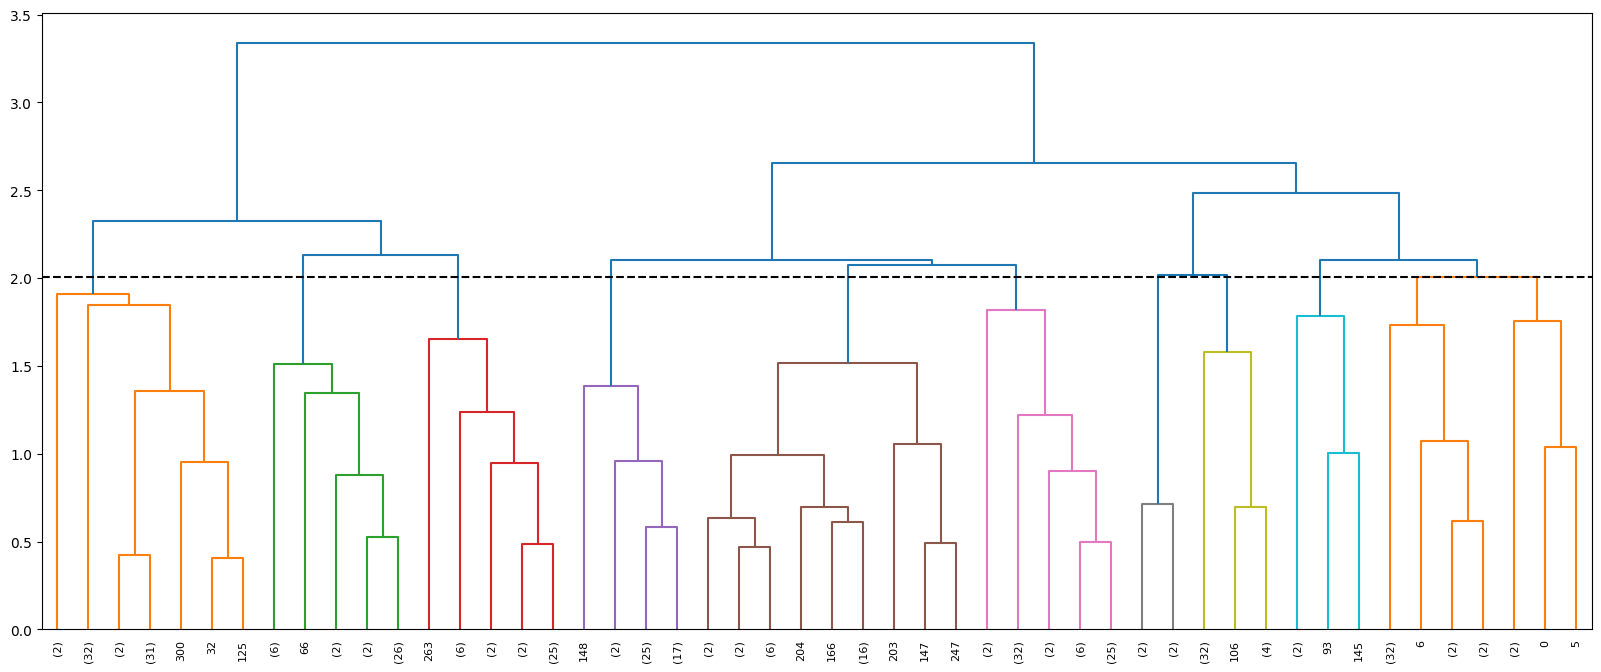

In [25]:
N_CLUSTERS_COMPLETE = 10
plot_dendrogram(Z_complete, n_clusters=N_CLUSTERS_COMPLETE, truncate_mode="lastp", p=50)

The dendrogram, truncated to the last 50 merges for readability, shows the cut at k=10 (dashed line, height ≈ 2.0). At that height the branches split into fairly different sizes :some merge quite late, around height 3.0-3.5, meaning they stay distinct almost to the end, while others on the right merge earlier and sit closer together before the cut. Lines up with what we saw in the cluster sizes: a mix of medium groups (30-70 points) plus the smaller ~4-point ones, all merging well below the height where things start fragmenting into near-singletons.

In [26]:
y_pred_complete = fcluster(Z_complete, t=N_CLUSTERS_COMPLETE, criterion="maxclust") - 1

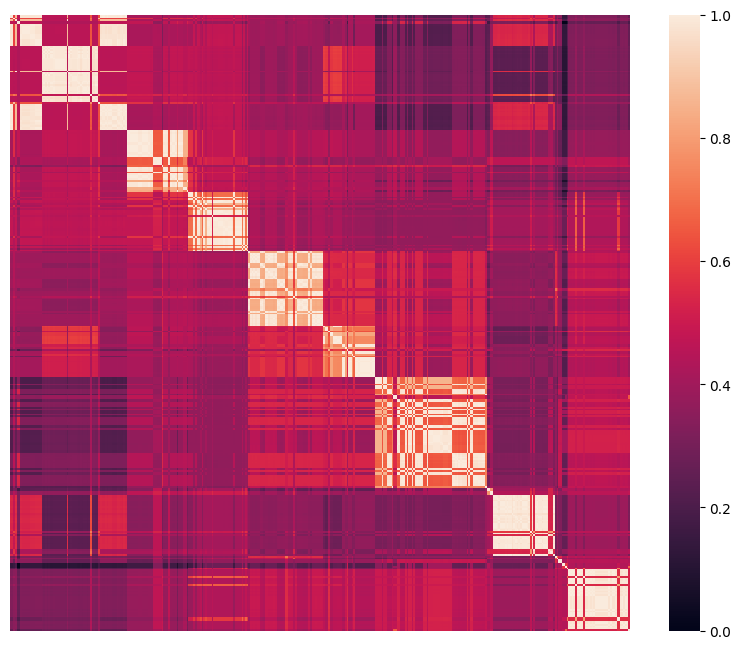

In [27]:
plot_sorted_similarity(X, y_pred_complete)

The sorted similarity matrix shows a clear block structure along the diagonal, which is what we want to see: points in the same cluster are consistently more similar to each other (lighter blocks) than to points outside it (darker off-diagonal). Most blocks are reasonably dense and well bounded, though a few bleed a bit into neighbouring blocks, visible as lighter patches just off the diagonal, meaning those particular clusters aren't perfectly separated and sit fairly close to their neighbours. Overall this backs up k=10 as a real partition, since the diagonal structure holds across the whole matrix and isn't just being carried by one or two big clusters.

In [28]:
plot_pca_matrix(X, y_pred_complete)

The PCA scatter matrix shows a fair amount of cluster overlap, with the first three components together only explaining about 60% of total variance. A 10-cluster partition on the full feature space has no particular reason to line up with the directions of maximum variance PCA is picking out, so a linear 2D/3D projection can easily blur boundaries that are actually well defined in the original space, which is what the sorted similarity matrix already hinted at. Next up is t-SNE, which captures non-linear local structure and usually separates clusters more clearly than a linear projection like PCA.

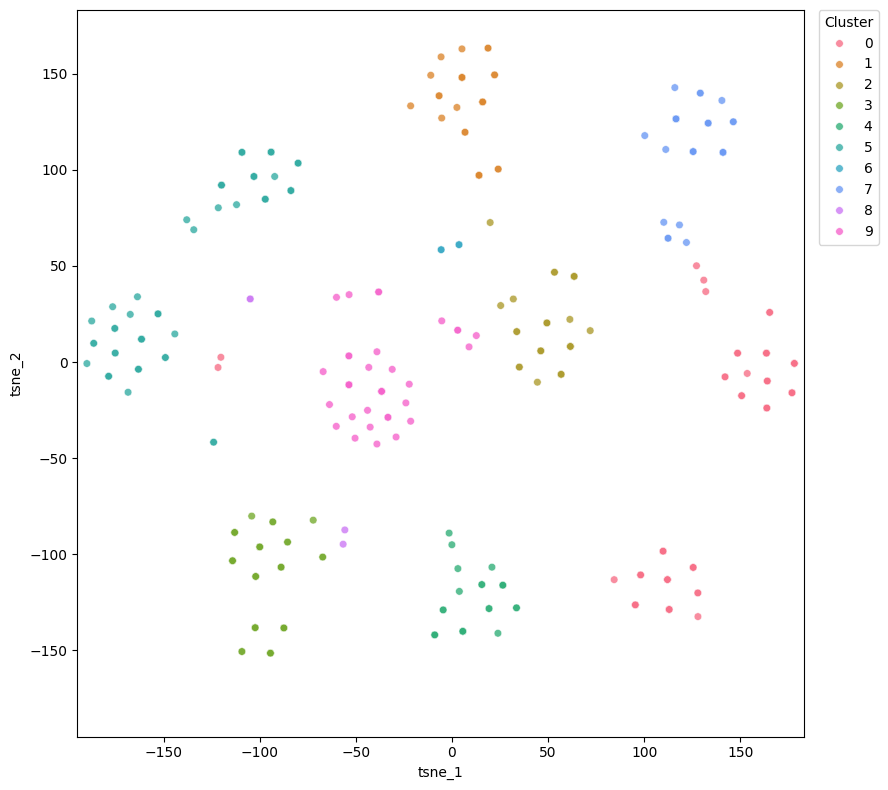

In [29]:
plot_tsne(X, y_pred_complete)

Unlike the linear PCA projection, t-SNE shows the 10 clusters as clearly separated groups, each a distinct, compact blob with barely any overlap with its neighbours. So the partition Complete linkage found does correspond to real structure ,it's just structure the first couple of principal components don't capture well, since t-SNE is explicitly optimizing to preserve local neighbourhoods.

A couple of clusters (cluster 8, purple, for instance) show up as just one or two isolated points matches the small 4-point clusters we already flagged when checking sizes across k.

In [30]:
print_external_metrics(y_pred_complete, y, label="Hierarchical Complete (All Features)")

--- Hierarchical Complete (All Features) ---
  Adjusted Rand Index (ARI):     0.1519
  Jaccard (pairs):               0.1903
  Fowlkes-Mallows (FM):          0.3798
  Hubert's Gamma Statistic:      0.2052
  Purity:                        0.7876
  Homogeneity:                   0.4520
  Completeness:                  0.2060
  V-measure:                     0.2831


Purity is decently high (0.79), so most clusters are dominated by a single Sleep Disorder class, but completeness is low (0.21) ,each class ends up spread across several clusters instead of collapsing into one. Homogeneity (0.45) sits in between, and V-measure (0.28), the harmonic mean of the two, gets pulled down mainly by that weak completeness.

ARI (0.15), Jaccard (0.19) and Fowlkes-Mallows (0.38) are all on the low side, meaning pair-level agreement with ground truth is weak. Tracks with the cluster size analysis from before: Complete linkage gives a somewhat uneven partition, with a few small clusters next to bigger ones, and that unevenness probably contributes to clusters mixing diagnostic labels.

#### Ward Linkage

Ward's method doesn't measure inter-cluster distance directly. Instead, at every step it merges whichever pair of clusters causes the smallest increase in total within-cluster sum of squares:

$$
\Delta WSS(A,B)=\frac{n_A \cdot n_B}{n_A+n_B}\cdot\|\mu_A-\mu_B\|^2
$$

where $n_A$, $n_B$ are cluster sizes and $μ_A$, $μ_B$ their centroids. Equivalent to minimizing the size-weighted squared distance between centroids.

Ward tends to give balanced, compact clusters and is usually considered the strongest agglomerative option for Euclidean data. Same limitation as k-means though: it assumes convex, isotropic cluster shapes, which might not be what the data actually looks like.

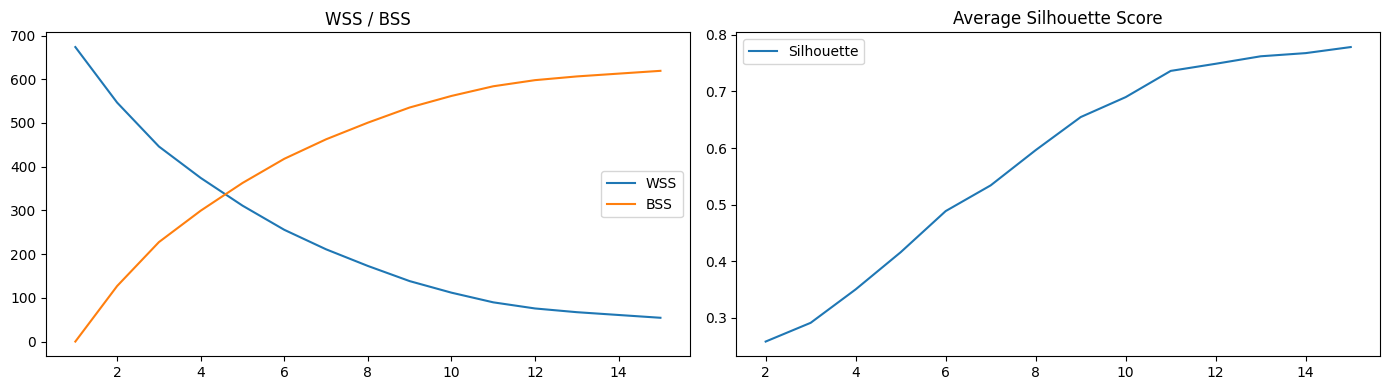

In [31]:
elbow_analysis(X, num_clus=15, method="hierarchical", linkage_method="ward", metric="euclidean")
Z_ward = linkage(X, method="ward", metric="euclidean")

In [32]:
for k in [6, 7, 8, 9, 10, 11, 12, 13, 14, 15]:
    labels = fcluster(Z_ward, t=k, criterion="maxclust")
    sizes = sorted([int(s) for s in np.bincount(labels)[1:]], reverse=True)
    n_tiny = sum(1 for s in sizes if s <= 3)
    print(f"k={k:2d} | sizes={sizes} | min={min(sizes)} | tiny clusters (≤3 pts)={n_tiny}")

k= 6 | sizes=[101, 67, 65, 65, 42, 32] | min=32 | tiny clusters (≤3 pts)=0
k= 7 | sizes=[70, 67, 65, 65, 42, 32, 31] | min=31 | tiny clusters (≤3 pts)=0
k= 8 | sizes=[70, 67, 65, 42, 33, 32, 32, 31] | min=31 | tiny clusters (≤3 pts)=0
k= 9 | sizes=[70, 67, 42, 33, 33, 32, 32, 32, 31] | min=31 | tiny clusters (≤3 pts)=0
k=10 | sizes=[67, 42, 36, 34, 33, 33, 32, 32, 32, 31] | min=31 | tiny clusters (≤3 pts)=0
k=11 | sizes=[42, 36, 34, 34, 33, 33, 33, 32, 32, 32, 31] | min=31 | tiny clusters (≤3 pts)=0
k=12 | sizes=[42, 36, 34, 33, 33, 33, 32, 32, 32, 31, 18, 16] | min=16 | tiny clusters (≤3 pts)=0
k=13 | sizes=[42, 36, 34, 33, 33, 33, 32, 32, 32, 31, 16, 10, 8] | min=8 | tiny clusters (≤3 pts)=0
k=14 | sizes=[42, 36, 34, 33, 33, 33, 32, 32, 32, 31, 10, 9, 8, 7] | min=7 | tiny clusters (≤3 pts)=0
k=15 | sizes=[42, 36, 34, 33, 33, 33, 32, 32, 32, 31, 9, 8, 7, 6, 4] | min=4 | tiny clusters (≤3 pts)=0


Cluster sizes stay remarkably balanced from k=6 to k=11, all between 31 and 42 points. At k=12 that balance breaks down hard: the smallest cluster drops from 31 to 16, and keeps shrinking further at higher k (down to 4 at k=15). Points to k=11 as the natural cutoff: the last partition where Ward is still giving balanced, well-formed clusters before it starts breaking an existing group into smaller, messier pieces.

So N_CLUSTERS_WARD = 11 seems well supported.

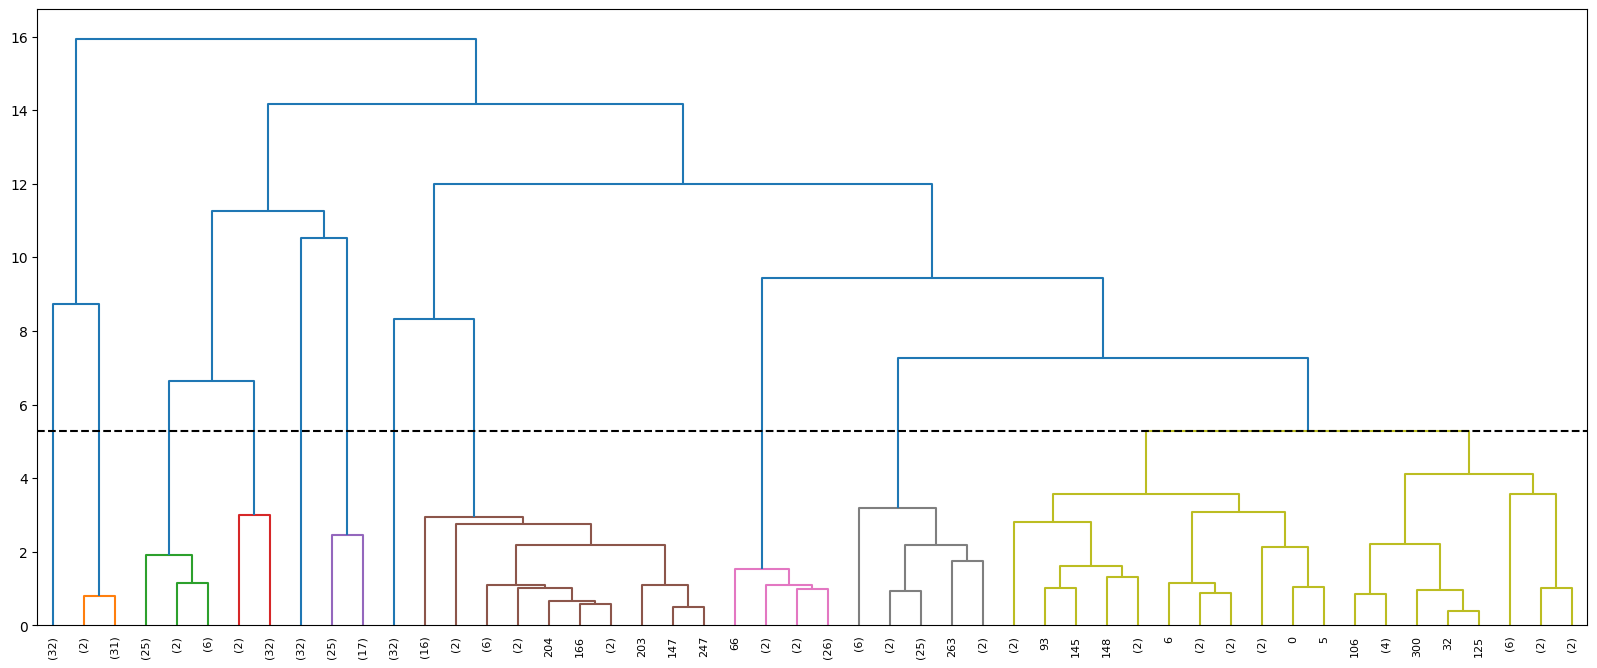

In [33]:
N_CLUSTERS_WARD = 11
plot_dendrogram(Z_ward, n_clusters=N_CLUSTERS_WARD, truncate_mode="lastp", p=50)

The dendrogram, truncated to the last 50 merges, shows the cut at k=11 (dashed line, height ≈ 5.3). Merge heights above the cut span a wide range, roughly 6 to 16. Ward isn't merging small fragments right at the cut, it's keeping genuinely separate groups apart well past this height. The right-hand branch (yellow) has several tighter sub-branches merging just below the cut, suggesting part of the data could split further without immediately degenerating into tiny clusters

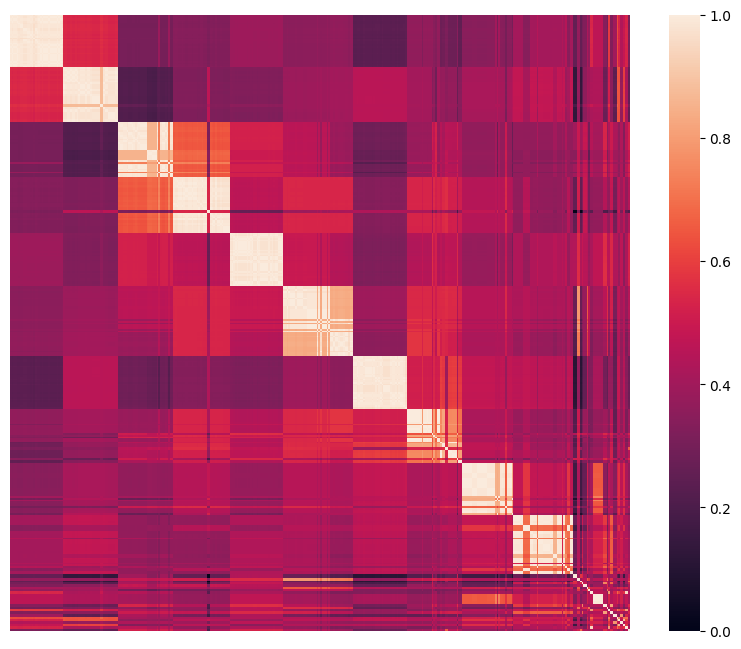

In [34]:
y_pred_ward = fcluster(Z_ward, t=N_CLUSTERS_WARD, criterion="maxclust") - 1
plot_sorted_similarity(X, y_pred_ward)

The sorted similarity matrix for Ward shows clear diagonal block structure, with most blocks dense and well bounded. Compared to Complete linkage the blocks look a bit more uniform in size, matching the cluster sizes we found earlier. Ward keeps things around 31-42 points each. There's still a bit of bleeding between a couple of adjacent blocks, so it's not perfectly separated everywhere, but overall the diagonal structure supports k=11 as a coherent partition.

In [35]:
plot_pca_matrix(X, y_pred_ward)

Same as Complete linkage: the PCA scatter matrix shows a lot of overlap between clusters, with the first three components capturing only around 60% of total variance. That lack of visible separation doesn't contradict the balanced, well-bounded structure from the similarity matrix ,it just confirms the cluster boundaries don't line up with the directions of maximum linear variance. Onto t-SNE for a non-linear view of the same partition.

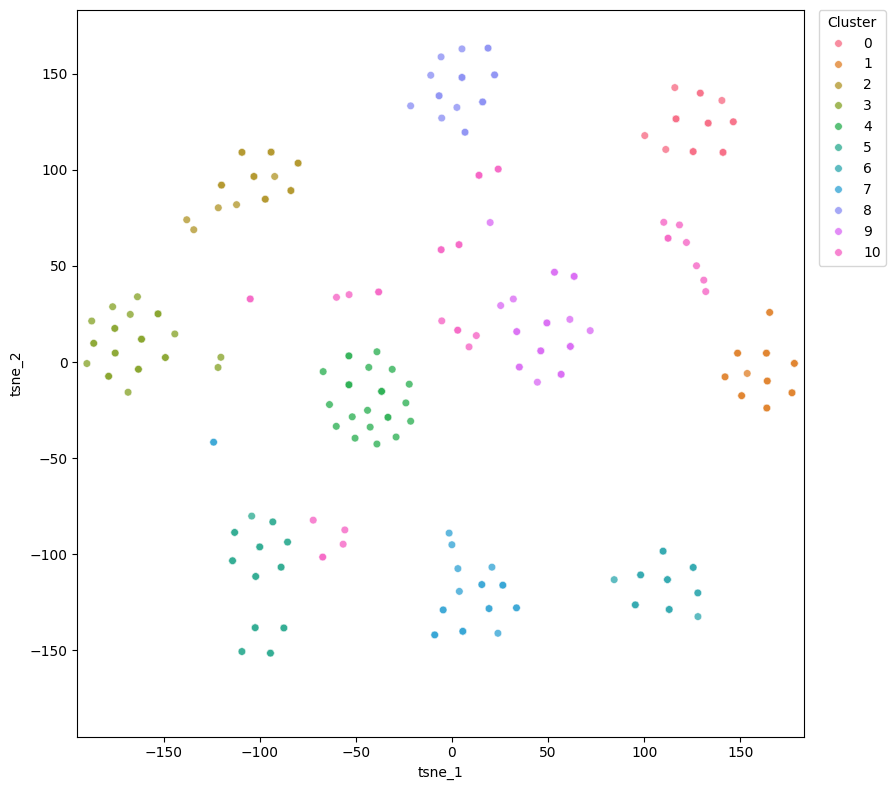

In [36]:
plot_tsne(X, y_pred_ward)

The t-SNE projection shows all 11 clusters as distinct, well-separated blobs, no isolated single points this time. This is coherent with the cluster size analysis, where every cluster has at least 31 points and there's no fragmentation into tiny groups. Compared to the Complete linkage t-SNE, the blobs here look a touch more uniform in size and spacing, which fits Ward's tendency toward balance. Consistent with the size and similarity checks above, though not independent proof: t-SNE preserves the same local neighborhoods the clustering already relied on.

In [37]:
print_external_metrics(y_pred_ward, y, label="Hierarchical Ward (All Features)")

--- Hierarchical Ward (All Features) ---
  Adjusted Rand Index (ARI):     0.1403
  Jaccard (pairs):               0.1542
  Fowlkes-Mallows (FM):          0.3541
  Hubert's Gamma Statistic:      0.2199
  Purity:                        0.8548
  Homogeneity:                   0.5785
  Completeness:                  0.2325
  V-measure:                     0.3317


Compared to Complete linkage, Ward gets higher purity (0.85 vs 0.79), homogeneity (0.58 vs 0.45), completeness (0.23 vs 0.21) and V-measure (0.33 vs 0.28). The pair-based metrics tell a slightly different story though: ARI (0.14 vs 0.15), Jaccard (0.15 vs 0.19) and FM (0.35 vs 0.38) are marginally lower for Ward, possibly because Complete's smaller, more numerous clusters leave less room for cross-label pairs to end up together, which can inflate these scores a bit independently of actual label alignment.

Neither method reproduces the diagnostic labels particularly well overall but Ward looks like the more internally coherent of the two.

### K-Means

K-means splits n points into k clusters by alternating two steps until convergence: assign each point to its nearest centroid (a Voronoi partition), then recompute each centroid as the mean of its assigned points. It's minimizing the within-cluster sum of squares:

$$
\mathrm{WSS}=\sum_{k}\sum_{x\in C_k}\left\|x-\mu_k\right\|^2
$$

WSS decreases monotonically each step so it's guaranteed to converge, but where it lands is a local minimum depending on where the centroids started. We run it with `n_init=50` restarts and keep the best (lowest WSS) to reduce that sensitivity.

We compare two initialization strategies: random placement drawn from the data, and k-means++, which places each new centroid with probability proportional to its squared distance from the nearest already-chosen centroid. k-means++ has an O(log k) approximation guarantee on final WSS and usually gets to a better solution with fewer restarts than random init.

K-means assumes convex, isotropic (spherical) clusters, a limitation no preprocessing step can remove, and is sensitive to feature scale, which MinMaxScaler does address here.

#### Random Initialization

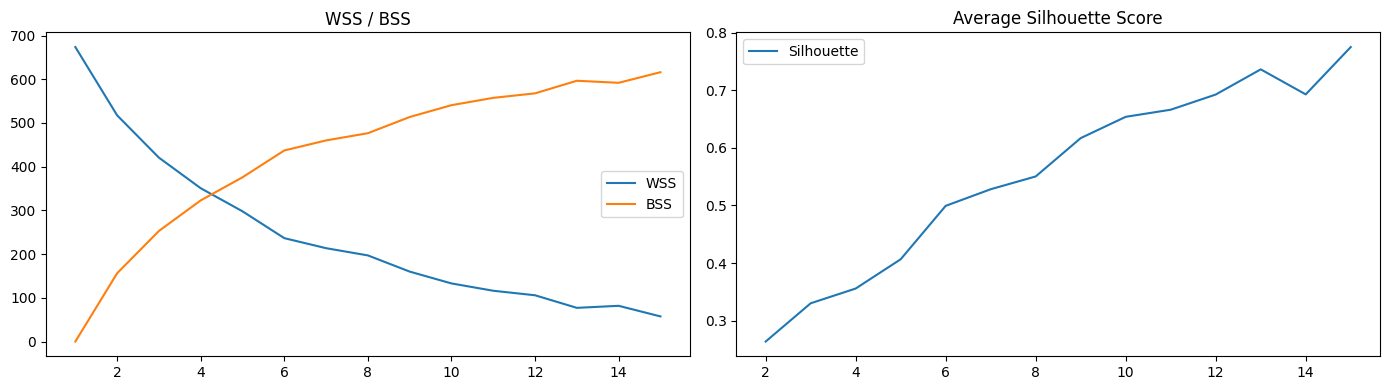

In [38]:
elbow_analysis(X, 15, method="kmeans", init="random")

In [39]:
for k in [6, 7, 8, 9, 10, 11, 12, 13, 14, 15]:
    km = KMeans(n_clusters=k, init="random", random_state=0, n_init=50)
    labels = km.fit_predict(X)
    sizes = sorted([int(s) for s in np.bincount(labels)], reverse=True)
    n_tiny = sum(1 for s in sizes if s <= 3)
    print(f"k={k:2d} | sizes={sizes} | min={min(sizes)} | tiny clusters (≤3 pts)={n_tiny}")

k= 6 | sizes=[79, 73, 67, 62, 49, 42] | min=42 | tiny clusters (≤3 pts)=0
k= 7 | sizes=[73, 67, 62, 49, 43, 39, 39] | min=39 | tiny clusters (≤3 pts)=0
k= 8 | sizes=[73, 67, 46, 46, 39, 36, 33, 32] | min=32 | tiny clusters (≤3 pts)=0
k= 9 | sizes=[77, 46, 38, 37, 37, 36, 36, 33, 32] | min=32 | tiny clusters (≤3 pts)=0
k=10 | sizes=[61, 47, 37, 37, 37, 36, 34, 33, 32, 18] | min=18 | tiny clusters (≤3 pts)=0
k=11 | sizes=[48, 38, 37, 36, 35, 35, 34, 32, 31, 27, 19] | min=19 | tiny clusters (≤3 pts)=0
k=12 | sizes=[47, 40, 37, 35, 34, 33, 32, 32, 32, 30, 14, 6] | min=6 | tiny clusters (≤3 pts)=0
k=13 | sizes=[45, 38, 37, 33, 33, 32, 32, 32, 32, 30, 14, 8, 6] | min=6 | tiny clusters (≤3 pts)=0
k=14 | sizes=[45, 38, 37, 35, 34, 33, 32, 32, 32, 30, 12, 6, 4, 2] | min=2 | tiny clusters (≤3 pts)=1
k=15 | sizes=[44, 39, 36, 35, 33, 33, 32, 32, 32, 31, 6, 6, 5, 5, 3] | min=3 | tiny clusters (≤3 pts)=1


In [40]:
N_CLUSTERS_KRND = 11

kmeans = KMeans(n_clusters= N_CLUSTERS_KRND, init="random", random_state=0, n_init=50)
y_pred_kmeans = kmeans.fit_predict(X)

Cluster sizes stay balanced from k=6 to k=9, all between 32 and 77 points. At k=10 the minimum drops sharply to 18, partially recovers at k=11 (min=19), then collapses to 6 at k=12, the same k the silhouette curve pointed to. The choppiness mirrors the non-smooth silhouette curve from before, and fits with random init occasionally landing in different local minima across k even with 50 restarts.

k=12 isn't well supported given that a 6-point cluster is well into fragmentation territory. k=9 is the last fully balanced partition (min=32), while k=11 is a reasonable middle ground ,a bit more granular, still nothing below 19 points.

We go with N_CLUSTERS_KRND = 11.

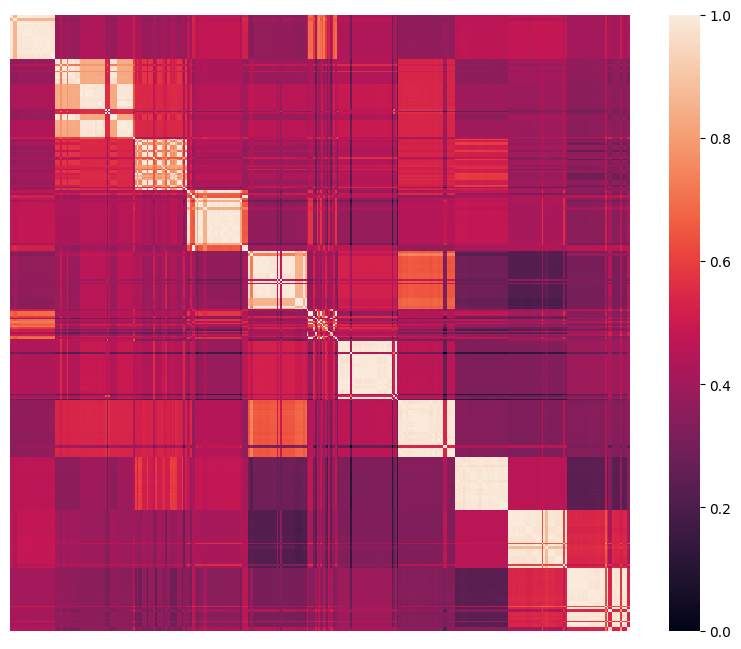

In [41]:
plot_sorted_similarity(X, y_pred_kmeans)

The sorted similarity matrix shows a noticeably more uneven block structure than the hierarchical solutions. Some blocks are dense and clearly bounded (bottom right), others bleed heavily into their neighbours (top left), with off-diagonal patches nearly as light as the diagonal blocks themselves. Even with 50 restarts, k-means can land on solutions where some clusters are well separated and others sit in ambiguous, overlapping regions. Noticeably weaker block quality than Ward's, which fits with Ward being the stronger agglomerative criterion for Euclidean data.

In [42]:
plot_pca_matrix(X, y_pred_kmeans)

Same story as the other PCA scatter matrices: heavy cluster overlap across all three projection planes, first three components covering around 60% of variance. Nothing new to read here, t-SNE below should be more informative.

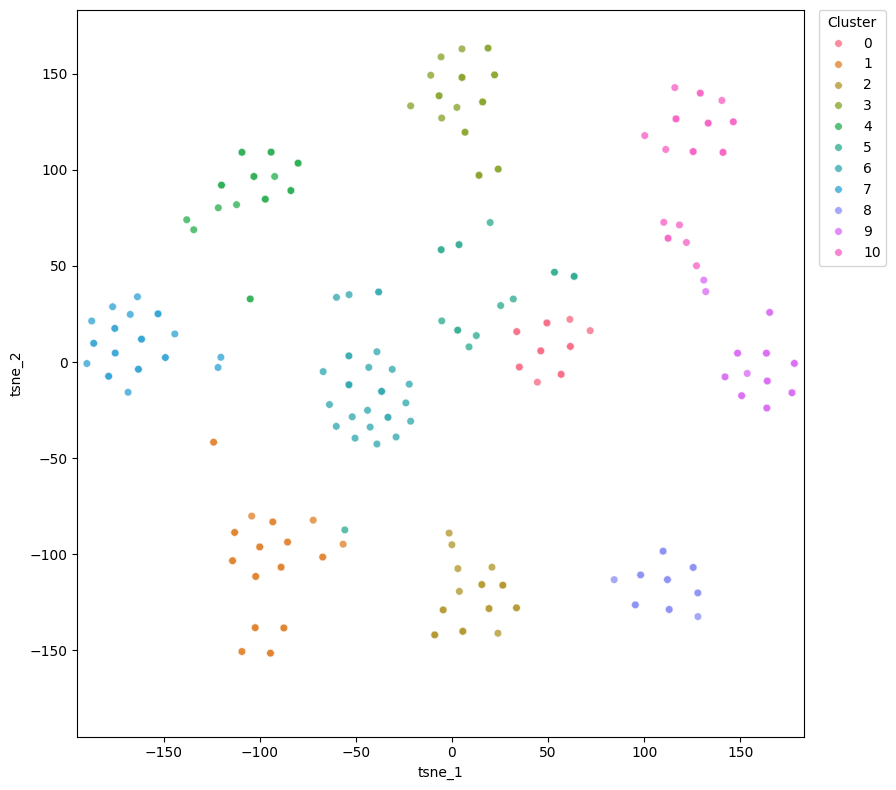

In [43]:
plot_tsne(X, y_pred_kmeans)

The t-SNE shows 11 broadly separated clusters, but with noticeably more overlap and mixing than the Ward or DBSCAN projections: several blobs sit close together with points from different clusters bleeding into each other at the edges. Coherent with what the similarity matrix already suggested: random init gives a partition where some clusters are well defined and others sit in ambiguous regions, and that ambiguity shows up here as blurry boundaries. No isolated single points this time, consistent with every cluster having at least 19 points at k=11.

In [44]:
print_external_metrics(y_pred_kmeans, y, label="K-means Random Initialization (All Features)")

--- K-means Random Initialization (All Features) ---
  Adjusted Rand Index (ARI):     0.1435
  Jaccard (pairs):               0.1584
  Fowlkes-Mallows (FM):          0.3586
  Hubert's Gamma Statistic:      0.2217
  Purity:                        0.8629
  Homogeneity:                   0.5614
  Completeness:                  0.2273
  V-measure:                     0.3236


The external metrics for random-init k-means sit very close to Ward's: ARI (0.14), Jaccard (0.16), FM (0.36), purity (0.85), homogeneity (0.56), completeness (0.22) and V-measure (0.32) are all within a few points of each other. A bit surprising given the messier block structure in the similarity matrix , this suggests that despite the rougher internal geometry, the partition aligns with the diagnostic labels about as well as Ward's more balanced one does.

Completeness stays the weakest metric here too, same as with every method so far, splitting diagnoses across multiple clusters seems to be a general pattern, not something specific to k-means or to random init.

#### K-Means ++ Initialization

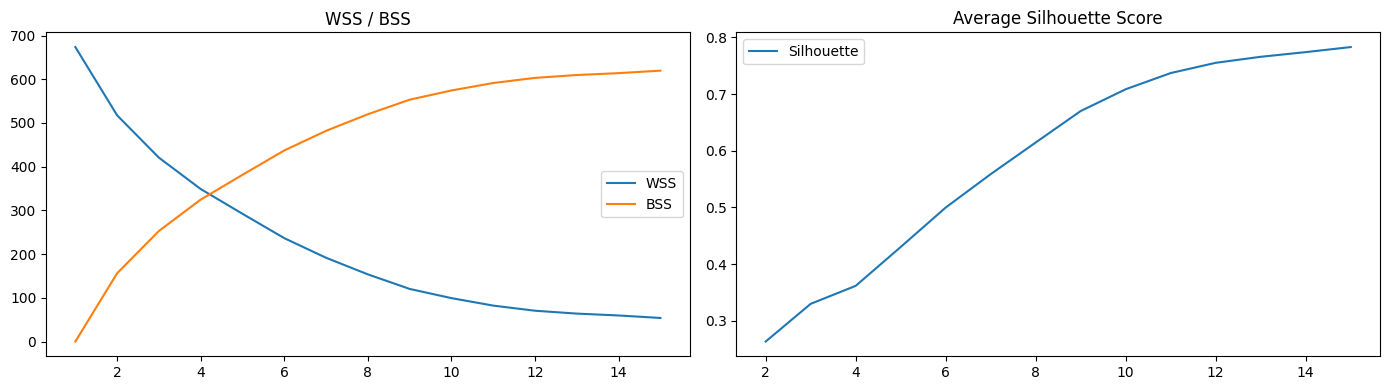

In [45]:
elbow_analysis(X, 15, method="kmeans", init="k-means++")

In [46]:
N_CLUSTERS_KP= 10
kmeans_plus = KMeans(n_clusters=N_CLUSTERS_KP, init="k-means++", random_state=0, n_init=50)
y_pred_kmeans_plus = kmeans_plus.fit_predict(X)

In [47]:
for k in [6, 7, 8, 9, 10, 11, 12, 13, 14, 15]:
    km = KMeans(n_clusters=k, init="k-means++", random_state=0, n_init=50)
    labels = km.fit_predict(X)
    sizes = sorted([int(s) for s in np.bincount(labels)], reverse=True)
    n_tiny = sum(1 for s in sizes if s <= 3)
    print(f"k={k:2d} | sizes={sizes} | min={min(sizes)} | tiny clusters (≤3 pts)={n_tiny}")

k= 6 | sizes=[79, 73, 67, 62, 49, 42] | min=42 | tiny clusters (≤3 pts)=0
k= 7 | sizes=[73, 67, 62, 49, 43, 39, 39] | min=39 | tiny clusters (≤3 pts)=0
k= 8 | sizes=[67, 62, 49, 43, 39, 38, 37, 37] | min=37 | tiny clusters (≤3 pts)=0
k= 9 | sizes=[67, 47, 43, 38, 38, 37, 37, 33, 32] | min=32 | tiny clusters (≤3 pts)=0
k=10 | sizes=[47, 43, 38, 38, 37, 37, 36, 33, 32, 31] | min=31 | tiny clusters (≤3 pts)=0
k=11 | sizes=[48, 39, 37, 36, 35, 34, 32, 32, 32, 31, 16] | min=16 | tiny clusters (≤3 pts)=0
k=12 | sizes=[45, 37, 37, 36, 36, 33, 32, 32, 32, 30, 11, 11] | min=11 | tiny clusters (≤3 pts)=0
k=13 | sizes=[45, 37, 36, 35, 33, 32, 32, 32, 31, 29, 12, 12, 6] | min=6 | tiny clusters (≤3 pts)=0
k=14 | sizes=[45, 35, 35, 34, 33, 32, 32, 32, 32, 31, 14, 7, 6, 4] | min=4 | tiny clusters (≤3 pts)=0
k=15 | sizes=[45, 36, 35, 33, 32, 32, 32, 31, 30, 29, 13, 6, 6, 6, 6] | min=6 | tiny clusters (≤3 pts)=0


K-means++ gives noticeably cleaner cluster sizes than random init across every k. Sizes stay balanced from k=6 to k=10, all between 31 and 79 points, no notable drops. At k=11 the minimum falls to 16, and from k=13 on clusters of 6 points or fewer start showing up.

k=10 is the natural cutoff then ,last fully balanced partition before things start fragmenting, and it also matches the WSS elbow. We set N_CLUSTERS_KPP = 10.

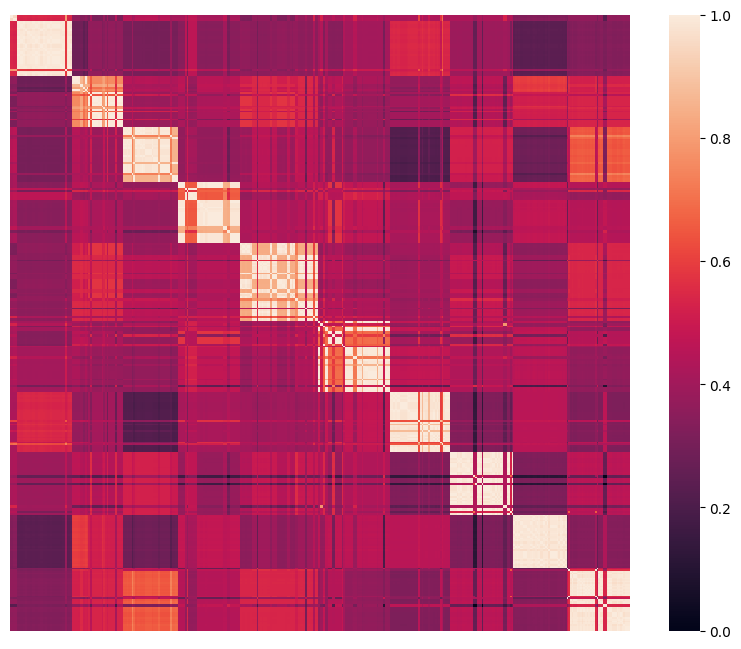

In [48]:
plot_sorted_similarity(X, y_pred_kmeans_plus)

The similarity matrix for k-means++ looks similar to random init : diagonal blocks visible, but with quite a bit of off-diagonal bleeding, and some blocks noticeably denser than others. The overall pattern isn't really cleaner than random init's, which makes sense: k-means++ improves initialization and tends to find lower-WSS solutions, but it doesn't change the underlying constraint that k-means gives convex, isotropic clusters, so the partition geometry stays similar regardless of how the centroids got seeded.

In [49]:
plot_pca_matrix(X, y_pred_kmeans_plus)

Same as before,heavy overlap across all three projection planes, nothing new to read beyond what the similarity matrix already showed. On to t-SNE.

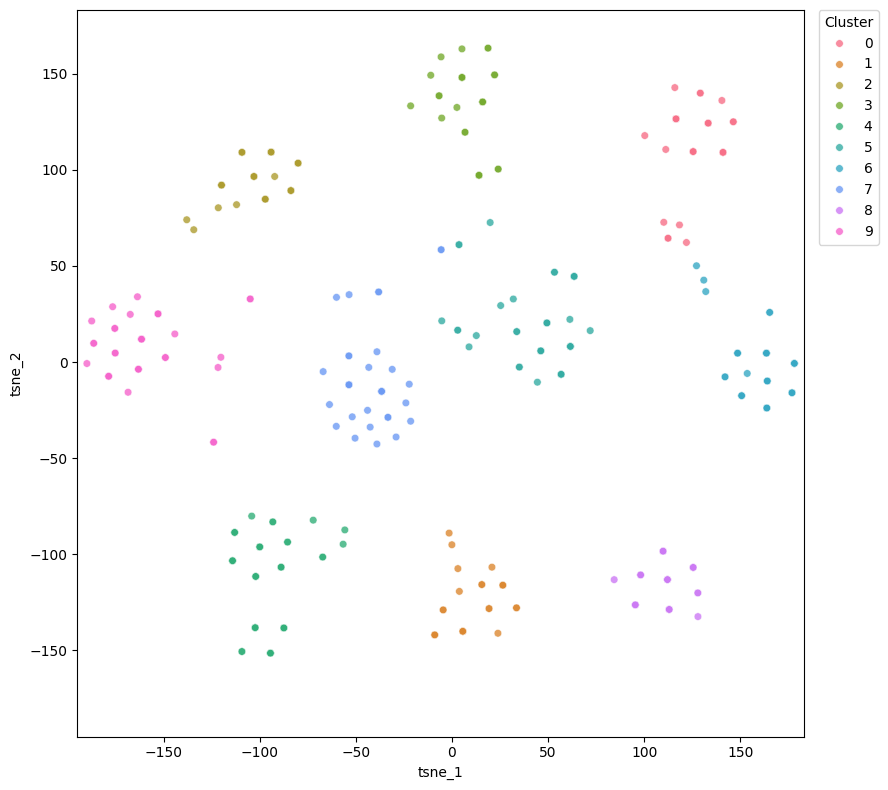

In [50]:
plot_tsne(X, y_pred_kmeans_plus)

The t-SNE for k-means++ shows cleaner separation than random init: most blobs are distinct with less inter-cluster mixing at the edges, matching the better-balanced cluster sizes from before. The centre is still the most crowded area, with a few clusters sitting close together, but overall the partition looks more coherent here than with random init, consistent with k-means++ landing on a more stable solution.

### DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) takes a different angle entirely: instead of partitioning space into Voronoi regions or merging points purely by distance, it defines clusters as dense regions separated by lower-density areas.

Two parameters drive it: $\varepsilon$ (`eps`), the neighbourhood radius, and MinPts (`min_samples`), the minimum number of neighbours within $\varepsilon$ for a point to count as core. Writing the $\varepsilon$-neighbourhood of a point $p$ as

$$
N_\varepsilon(p) = \left\{\, q \in D \;:\; d(p, q) \le \varepsilon \,\right\}
$$

a point $p$ is

- **core** if $\left| N_\varepsilon(p) \right| \ge \text{MinPts}$,
- **border** if it isn't core but lies in $N_\varepsilon(q)$ for some core point $q$,
- **noise** (label $-1$) if it is neither core nor reachable from any core point.

Clusters form by chaining together core points that are mutually density-reachable, and border points get pulled into a neighbouring core point's cluster. This lets DBSCAN find arbitrarily shaped clusters and explicitly flag outliers, which k-means and hierarchical clustering just can't do.

Main downside: it's sensitive to $\varepsilon$ and MinPts so values that work in dense regions can fragment sparser ones. To pick $\varepsilon$ we first use the **k-distance knee method**: for a fixed MinPts, compute each point's distance to its MinPts-th nearest neighbour, sort those distances, and locate the knee of the resulting curve, a purely geometric estimate that doesn't depend on silhouette or on the clustering result itself. Then we run a grid search over $\varepsilon$ and `min_samples` in a narrow window around that estimate, using silhouette as the ranking criterion. Since silhouette computed on non-noise points can reward configurations that simply throw away more points as noise, among configurations within a small tolerance of the best silhouette we keep the one with the lowest noise fraction.

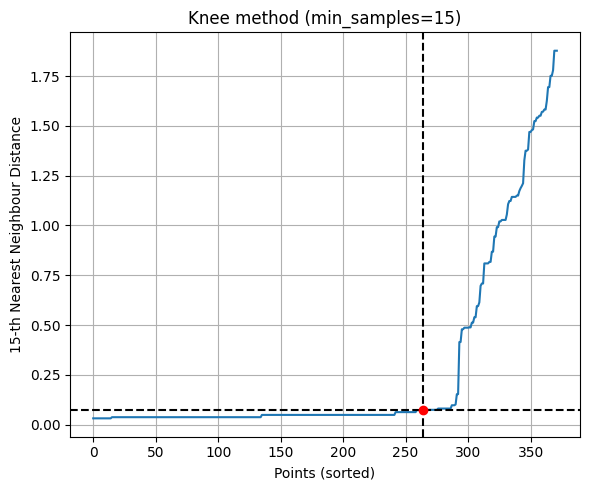

min_samples (fixed) : 15
eps (knee estimate) : 0.073
Conservative pick: eps=0.351, min_samples=16, silhouette=0.962, n_clusters=11, noise=21.2%


In [51]:
min_samples_values = range(5, 21)
eps_knee_all = dbscan_eps_knee(X, min_samples=15)

dbscan_model_all, grid_df_all = dbscan_grid_search_narrow(X, eps_knee_all, min_samples_values, verbose = False)

row = dbscan_conservative_pick(grid_df_all)
dbscan_model_all = DBSCAN(eps=row["eps"], min_samples=int(row["min_samples"])).fit(X)
y_pred_dbscan_all = dbscan_model_all.labels_

print(f"Conservative pick: eps={row['eps']:.3f}, min_samples={int(row['min_samples'])}, "
      f"silhouette={row['silhouette']:.3f}, n_clusters={int(row['n_clusters'])}, "
      f"noise={row['noise_frac']:.1%}")



We skip the sorted similarity matrix for DBSCAN. That plot works by ordering points on both axes by cluster label, so a good partition shows dense diagonal blocks. With 21.2% of points labelled noise, a big chunk of the matrix would end up as one block grouping together points that don't actually belong together  that are just the ones DBSCAN couldn't assign anywhere, not a coherent group with real internal similarity. That block would look messy basically by definition and wouldn't tell us anything useful about the real clusters.

On top of that, DBSCAN can recover non-convex, irregularly shaped clusters, so even the genuine clusters might not show up as neat bounded blocks the way Ward's compact, roughly spherical ones did. A fuzzy-looking block here could just as easily reflect uneven density as a bad partition. Given both problems, this plot is more likely to mislead than help, so we skip it for DBSCAN and lean on the PCA/t-SNE projections and the external metrics instead.

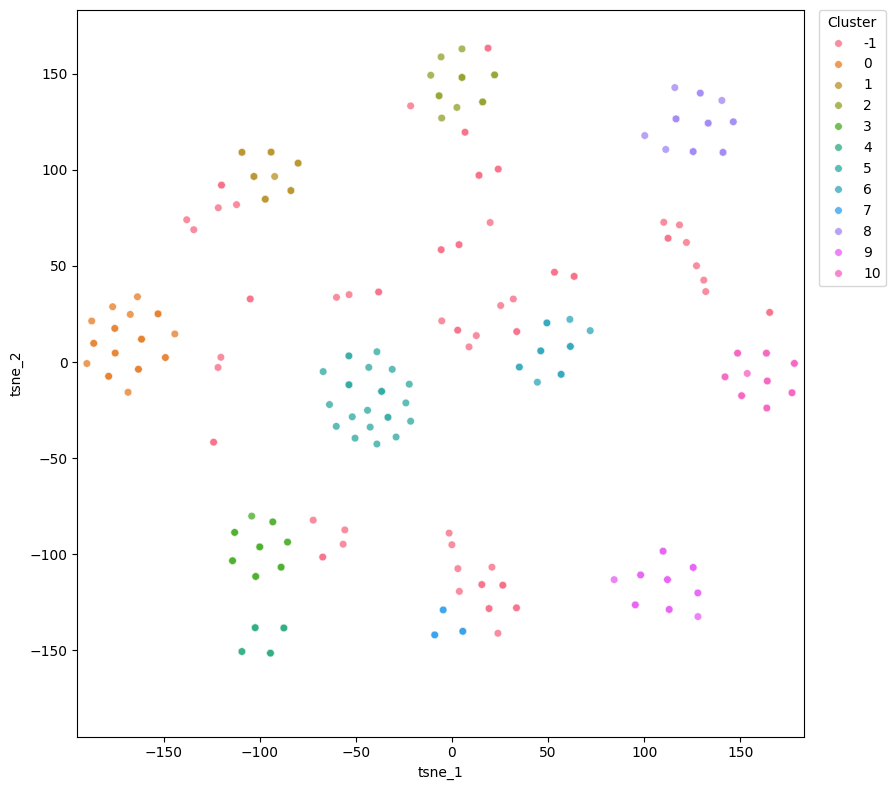

In [52]:
plot_tsne(X, y_pred_dbscan_all)

The t-SNE shows 11 fairly distinct clusters, plus a good number of noise points (label -1, pink) scattered around. Noise points are exactly the ones DBSCAN couldn't assign to any dense region, so there's no reason for them to cluster together here either, and indeed they show up at the edges of several different groups, matching the idea that they sit in low-density boundary zones between clusters.

The clusters themselves look about as well separated as the hierarchical solutions, though a couple are visibly smaller and tighter than the rest, fitting with DBSCAN's ability to isolate dense pockets of varying size instead of forcing roughly equal cluster sizes the way Ward does.

In [53]:
mask = y_pred_dbscan_all != -1
print_external_metrics(y_pred_dbscan_all[mask], y[mask], label="DBSCAN")

--- DBSCAN ---
  Adjusted Rand Index (ARI):     0.1828
  Jaccard (pairs):               0.1809
  Fowlkes-Mallows (FM):          0.4017
  Hubert's Gamma Statistic:      0.2822
  Purity:                        0.9283
  Homogeneity:                   0.7179
  Completeness:                  0.2916
  V-measure:                     0.4147


DBSCAN still comes out ahead of both hierarchical solutions overall, though the margin varies a lot depending on the metric. ARI (0.18) beats Complete linkage (0.15) and Ward (0.14), but not by much, and on the pair-based metrics DBSCAN is basically level with Complete linkage: Jaccard is actually marginally lower (0.18 vs Complete's 0.19), and FM only slightly higher (0.40 vs 0.38). Purity, homogeneity, completeness and V-measure are where DBSCAN clearly pulls ahead though : 0.93, 0.72, 0.29 and 0.41 respectively, well above what Complete or Ward manage on those same metrics.

That wide gap on purity and homogeneity suggests whatever DBSCAN does manage to group together is genuinely coherent with respect to the diagnostic label, even accounting for the fact these metrics only get computed on the points DBSCAN actually assigned somewhere, noise excluded. Completeness stays the weak spot across all three methods though : none of them fully avoid splitting a single diagnosis across multiple clusters, and here it's actually DBSCAN and Ward sitting closest together on this metric.

## Principal Component Analysis

PCA is a linear dimensionality reduction method: it finds an orthogonal basis for the feature space where the principal components are ordered by how much variance they capture. The first component points in the direction of maximum variance,

$$
w_1 = \arg\max_{\lVert w \rVert = 1} \operatorname{Var}\!\left( X w \right)
$$

and each following one maximizes the remaining variance subject to being orthogonal to everything before it.

Formally this amounts to finding the eigenvectors of the sample covariance matrix $\Sigma = \frac{1}{n-1} X^{\mathsf{T}} X$, or equivalently computing the singular value decomposition

$$
X = U \Sigma V^{\mathsf{T}}
$$

where the columns of $V$ are the loading vectors and $U\Sigma$ gives the projections onto the new axes (the scores). The variance explained by the $j$-th component is $\lambda_j / \sum_l \lambda_l$, with $\lambda_j$ the corresponding eigenvalue.

We use PCA here for three reasons.Correlated features collapse into a single component, cutting noise without throwing away the underlying signal. It helps with the curse-of-dimensionality problem that hits distance-based clustering in high dimensions. And it makes visualization possible, projecting onto the first two or three components gives the best linear 2D/3D approximation of the data.

The loadings heatmap shows how much each original feature feeds into each component . Large absolute values mean the feature is strongly aligned with that component's direction.

We pick the number of components by looking at the cumulative explained variance curve and taking the smallest $k$ covering at least 90% of total variance, trading a bit of information loss for a meaningful cut in dimensionality.

In [54]:
pca = PCA()

X_pca = pca.fit_transform(X)

<BarContainer object of 21 artists>

Text(0.5, 0, 'Component')

Text(0, 0.5, 'Explained variance (%)')

Text(0, 0.5, 'Cumulative variance (%)')

Components for 90% variance: 8
Components for 95% variance: 10


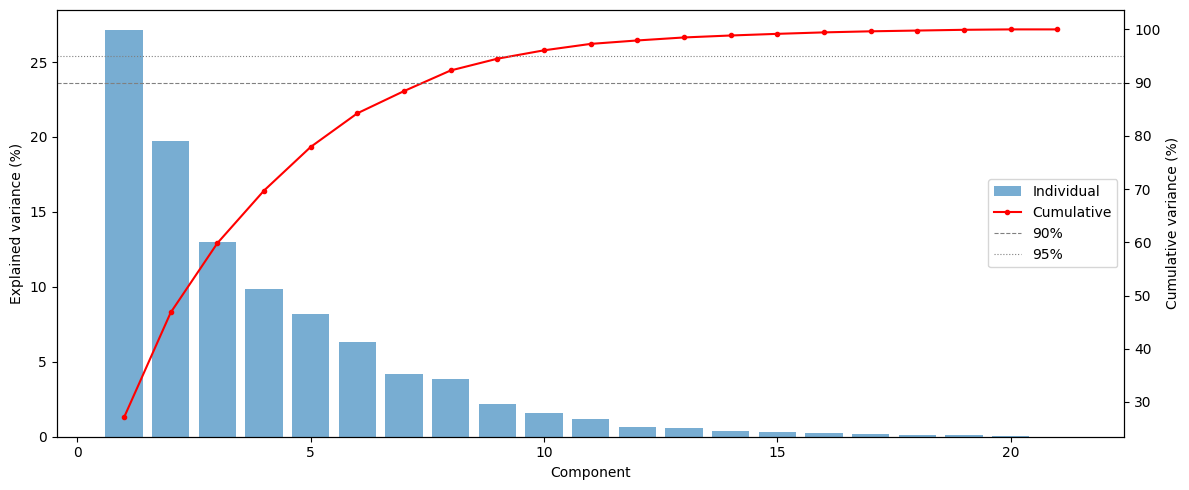

In [55]:
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

n_90 = np.argmax(cumulative >= 0.90) + 1
n_95 = np.argmax(cumulative >= 0.95) + 1

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(range(1, len(explained) + 1), explained * 100, alpha=0.6, label="Individual")
ax1.set_xlabel("Component")
ax1.set_ylabel("Explained variance (%)")

ax2 = ax1.twinx()
ax2.plot(range(1, len(cumulative) + 1), cumulative * 100, color="red", marker="o", ms=3, label="Cumulative")
ax2.axhline(90, color="gray", linestyle="--", linewidth=0.8, label="90%")
ax2.axhline(95, color="gray", linestyle=":",  linewidth=0.8, label="95%")
ax2.set_ylabel("Cumulative variance (%)")

print(f"Components for 90% variance: {n_90}")
print(f"Components for 95% variance: {n_95}")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")
plt.tight_layout()
plt.show()

The first component captures around 27% of variance, the second around 19%, and the curve flattens out gradually from there with no sharp elbow: variance is spread across a lot of components. Getting to 90% needs 8 components, 95% needs 10.

Confirms what we already saw in the PCA scatter matrices, with the first 2-3 components only cover about 60% of total variance, so a good chunk of the structure the clustering algorithms are picking up on lives in dimensions a linear 2D/3D projection just can't show. We use 8 components going forward for the PCA-reduced clustering, trading a small amount of information loss (10%) for a real cut in dimensionality.

In [56]:
N_COMPONENTS = 8

X_reduced = X_pca[:, :N_COMPONENTS]

print(f"Variance retained: {cumulative[N_COMPONENTS-1]*100:.1f}%")
print(f"Dimensions: {X.shape[1]} → {N_COMPONENTS}")

Variance retained: 92.3%
Dimensions: 21 → 8


<Figure size 1000x1200 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Attribute loadings on first 8 PCs')

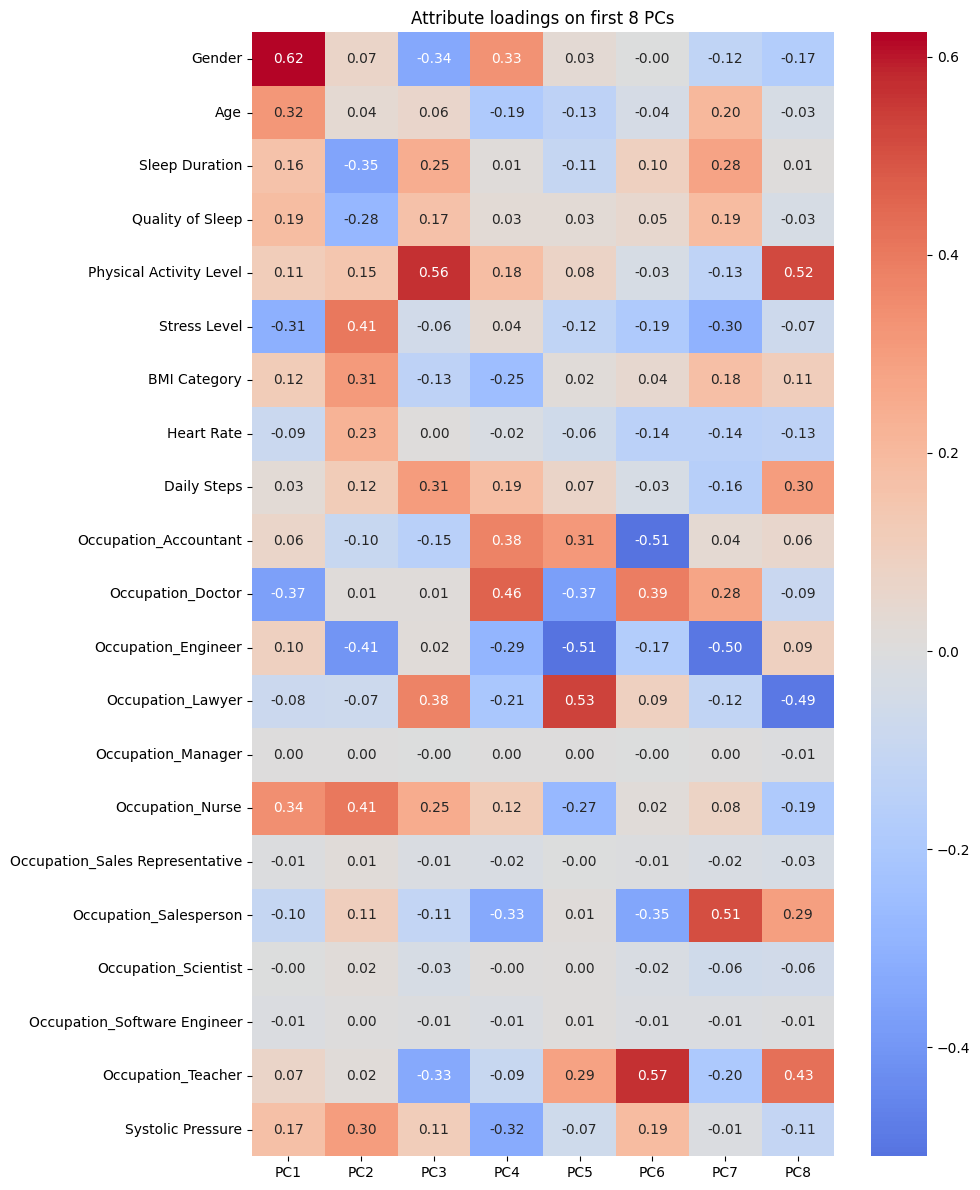

In [57]:
# Loadings heatmap: how much each original feature contributes to each PC
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_list,
    columns=[f"PC{i+1}" for i in range(pca.components_.shape[0])]
)

plt.figure(figsize=(10, 12))
sns.heatmap(loadings.iloc[:, :8], annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Attribute loadings on first 8 PCs")
plt.tight_layout()
plt.show()

The loadings heatmap shows what each of the 8 retained components is actually picking up.

PC1 is dominated by Gender (0.62) and, less strongly, Age (0.32) and Stress Level (-0.31),mostly separating people along demographic and stress lines, with occupation chipping in too (Doctor loads negative at -0.37, Nurse positive at 0.34).

PC2 is a mix of sleep and lifestyle variables: Sleep Duration (-0.35), Quality of Sleep (-0.28), Stress Level (0.41), plus Nurse (0.41) and Engineer (-0.41). Reads like it's contrasting high-stress/poor-sleep profiles against lower-stress ones, with occupation mixed in.

PC3 picks up physical activity and daily steps (0.56 and 0.31) ,basically an activity-level axis.

PC4 through PC8 get progressively more occupation-specific. PC4 loads on Doctor (0.46) and Nurse (0.12), PC5 on Lawyer (0.53) and Engineer (-0.51), PC6 on Accountant (-0.51), Salesperson (-0.35) and Teacher (0.57), PC7 on Salesperson (0.51), PC8 on Physical Activity Level (0.52) and Lawyer (-0.49). From PC4 on, the components are basically just carving out individual occupations rather than capturing broad physiological or behavioural dimensions, which is why we need 8 components to hit 90%.

### Hierarchical Clustering

#### Complete Linkage

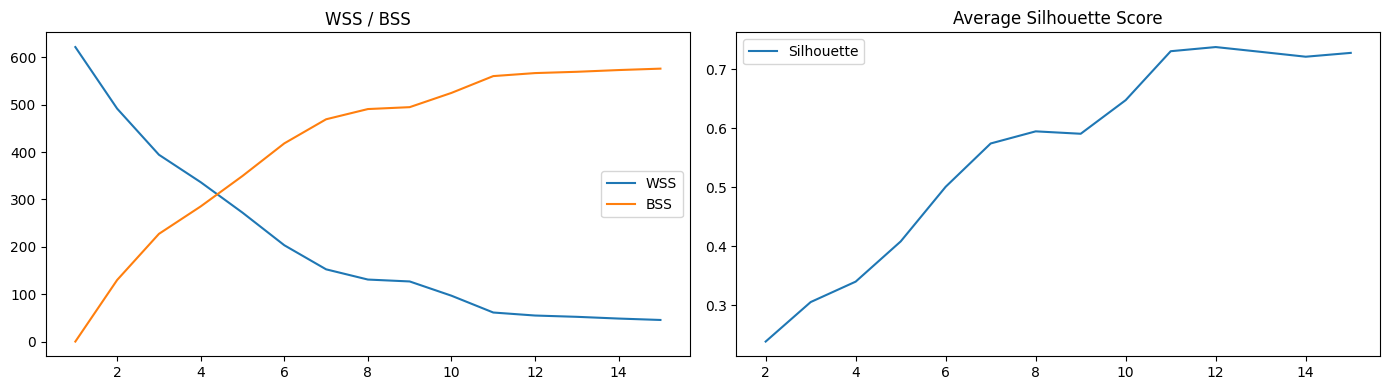

In [58]:
elbow_analysis(X_reduced, num_clus=15, method="hierarchical", linkage_method="complete", metric="euclidean")
Z_complete_pca = linkage(X_reduced, method="complete", metric="euclidean")

In [59]:
for k in [6, 7, 8, 9, 10, 11, 12, 13, 14, 15]:
    labels = fcluster(Z_complete_pca, t=k, criterion="maxclust")
    sizes = sorted([int(s) for s in np.bincount(labels)[1:]], reverse=True)
    n_tiny = sum(1 for s in sizes if s <= 3)
    print(f"k={k:2d} | sizes={sizes} | min={min(sizes)} | tiny clusters (≤3 pts)={n_tiny}")

k= 6 | sizes=[96, 68, 67, 59, 47, 35] | min=35 | tiny clusters (≤3 pts)=0
k= 7 | sizes=[68, 67, 61, 59, 47, 35, 35] | min=35 | tiny clusters (≤3 pts)=0
k= 8 | sizes=[68, 67, 61, 47, 43, 35, 35, 16] | min=16 | tiny clusters (≤3 pts)=0
k= 9 | sizes=[68, 67, 61, 47, 43, 35, 33, 16, 2] | min=2 | tiny clusters (≤3 pts)=1
k=10 | sizes=[68, 67, 47, 43, 35, 33, 32, 29, 16, 2] | min=2 | tiny clusters (≤3 pts)=1
k=11 | sizes=[67, 47, 43, 36, 35, 33, 32, 32, 29, 16, 2] | min=2 | tiny clusters (≤3 pts)=1
k=12 | sizes=[67, 47, 38, 36, 35, 33, 32, 32, 29, 16, 5, 2] | min=2 | tiny clusters (≤3 pts)=1
k=13 | sizes=[67, 42, 38, 36, 35, 33, 32, 32, 29, 16, 5, 5, 2] | min=2 | tiny clusters (≤3 pts)=1
k=14 | sizes=[67, 42, 38, 36, 35, 32, 32, 30, 29, 16, 5, 5, 3, 2] | min=2 | tiny clusters (≤3 pts)=2
k=15 | sizes=[67, 42, 36, 36, 35, 32, 32, 30, 29, 16, 5, 5, 3, 2, 2] | min=2 | tiny clusters (≤3 pts)=3


On the PCA-reduced space the cluster size story looks different from the full feature matrix. Sizes stay balanced up to k=7 (min=35), with k=8 showing a first drop to 16. From k=9 on a 2-point cluster shows up and sticks around at every higher k, meaning the silhouette scores above k=8 are inflated by a near-singleton that's trivially easy to separate.

The k=10 we set earlier is already in that fragmentation zone, so we revise it down to k=8. Last partition before near-singletons appear, and its silhouette is already well above the lower-k values.

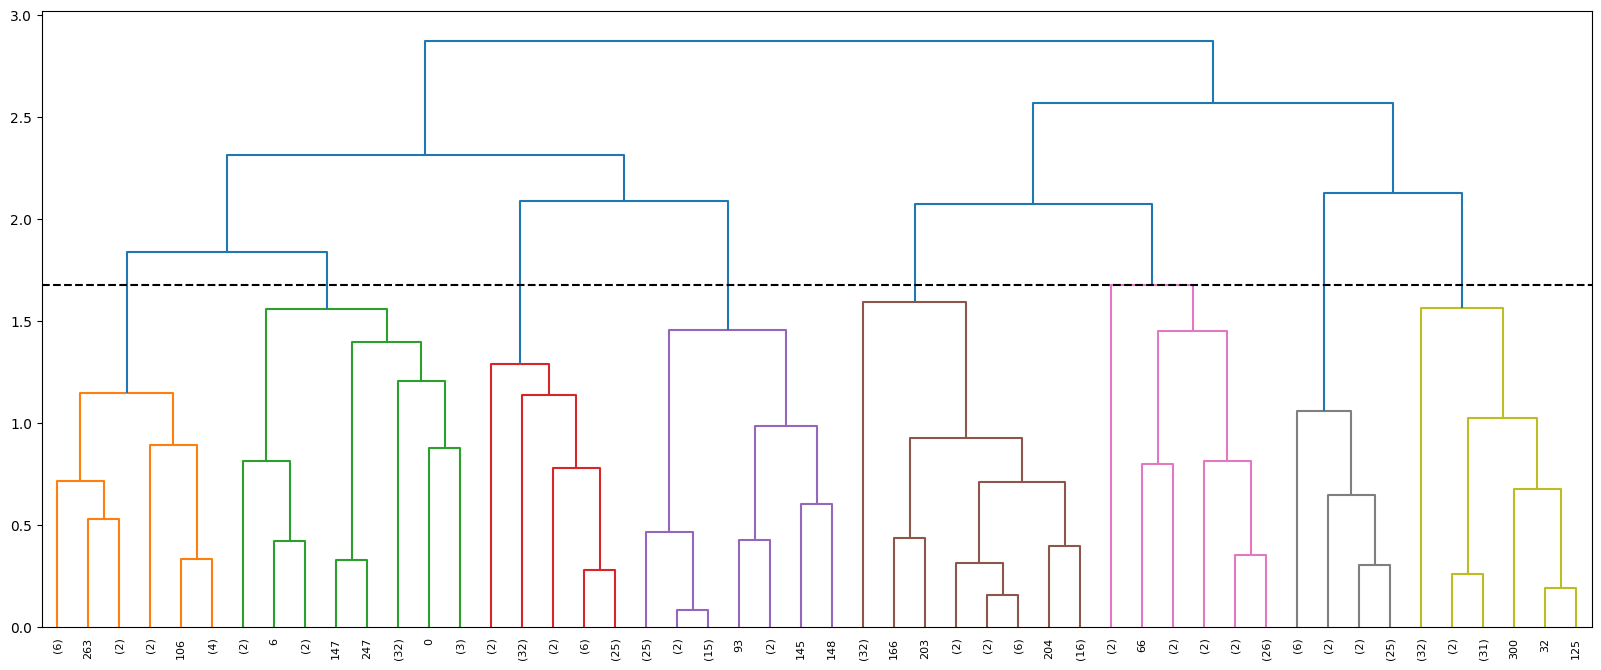

In [60]:
N_CLUSTERS_COMPLETE_PCA = 8

plot_dendrogram(Z_complete_pca, n_clusters=N_CLUSTERS_COMPLETE_PCA, truncate_mode="lastp", p=50)

The dendrogram on the PCA-reduced space looks cleaner than the full-feature version. The 8 branches above the cut (dashed line, height ≈ 1.75) are more evenly sized, and merge heights above the cut span a narrower range (roughly 2.0 to 3.0), suggesting the clusters are more homogeneous in how distinct they are from each other. in the full feature space, the occupation one-hot columns were adding weakly correlated directions that made some merges happen at very different heights. Compress those into a few components and the hierarchical structure gets more regular.

In [61]:
y_pred_complete_pca = fcluster(Z_complete_pca, t=N_CLUSTERS_COMPLETE_PCA, criterion="maxclust") - 1

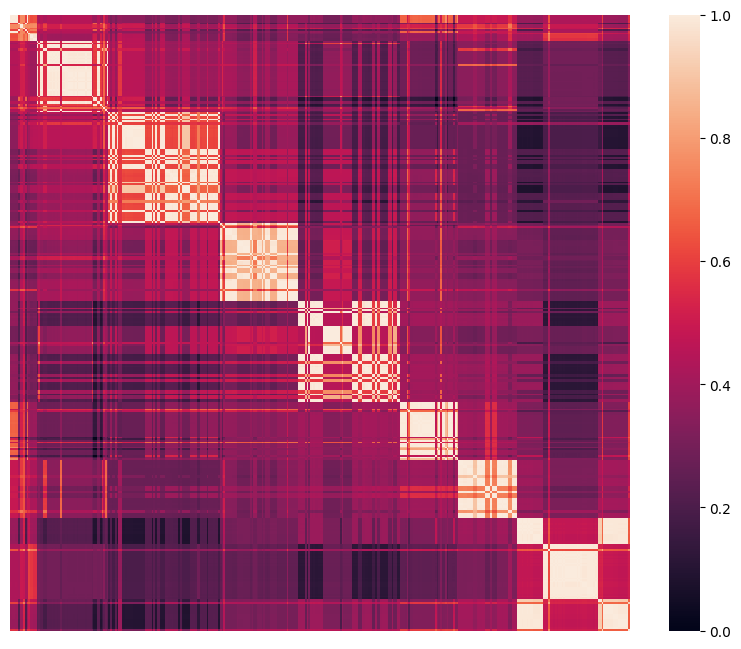

In [62]:
plot_sorted_similarity(X_reduced, y_pred_complete_pca)

The similarity matrix on the PCA-reduced space shows clearer diagonal blocks than the full-feature Complete linkage version, most of them more tightly bounded with less bleeding into neighbours. The bottom-right corner stands out with a few small, very dense white blocks, probably the smaller clusters (including the 16-point one from before). The big dark off-diagonal patches confirm the larger clusters are well separated from each other.

In [63]:
plot_pca_matrix(X, y_pred_complete_pca)

Same story as before : heavy overlap in the linear PCA projection, nothing new to read here. Skipping to t-SNE and external metrics.

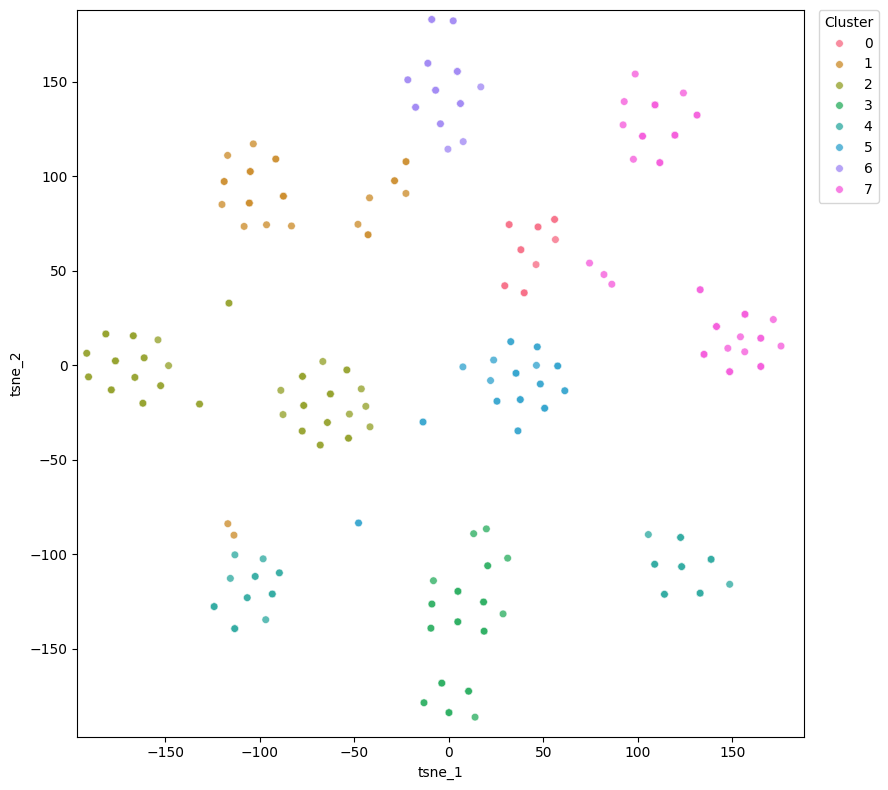

In [64]:
plot_tsne(X_reduced, y_pred_complete_pca)

The t-SNE on the PCA-reduced space shows 8 well-separated blobs with minimal overlap, cleaner than the full-feature Complete linkage t-SNE, which had more mixing between clusters. Fewer clusters, cleaner boundaries, consistent with PCA having compressed away the noisy occupation dimensions and left a more compact representation for the hierarchical algorithm to work with.

In [65]:
print_external_metrics(y_pred_complete_pca, y, label="Hierarchical Complete (PCA)")

--- Hierarchical Complete (PCA) ---
  Adjusted Rand Index (ARI):     0.2239
  Jaccard (pairs):               0.2401
  Fowlkes-Mallows (FM):          0.4502
  Hubert's Gamma Statistic:      0.2934
  Purity:                        0.8629
  Homogeneity:                   0.5429
  Completeness:                  0.2604
  V-measure:                     0.3520


PCA preprocessing gives Complete linkage a clear boost across every metric. ARI goes from 0.15 to 0.22, Jaccard 0.19 to 0.24, FM 0.38 to 0.45, purity 0.79 to 0.86, homogeneity 0.45 to 0.54, completeness 0.21 to 0.26, V-measure 0.28 to 0.35.

Already suggested by the heatmap: from PC4 on, the components were mostly capturing individual occupation categories. Compressing those into 8 components strips out a good deal of noise from the distance computations, letting Complete linkage find more coherent groups.

#### Ward Linkage

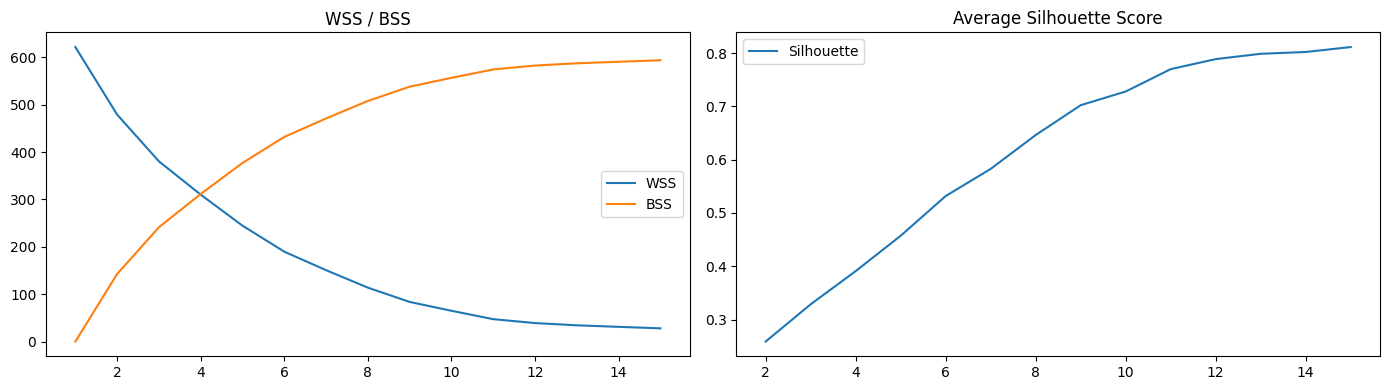

In [66]:
elbow_analysis(X_reduced, num_clus=15, method="hierarchical", linkage_method="ward", metric="euclidean")
Z_ward_pca = linkage(X_reduced, method="ward", metric="euclidean")

In [67]:
for k in [6, 7, 8, 9, 10, 11, 12, 13, 14, 15]:
    labels = fcluster(Z_ward_pca, t=k, criterion="maxclust")
    sizes = sorted([int(s) for s in np.bincount(labels)[1:]], reverse=True)
    n_tiny = sum(1 for s in sizes if s <= 3)
    print(f"k={k:2d} | sizes={sizes} | min={min(sizes)} | tiny clusters (≤3 pts)={n_tiny}")

k= 6 | sizes=[81, 70, 70, 61, 47, 43] | min=43 | tiny clusters (≤3 pts)=0
k= 7 | sizes=[70, 70, 61, 47, 46, 43, 35] | min=35 | tiny clusters (≤3 pts)=0
k= 8 | sizes=[70, 61, 47, 46, 43, 38, 35, 32] | min=32 | tiny clusters (≤3 pts)=0
k= 9 | sizes=[70, 47, 46, 43, 38, 35, 32, 32, 29] | min=29 | tiny clusters (≤3 pts)=0
k=10 | sizes=[70, 47, 43, 38, 35, 32, 32, 30, 29, 16] | min=16 | tiny clusters (≤3 pts)=0
k=11 | sizes=[47, 43, 38, 37, 35, 33, 32, 32, 30, 29, 16] | min=16 | tiny clusters (≤3 pts)=0
k=12 | sizes=[47, 38, 37, 35, 33, 32, 32, 32, 30, 29, 16, 11] | min=11 | tiny clusters (≤3 pts)=0
k=13 | sizes=[47, 37, 35, 33, 33, 32, 32, 32, 30, 29, 16, 11, 5] | min=5 | tiny clusters (≤3 pts)=0
k=14 | sizes=[47, 37, 35, 33, 33, 32, 32, 32, 30, 29, 16, 6, 5, 5] | min=5 | tiny clusters (≤3 pts)=0
k=15 | sizes=[47, 35, 33, 33, 32, 32, 32, 32, 30, 29, 16, 6, 5, 5, 5] | min=5 | tiny clusters (≤3 pts)=0


Ward on the PCA-reduced space gives the cleanest size distribution we've seen so far: no tiny clusters even at k=15, and the minimum size shrinks gradually instead of collapsing suddenly. Sizes stay fully balanced up to k=9 (min=29), a 16-point cluster shows up at k=10 and stays stable through k=11. From k=12 on the minimum keeps shrinking but stays above 5 points across the whole range checked.

k=11 holds up as a reasonable pick: the size profile doesn't get worse between k=10 and k=11, and the silhouette curve backs this range too. N_CLUSTERS_WARD_PCA = 11.

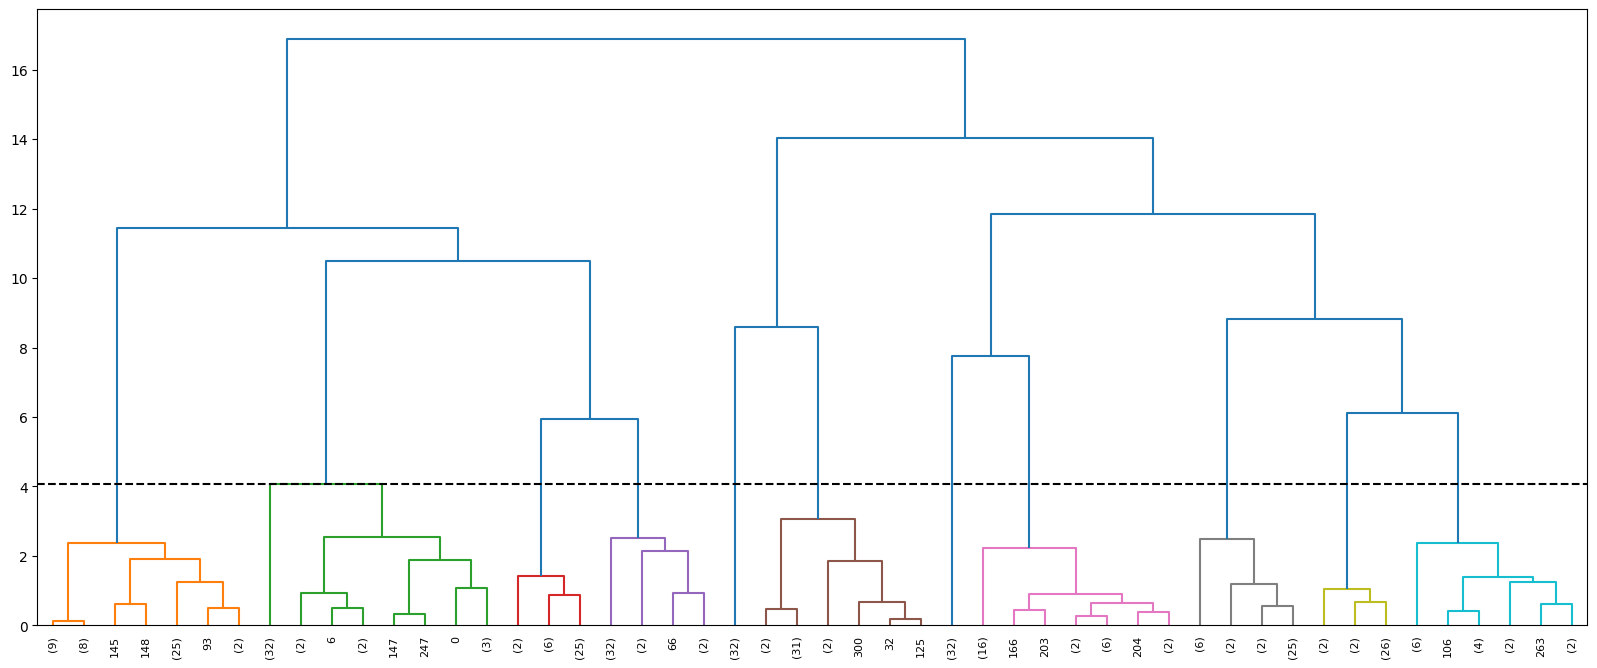

In [68]:
N_CLUSTERS_WARD_PCA = 11
plot_dendrogram(Z_ward_pca, n_clusters=N_CLUSTERS_WARD_PCA, truncate_mode="lastp", p=50)

The dendrogram on the PCA-reduced space shows a much more regular structure than any of the full-feature versions: merge heights above the cut (dashed line, height ≈ 4) span a wide range (6 to 16), but the branches are more evenly balanced left-to-right, with no single branch swallowing most of the data. Ward on 8 PCA components gives the most balanced partition of anything we've tried, with clusters that stay genuinely comparable in size across the whole range of k.

In [69]:
y_pred_ward_pca = fcluster(Z_ward_pca, t=N_CLUSTERS_WARD_PCA, criterion="maxclust") - 1

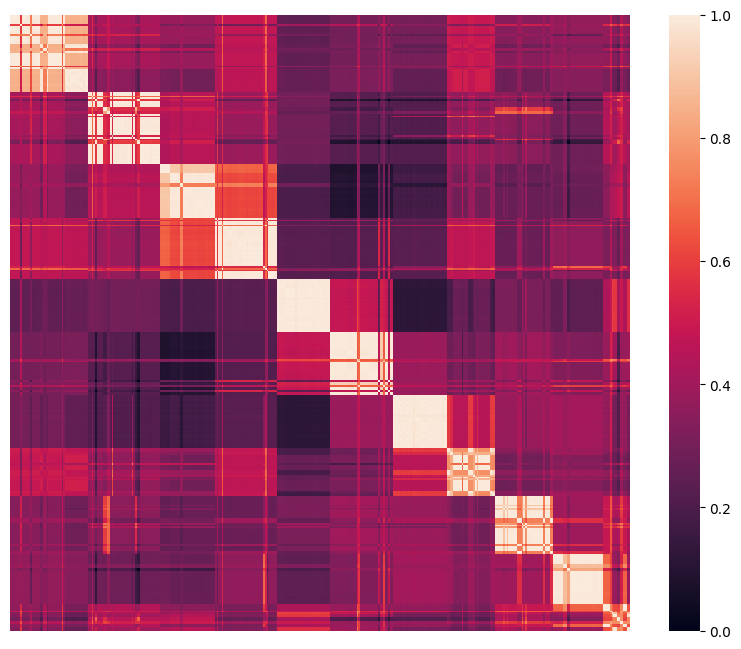

In [70]:
plot_sorted_similarity(X_reduced, y_pred_ward_pca)

The similarity matrix here is messier than we expected given how clean the size distribution was. A few diagonal blocks are well defined and dense, but there's a fair amount of off-diagonal bleeding: some clusters share high similarity with their neighbours, showing up as light patches away from the diagonal. So while Ward on PCA gives balanced cluster sizes, some of those clusters actually sit in overlapping regions of the 8-component space.

In [71]:
plot_pca_matrix(X, y_pred_ward_pca)

Same story as all the other PCA scatter matrices: skipping to t-SNE and external metrics.

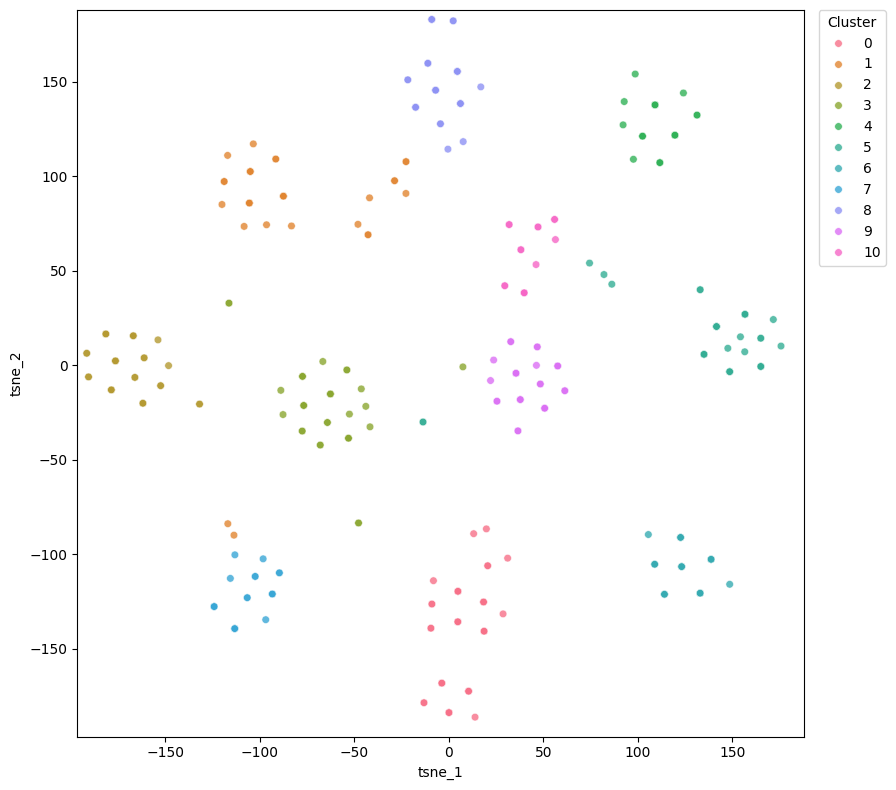

In [72]:
plot_tsne(X_reduced, y_pred_ward_pca)

The t-SNE shows 11 well-separated blobs with very little overlap, one of the cleanest projections we've gotten across the whole notebook. Clusters look reasonably uniform in size visually, matching Ward's balancing tendency, and there are no isolated points or near-singletons. The slight overlap flagged in the similarity matrix doesn't seem to show up as visible mixing here, so those overlapping regions are probably fairly contained.

In [73]:
print_external_metrics(y_pred_ward_pca, y, label="Hierarchical Ward (PCA)")

--- Hierarchical Ward (PCA) ---
  Adjusted Rand Index (ARI):     0.1400
  Jaccard (pairs):               0.1572
  Fowlkes-Mallows (FM):          0.3549
  Hubert's Gamma Statistic:      0.2153
  Purity:                        0.8575
  Homogeneity:                   0.5411
  Completeness:                  0.2197
  V-measure:                     0.3126


Ward on PCA gives numbers almost identical to Ward on the full feature space: ARI (0.14), purity (0.86), homogeneity (0.54), completeness (0.22) and V-measure (0.31) are all within a few thousandths of the full-feature Ward results. So unlike Complete linkage, PCA preprocessing doesn't really help Ward here.

A bit unexpected given how much cleaner the t-SNE and dendrogram look. Our best guess is that Ward is already robust to the high-dimensional occupation noise: its variance-minimization objective naturally downweights low-variance directions, so the one-hot occupation columns (each low-variance individually) contribute less to merge decisions than they would in a distance-based method like Complete linkage. PCA is basically doing the same thing explicitly, so the two approaches converge on very similar partitions, and neither aligns with the diagnostic labels much better than the other.

Complete linkage on PCA (ARI=0.22, V-measure=0.35) is still the best-performing hierarchical setup we've found.

### K-MEANS

#### Random Initialization

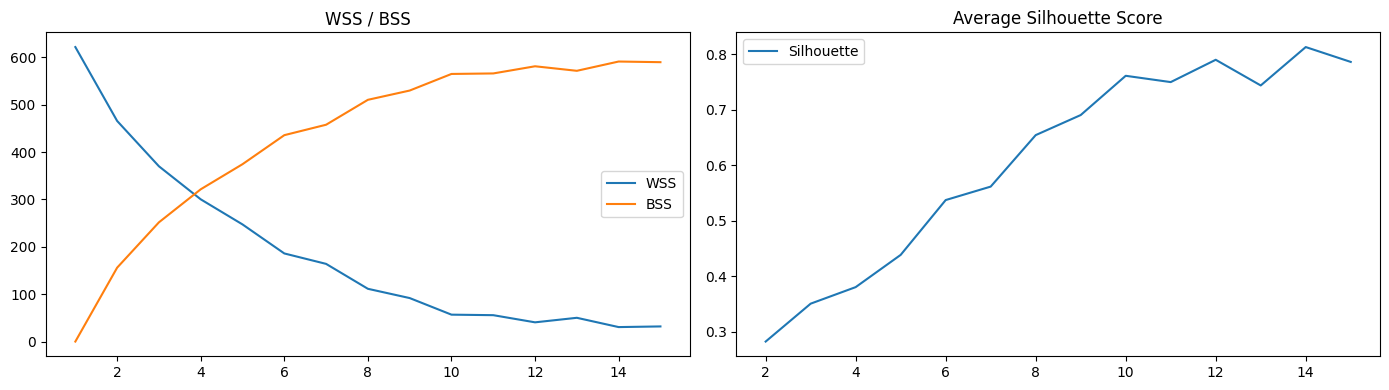

In [74]:
elbow_analysis(X_reduced, 15, method="kmeans", init="random")

In [75]:
for k in [6, 7, 8, 9, 10, 11, 12, 13, 14, 15]:
    km = KMeans(n_clusters=k, init="random", random_state=0, n_init=50)
    labels = km.fit_predict(X_reduced)
    sizes = sorted([int(s) for s in np.bincount(labels)], reverse=True)
    n_tiny = sum(1 for s in sizes if s <= 3)
    print(f"k={k:2d} | sizes={sizes} | min={min(sizes)} | tiny clusters (≤3 pts)={n_tiny}")

k= 6 | sizes=[79, 73, 67, 62, 49, 42] | min=42 | tiny clusters (≤3 pts)=0
k= 7 | sizes=[73, 67, 62, 49, 45, 39, 37] | min=37 | tiny clusters (≤3 pts)=0
k= 8 | sizes=[73, 67, 47, 43, 39, 39, 32, 32] | min=32 | tiny clusters (≤3 pts)=0
k= 9 | sizes=[67, 49, 43, 39, 38, 37, 37, 32, 30] | min=30 | tiny clusters (≤3 pts)=0
k=10 | sizes=[47, 43, 37, 37, 37, 36, 36, 36, 32, 31] | min=31 | tiny clusters (≤3 pts)=0
k=11 | sizes=[47, 38, 38, 37, 37, 37, 36, 33, 32, 31, 6] | min=6 | tiny clusters (≤3 pts)=0
k=12 | sizes=[46, 37, 37, 34, 34, 34, 33, 32, 32, 30, 19, 4] | min=4 | tiny clusters (≤3 pts)=0
k=13 | sizes=[45, 37, 37, 35, 34, 33, 32, 32, 32, 30, 11, 10, 4] | min=4 | tiny clusters (≤3 pts)=0
k=14 | sizes=[47, 37, 35, 33, 32, 32, 32, 32, 31, 30, 17, 10, 2, 2] | min=2 | tiny clusters (≤3 pts)=2
k=15 | sizes=[37, 34, 33, 33, 32, 32, 32, 31, 30, 30, 17, 16, 10, 3, 2] | min=2 | tiny clusters (≤3 pts)=2


On the PCA-reduced space, random init gives a much cleaner size distribution than on the full feature matrix. Sizes stay balanced from k=6 to k=10, all between 31 and 47 points, no notable drops. At k=11 the minimum falls sharply to 6 and from k=14 on tiny 2-point clusters show up.

k=10 is the natural cutoff then, and it's better supported here than the k=11 we ended up with on the full feature matrix. N_CLUSTERS_KRND_PCA = 10.

In [76]:
N_CLUSTERS_KRND_PCA = 10

kmeans_pca = KMeans(n_clusters= N_CLUSTERS_KRND_PCA, init="random", random_state=0, n_init=50)
y_pred_kmeans_pca = kmeans_pca.fit_predict(X_reduced)

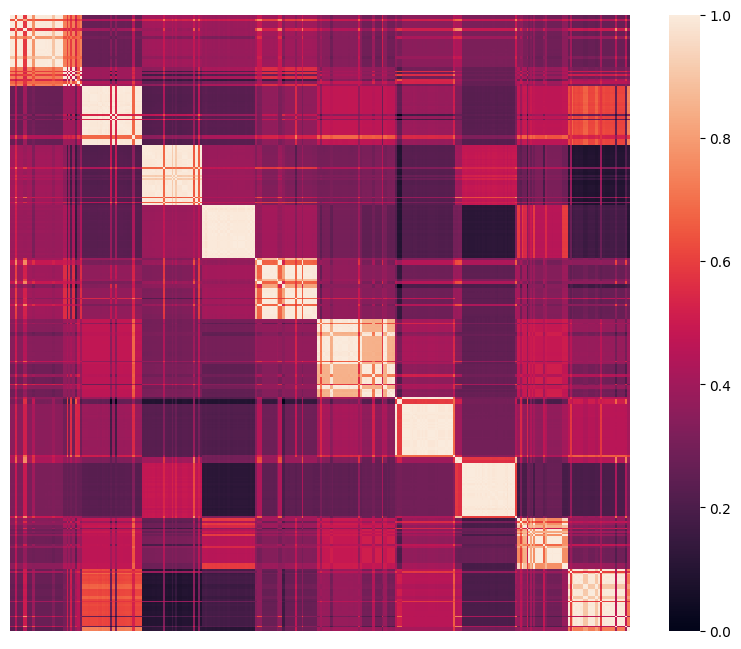

In [77]:
plot_sorted_similarity(X_reduced, y_pred_kmeans_pca)

The similarity matrix for k-means random init on PCA shows the same pattern as the full-feature version  with diagonal blocks visible, but with heavy off-diagonal bleeding and uneven block quality. PCA doesn't seem to improve the internal geometric structure for random-init k-means, matching the idea that random init is the main source of instability here, not the dimensionality of the feature space.

In [78]:
plot_pca_matrix(X, y_pred_kmeans_pca)

Same story as all the other PCA scatter matrices: skipping to t-SNE and external metrics.

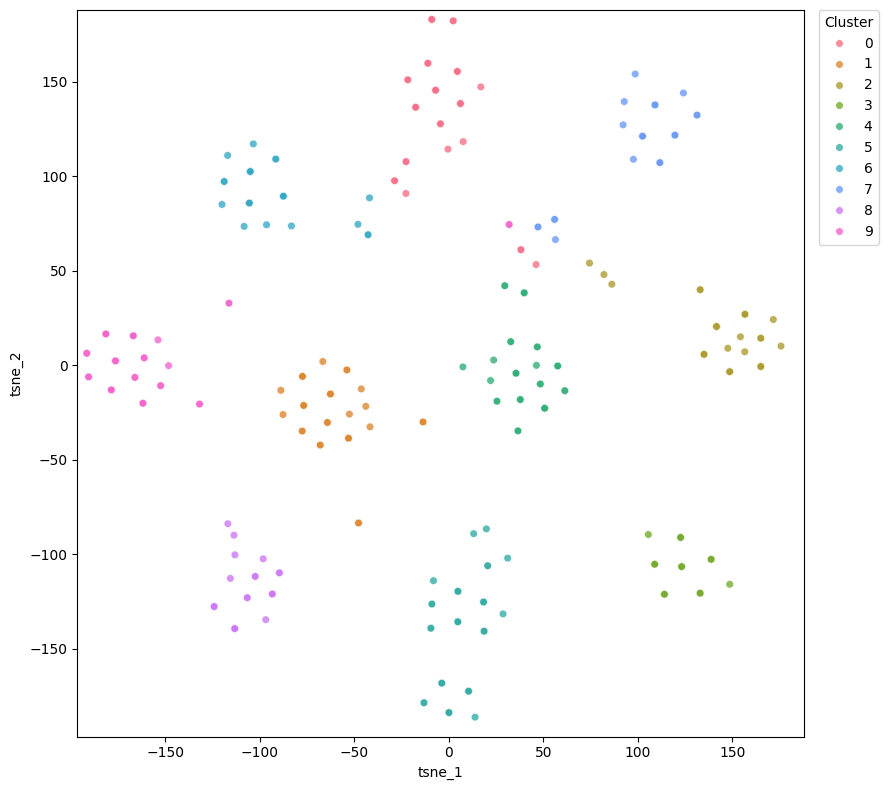

In [79]:
plot_tsne(X_reduced, y_pred_kmeans_pca)

The t-SNE on PCA-reduced data shows cleaner separation than the full-feature random-init version: most blobs are more distinct with less inter-cluster mixing, matching PCA having removed some of the noise dimensions blurring the boundaries. Centre region is still the most crowded, but overall the partition looks more coherent here.

In [80]:
print_external_metrics(y_pred_kmeans_pca, y, label="K-means Random Initialization (PCA)")

--- K-means Random Initialization (PCA) ---
  Adjusted Rand Index (ARI):     0.1328
  Jaccard (pairs):               0.1577
  Fowlkes-Mallows (FM):          0.3490
  Hubert's Gamma Statistic:      0.1992
  Purity:                        0.8414
  Homogeneity:                   0.5041
  Completeness:                  0.2113
  V-measure:                     0.2978


PCA preprocessing doesn't help random-init k-means. Every metric is slightly lower than the full-feature version: ARI drops from 0.14 to 0.13, purity from 0.85 to 0.84, homogeneity from 0.56 to 0.50, V-measure from 0.32 to 0.30. Mirrors what we saw with Ward PCA: when the main source of instability is the initialization strategy, stripping out noise dimensions doesn't translate into better label alignment. Random init on 8 components isn't any more coherent with the diagnostic labels than random init on the full feature matrix.

#### K-Means ++ Initialization

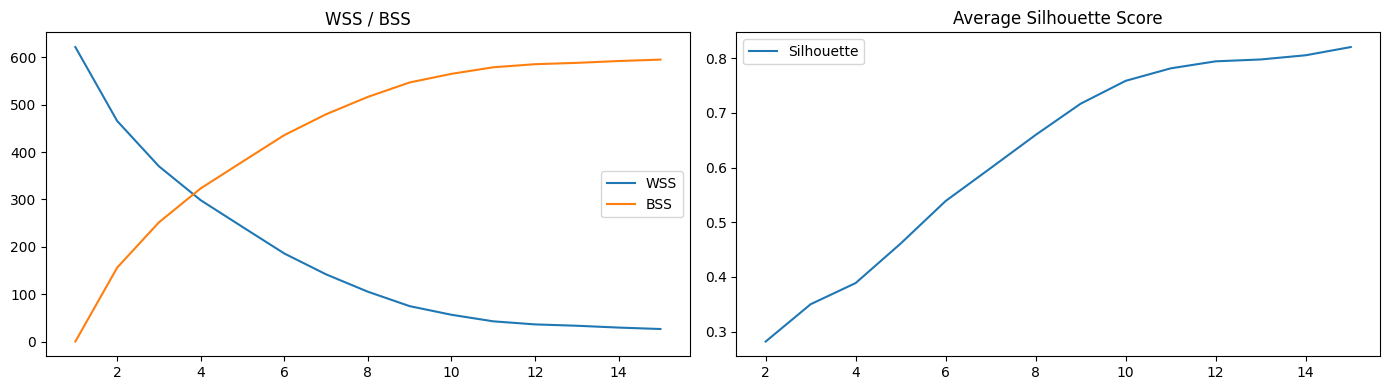

In [81]:
elbow_analysis(X_reduced, 15, method="kmeans", init="k-means++")

In [82]:
for k in [6, 7, 8, 9, 10, 11, 12, 13, 14, 15]:
    km = KMeans(n_clusters=k, init="k-means++", random_state=0, n_init=50)
    labels = km.fit_predict(X_reduced)
    sizes = sorted([int(s) for s in np.bincount(labels)], reverse=True)
    n_tiny = sum(1 for s in sizes if s <= 3)
    print(f"k={k:2d} | sizes={sizes} | min={min(sizes)} | tiny clusters (≤3 pts)={n_tiny}")

k= 6 | sizes=[79, 73, 67, 62, 49, 42] | min=42 | tiny clusters (≤3 pts)=0
k= 7 | sizes=[73, 67, 62, 49, 42, 40, 39] | min=39 | tiny clusters (≤3 pts)=0
k= 8 | sizes=[67, 62, 49, 42, 40, 38, 37, 37] | min=37 | tiny clusters (≤3 pts)=0
k= 9 | sizes=[67, 49, 42, 40, 38, 37, 37, 32, 30] | min=30 | tiny clusters (≤3 pts)=0
k=10 | sizes=[47, 43, 41, 37, 37, 36, 36, 33, 32, 30] | min=30 | tiny clusters (≤3 pts)=0
k=11 | sizes=[45, 40, 36, 36, 35, 35, 32, 32, 31, 31, 19] | min=19 | tiny clusters (≤3 pts)=0
k=12 | sizes=[45, 37, 36, 35, 33, 32, 32, 32, 31, 30, 19, 10] | min=10 | tiny clusters (≤3 pts)=0
k=13 | sizes=[45, 37, 35, 34, 33, 32, 32, 32, 31, 30, 19, 8, 4] | min=4 | tiny clusters (≤3 pts)=0
k=14 | sizes=[45, 35, 35, 34, 33, 32, 32, 32, 31, 30, 19, 5, 5, 4] | min=4 | tiny clusters (≤3 pts)=0
k=15 | sizes=[47, 35, 33, 32, 32, 32, 32, 31, 30, 29, 19, 6, 5, 5, 4] | min=4 | tiny clusters (≤3 pts)=0


K-means++ on PCA gives the same clean size profile as on the full feature matrix. Sizes stay balanced from k=6 to k=10, all between 30 and 47 points. At k=11 the minimum drops to 19, and from k=13 on clusters of 4 points start appearing, though nothing at 3 points or fewer even at k=15, matches k-means++ being more stable than random init.

k=10 is the natural cutoff, same as the full-feature version.

In [83]:
N_CLUSTERS_KP_PCA = 10
kmeans_plus_pca = KMeans(n_clusters=N_CLUSTERS_KP_PCA, init="k-means++", random_state=0, n_init=50) #decidi numero cluster
y_pred_kmeans_plus_pca = kmeans_plus_pca.fit_predict(X_reduced)

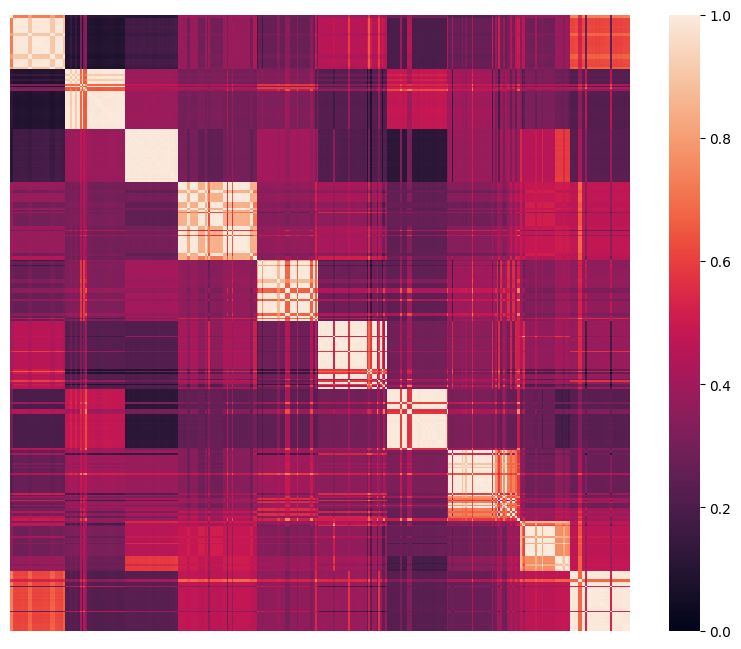

In [84]:
plot_sorted_similarity(X_reduced, y_pred_kmeans_plus_pca)

Similar to the full-feature k-means++ similarity matrix ,diagonal blocks visible but with heavy off-diagonal bleeding. No real improvement from PCA, matching the idea that the initialization strategy is the binding constraint here, not dimensionality. Block structure looks comparable to the random-init PCA version too, confirming that on this dataset the choice of initialization matters less than the choice of algorithm altogether.

In [85]:
plot_pca_matrix(X, y_pred_kmeans_plus_pca)

Same as all the other PCA scatter matrices: heavy overlap across all three projection planes, first three components covering around 60% of total variance. The lack of visible separation here doesn't say anything about partition quality; it just means k-means++ on 8 PCA components, like every other configuration, finds clusters whose boundaries don't line up with the directions of maximum linear variance. t-SNE below should be more informative.

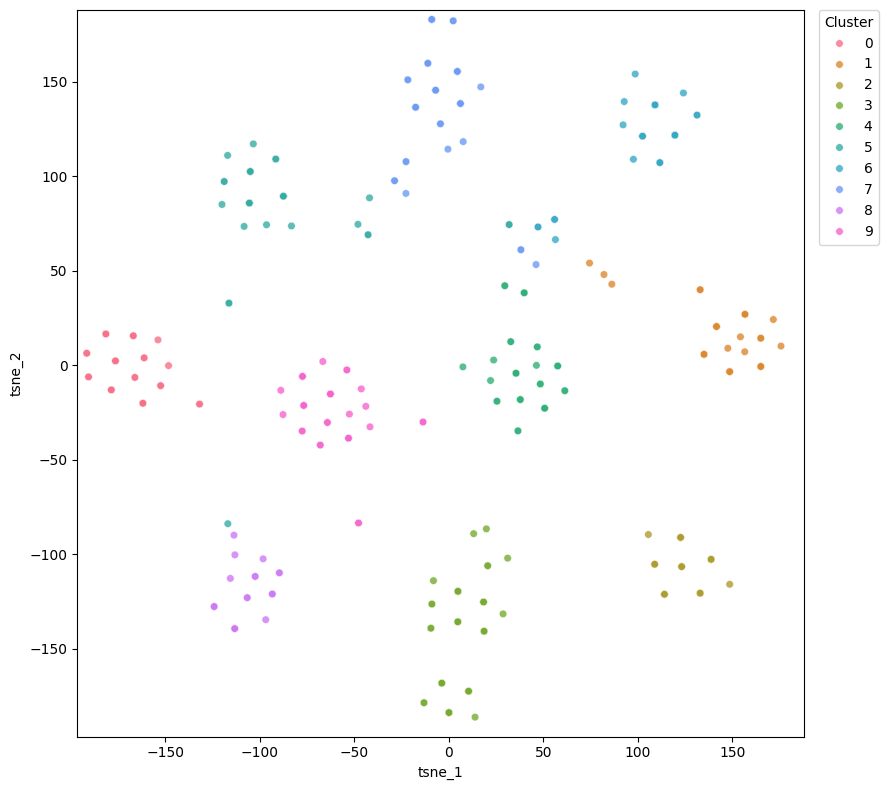

In [86]:
plot_tsne(X_reduced, y_pred_kmeans_plus_pca)

The t-SNE for k-means++ on the PCA-reduced space shows 10 well-separated blobs with minimal overlap, clean picture, matching the balanced cluster sizes from before (all between 30 and 47 points at k=10). Compared to random init on the same reduced space, the separation looks a bit more regular, with clusters spread more evenly across the projection instead of crowding toward the centre. Confirms k-means++ finds a more stable solution than random init even after PCA compression, though the overall partition geometry stays similar between the two , both are stuck with convex, isotropic clusters regardless of how the centroids got seeded.

In [87]:
print_external_metrics(y_pred_kmeans_plus_pca, y, label="K-means ++ (PCA)")

--- K-means ++ (PCA) ---
  Adjusted Rand Index (ARI):     0.1381
  Jaccard (pairs):               0.1609
  Fowlkes-Mallows (FM):          0.3549
  Hubert's Gamma Statistic:      0.2069
  Purity:                        0.8495
  Homogeneity:                   0.5282
  Completeness:                  0.2216
  V-measure:                     0.3122


K-means++ on PCA gives results almost identical to random init on the same reduced space, and marginally lower than k-means++ on the full feature matrix. ARI (0.14), Jaccard (0.16), FM (0.35), purity (0.85), homogeneity (0.53), completeness (0.22) and V-measure (0.31) are all within a few thousandths of both the random-PCA and full-feature k-means++ solutions.

The partition aligns with the diagnostic labels about the same regardless of whether the algorithm runs on 8 components or the full feature matrix. The binding constraint isn't dimensionality, it's the k-means objective itself, limited to convex, isotropic clusters. No initialization strategy or preprocessing step gets around that geometric assumption if the real cluster shapes don't conform to it.

Completeness stays the weakest metric across every k-means configuration, same broader pattern we've been seeing: splitting a single diagnosis across multiple clusters looks like a structural tendency of centroid-based methods on this dataset, not an artifact of any particular hyperparameter.

### DBSCAN

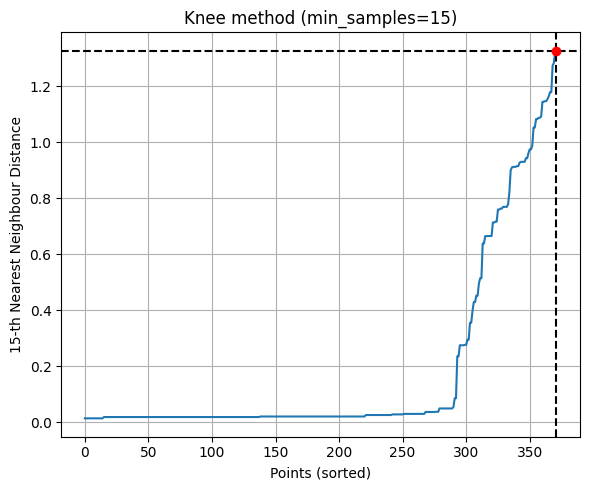

min_samples (fixed) : 15
eps (knee estimate) : 1.326
Conservative pick: eps=1.026, min_samples=5, silhouette=0.244, n_clusters=3, noise=0.5%


In [88]:
eps_knee_pca = dbscan_eps_knee(X_reduced, min_samples=15)

dbscan_model_pca, grid_df_pca = dbscan_grid_search_narrow(X_reduced, eps_knee_pca, min_samples_values, verbose = False)

row_pca = dbscan_conservative_pick(grid_df_pca)
dbscan_model_pca = DBSCAN(eps=row_pca["eps"], min_samples=int(row_pca["min_samples"])).fit(X_reduced)
y_pred_dbscan = dbscan_model_pca.labels_

print(f"Conservative pick: eps={row_pca['eps']:.3f}, min_samples={int(row_pca['min_samples'])}, "
      f"silhouette={row_pca['silhouette']:.3f}, n_clusters={int(row_pca['n_clusters'])}, "
      f"noise={row_pca['noise_frac']:.1%}")

On the PCA-reduced space, the grid search around the knee estimate (eps=1.326) settles on a very different regime than before: eps=1.03, min_samples=5, silhouette of only 0.24, just 3 clusters, and essentially no noise at 0.5%. The top rows in the table are all identical in eps and silhouette, only min_samples changes, from 5 up to 14, without moving the result at all , so this partition seems pretty stable and not particularly sensitive to min_samples once eps is fixed at this value.

Quite different picture from the full-feature case, where DBSCAN was trading noise for silhouette and finding a much larger number of tighter clusters. Here on the reduced data it converges to a coarse, low-noise partition with far fewer clusters and a silhouette well below what full-feature DBSCAN reached. Best guess: compressing down to a handful of principal components changes the density landscape enough that only a few broad, well-separated dense regions remain visible at the eps scale the knee method picks out, instead of the finer-grained structure that was visible in the full 21-dimensional space.

Since there's no real noise-vs-silhouette tradeoff to weigh here, unlike in other configurations, we just keep the grid search result as-is rather than hunting for a more conservative alternative, with noise already under 1%, there's nothing left to trade off against.

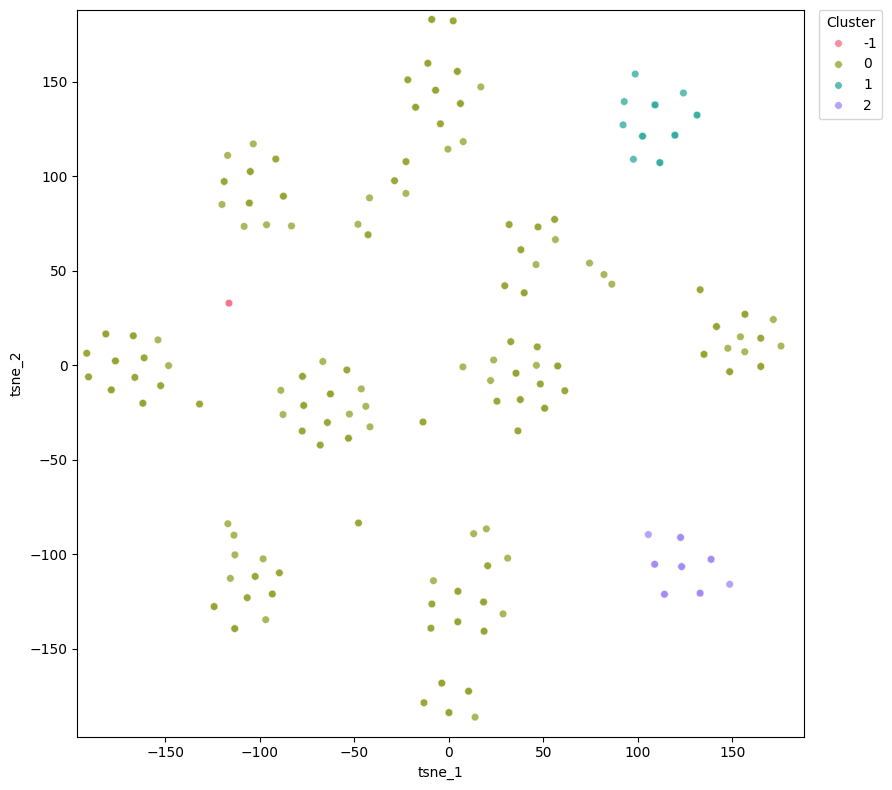

In [89]:
plot_tsne(X_reduced, y_pred_dbscan)

The t-SNE on the PCA-reduced space shows a completely different structure from the full-feature DBSCAN projection. Looking at cluster sizes, one cluster alone takes 306 of the 372 points, with the other two at 32 points each and only 2 points labelled noise. In the t-SNE this shows up as one large, sprawling blob covering most of the plot, with two much smaller, tighter groups off to the side.

Direct consequence of the much coarser eps here: at eps=1.03, DBSCAN merges what were 9-10 separate dense regions on the full feature space into essentially one big region plus two small pockets. The near-zero noise fraction, which looked good on paper, turns out to just be a side effect of that coarseness, with eps this large, almost every point ends up close enough to some core point to get absorbed into the dominant cluster, leaving little room for anything to be flagged as noise. Combined with the low silhouette, this points to a low-information partition and it's probably why this configuration does noticeably worse on external metrics than the full-feature DBSCAN result.

In [90]:
mask = y_pred_dbscan != -1
print_external_metrics(y_pred_dbscan[mask], y[mask], label="DBSCAN (PCA)")

--- DBSCAN (PCA) ---
  Adjusted Rand Index (ARI):     0.0664
  Jaccard (pairs):               0.3935
  Fowlkes-Mallows (FM):          0.5811
  Hubert's Gamma Statistic:      0.0769
  Purity:                        0.6649
  Homogeneity:                   0.1501
  Completeness:                  0.2480
  V-measure:                     0.1870


DBSCAN on the PCA-reduced space does considerably worse than the full-feature DBSCAN result on almost every metric. ARI drops to 0.07 (from 0.18), Hubert's Gamma to 0.08 (from 0.28), purity to 0.66 (from 0.93), homogeneity to 0.15 (from 0.72), V-measure to 0.19 (from 0.41). Only Jaccard (0.39, up from 0.18) and FM (0.58, up from 0.40) come out higher, which is a known artifact of pair-based metrics under a heavily imbalanced partitio: a single dominant cluster inflates the count of correctly-kept-together pairs almost by construction.

Homogeneity collapsing to 0.15 means the dominant cluster mixes several diagnostic classes together, which is also why purity, at 0.66, sits far below what either the full-feature DBSCAN or the hierarchical solutions reached on the same label.

Compared to everything else tested so far, DBSCAN on PCA is now the weakest performer on external metrics, a complete reversal from the full feature space. The gap between the two DBSCAN configurations tell us that the knee-based eps estimate doesn't automatically give a partition that lines up well with the diagnostic labels and here it clearly doesn't.

## Model Selection

Ten configurations have been fitted at this point: Complete linkage, Ward, k-means with random init, k-means++ and DBSCAN, each on the full feature matrix and on the 8-component PCA space. Picking one means weighing criteria that measure different, partly conflicting things, so no single number is treated as sufficient on its own. We use exactly the metrics already computed above, read side by side.

**Internal criteria: Silhouette, WSS, BSS.** These judge the geometry of a partition without touching any external information. For each point $i$,

$$
s(i) = \frac{b(i) - a(i)}{\max\left( a(i),\, b(i) \right)},
\qquad
\bar{s} = \frac{1}{n} \sum_{i=1}^{n} s(i)
$$

where $a(i)$ is the mean distance to the other points of its own cluster and $b(i)$ the mean distance to the points of the nearest other cluster. Values near $1$ mean the point sits well inside its cluster and far from the others, near $0$ means overlap, negative suggests misassignment. Alongside it we track the variance decomposition

$$
\mathrm{WSS} = \sum_{k} \sum_{x \in C_k} \lVert x - \mu_k \rVert^2,
\qquad
\mathrm{BSS} = \mathrm{TSS} - \mathrm{WSS} = \sum_{k} n_k \lVert \mu_k - \bar{x} \rVert^2
$$

so that a good partition shows low WSS relative to BSS.

**External criteria: ARI and V-measure.** These check alignment with the `Sleep Disorder` label, which no algorithm ever saw during fitting. With $n_{ij}$ the contingency counts between the $k$ predicted clusters and the true classes, $a_i$ and $b_j$ their row and column sums, the Adjusted Rand Index is

$$
\mathrm{ARI} =
\frac{\sum_{ij} \binom{n_{ij}}{2} - \dfrac{\sum_i \binom{a_i}{2} \sum_j \binom{b_j}{2}}{\binom{n}{2}}}
{\dfrac{1}{2}\left[ \sum_i \binom{a_i}{2} + \sum_j \binom{b_j}{2} \right] - \dfrac{\sum_i \binom{a_i}{2} \sum_j \binom{b_j}{2}}{\binom{n}{2}}}
$$

which corrects the plain Rand Index for the agreement expected by chance, so a random partition scores around $0$ and a perfect match scores $1$. V-measure instead is the harmonic mean of homogeneity $h$ (each cluster contains only one class) and completeness $c$ (all members of a class land in the same cluster):

$$
h = 1 - \frac{H(C \mid K)}{H(C)},
\qquad
c = 1 - \frac{H(K \mid C)}{H(K)},
\qquad
V = \frac{2 \, h \, c}{h + c}
$$

**How the final model is chosen.** We deliberately avoid collapsing these into a single aggregate score: the metrics live on different scales, measure different notions of quality, and any weighting we picked would be arbitrary. Instead we look at the internal and the external ranking separately, and choose the configuration that balances them, keeping two structural constraints in mind:

1. **Coverage.** Silhouette for DBSCAN is computed only on the points it actually assigns, so it is not directly comparable to the value of a method that classifies every point. A configuration leaving ~21% of the subjects unlabelled is also of limited use for the profiling step that follows.
2. **Cluster-size balance.** A partition whose silhouette is propped up by near-singleton clusters is not a better partition, just a partition with easy points carved off. Cluster sizes across $k$ were checked for every configuration precisely for this reason.

The model carried forward is the one that is strong internally, classifies every point, keeps cluster sizes balanced, and still shows non-trivial (if modest) external agreement  with the best external performer flagged explicitly wherever its stronger label alignment is relevant.

In [91]:
results_all = {
    "Hierarchical Complete": y_pred_complete,
    "Hierarchical Ward":     y_pred_ward,
    "K-Means Random":        y_pred_kmeans,
    "K-Means++":             y_pred_kmeans_plus,
    "DBSCAN":                y_pred_dbscan_all,
}

table_all = clustering_comparison_table(results_all, X, y)
table_all

,k,Noise pts,Silhouette,WSS,BSS,ARI,FM,Purity,Homogeneity,Completeness,V-measure
Method,,,,,,,,,,,
Hierarchical Complete,10,0,0.5926,157.50,516.19,0.1519,0.3798,0.7876,0.4520,0.2060,0.2831
Hierarchical Ward,11,0,0.7364,89.71,583.98,0.1403,0.3541,0.8548,0.5785,0.2325,0.3317
K-Means Random,11,0,0.7173,91.67,582.02,0.1435,0.3586,0.8629,0.5614,0.2273,0.3236
K-Means++,10,0,0.7084,99.32,574.37,0.1327,0.3490,0.8414,0.5022,0.2106,0.2967
DBSCAN,11,79,0.9616,0.41,519.58,0.1828,0.4017,0.9283,0.7179,0.2916,0.4147


This table summarises the five configurations run on the full feature matrix, internal and external criteria side by side. Two things are worth reading off it directly, leaving the cross-space comparison to the ranking cells below.

Among the partition-based methods, WSS and BSS line up exactly with what each algorithm optimizes: Ward has the lowest within-cluster variance (WSS=89.71) and the highest between-cluster variance (BSS=583.98), Complete linkage the worst of both, with k-means sitting in between. DBSCAN's near-zero WSS (0.41) is not comparable, since it only reflects the dense core regions it decided to keep.

DBSCAN leads on every external metric here (ARI 0.18, purity 0.93, homogeneity 0.72, V-measure 0.41), but it does so while leaving 79 points, about 21% of the data, unclassified as noise, and its silhouette of 0.96 is computed only on the 293 points it does assign. Both figures have to be read with that caveat attached.

In [92]:
results_pca = {
    "Hierarchical Complete (PCA)": y_pred_complete_pca,
    "Hierarchical Ward (PCA)":     y_pred_ward_pca,
    "K-Means Random (PCA)":        y_pred_kmeans_pca,
    "K-Means++ (PCA)":             y_pred_kmeans_plus_pca,
    "DBSCAN (PCA)":                y_pred_dbscan,
}

table_pca = clustering_comparison_table(results_pca, X_reduced, y)
table_pca

,k,Noise pts,Silhouette,WSS,BSS,ARI,FM,Purity,Homogeneity,Completeness,V-measure
Method,,,,,,,,,,,
Hierarchical Complete (PCA),8,0,0.5950,130.89,490.83,0.2239,0.4502,0.8629,0.5429,0.2604,0.3520
Hierarchical Ward (PCA),11,0,0.7699,47.26,574.45,0.1400,0.3549,0.8575,0.5411,0.2197,0.3126
K-Means Random (PCA),10,0,0.7572,56.69,565.03,0.1328,0.3490,0.8414,0.5041,0.2113,0.2978
K-Means++ (PCA),10,0,0.7599,56.44,565.27,0.1381,0.3549,0.8495,0.5282,0.2216,0.3122
DBSCAN (PCA),3,2,0.2437,469.06,150.46,0.0664,0.5811,0.6649,0.1501,0.2480,0.1870


The PCA table reshuffles the picture in two specific places; everything else moves very little.

DBSCAN (PCA) collapses: only 3 clusters, one of which absorbs 306 of the 372 points while the other two hold 32 each. That is one dominant group plus two small pockets, not a three-way partition, and silhouette (0.24), ARI (0.07) and homogeneity (0.15) all confirm it. The one metric that rises s Fowlkes-Mallows, up to 0.58 .is a known artifact of pair-based indices under a heavily imbalanced split, where a single dominant cluster inflates the count of correctly-kept-together pairs almost by construction.

Complete linkage (PCA) moves the other way, and it is the largest improvement of any method across the two tables: ARI 0.15 → 0.22, homogeneity 0.45 → 0.54, V-measure 0.28 → 0.35.  Complete linkage was the method most penalized by the noisy occupation dimensions, and PCA compression strips out exactly that source of interference. Ward and both k-means variants gain a little silhouette in the reduced space but show essentially no change in label alignment.

In [93]:
all_predictions = {**results_all, **results_pca}

# Single view over the ten configurations: internal criteria next to external ones.
table_combined = pd.concat([table_all, table_pca])

score_df = table_combined[["k", "Noise pts", "Silhouette", "WSS", "BSS", "ARI", "V-measure"]].copy()

# Internal ranking: geometric quality only (silhouette, with WSS/BSS as support).
internal_report = score_df.sort_values("Silhouette", ascending=False)
internal_report

,k,Noise pts,Silhouette,WSS,BSS,ARI,V-measure
Method,,,,,,,
DBSCAN,11,79,0.9616,0.41,519.58,0.1828,0.4147
Hierarchical Ward (PCA),11,0,0.7699,47.26,574.45,0.1400,0.3126
K-Means++ (PCA),10,0,0.7599,56.44,565.27,0.1381,0.3122
K-Means Random (PCA),10,0,0.7572,56.69,565.03,0.1328,0.2978
Hierarchical Ward,11,0,0.7364,89.71,583.98,0.1403,0.3317
K-Means Random,11,0,0.7173,91.67,582.02,0.1435,0.3236
K-Means++,10,0,0.7084,99.32,574.37,0.1327,0.2967
Hierarchical Complete (PCA),8,0,0.5950,130.89,490.83,0.2239,0.3520
Hierarchical Complete,10,0,0.5926,157.50,516.19,0.1519,0.2831


The internal ranking is led by DBSCAN on the full feature space (silhouette 0.96), but that figure is not comparable with the rest of the table: it is computed only on the 293 points DBSCAN actually assigns, with the 79 noise points excluded, so it rewards a method that is allowed to drop the hardest 21% of the data before being evaluated. Read against the methods that classify every point, it says little.

Among the eight configurations that do classify every point, the ordering is clean and consistent with what each algorithm optimizes. Hierarchical Ward (PCA) comes first with a silhouette of 0.77 and the best variance decomposition of the group (lowest WSS, highest BSS), followed closely by K-Means++ (PCA) at 0.76 and K-Means Random (PCA) at 0.76, then Ward on the full feature matrix at 0.74. The pattern is the expected one: Ward and k-means both minimize within-cluster variance directly, which is essentially what silhouette rewards, and PCA gives all of them a small boost by stripping out the low-variance occupation directions that only added noise to the distances.

At the bottom sit Complete linkage on both spaces (0.59 on each) and DBSCAN (PCA) (0.24). Complete linkage earns its low score honestly :its uneven cluster sizes and outlier sensitivity inflate within-cluster distances, exactly as the sorted similarity matrices showed. DBSCAN (PCA) is a different story: with 306 of 372 points in a single cluster, the low silhouette is simply confirming that the 3-cluster partition it settles on carries very little structure.

In [94]:
# External ranking: agreement with the Sleep Disorder label, never seen during fitting.
external_report = score_df[["k", "Noise pts", "ARI", "V-measure"]].sort_values("ARI", ascending=False)
external_report

,k,Noise pts,ARI,V-measure
Method,,,,
Hierarchical Complete (PCA),8,0,0.2239,0.3520
DBSCAN,11,79,0.1828,0.4147
Hierarchical Complete,10,0,0.1519,0.2831
K-Means Random,11,0,0.1435,0.3236
Hierarchical Ward,11,0,0.1403,0.3317
Hierarchical Ward (PCA),11,0,0.1400,0.3126
K-Means++ (PCA),10,0,0.1381,0.3122
K-Means Random (PCA),10,0,0.1328,0.2978
K-Means++,10,0,0.1327,0.2967


The external ranking puts Hierarchical Complete (PCA) at the top (ARI 0.22, V-measure 0.35), ahead of every other configuration including both DBSCAN variants and, as already noted, it is the biggest cross-space improvement in the whole comparison.

DBSCAN on the full feature space comes second on ARI (0.18) and is actually the strongest configuration of all on V-measure (0.41), reflecting its high purity and homogeneity, though again on the 79% of points it agrees to classify. DBSCAN (PCA) is the weakest configuration in the entire comparison (ARI 0.07, V-measure 0.19), a complete reversal from its full-feature counterpart, driven by the degenerate 306/32/32 split.

The remaining seven configurations sit in a narrow band, ARI between 0.13 and 0.15 and V-measure between 0.30 and 0.33, with no clear winner among them. Note also that completeness stays the weakest external metric for every method producing a sensible partition, on both feature spaces: no algorithm, hyperparameter or preprocessing step avoids splitting a single diagnosis across several clusters, which looks like a structural property of the data.

In [95]:
# Final model, chosen by balancing the internal and external rankings above under the
# coverage and size-balance constraints.
best_model_name = "Hierarchical Ward (PCA)"

print(f"Selected model: {best_model_name}\n")
print(f"  Clusters (k)          : {int(table_combined.loc[best_model_name, 'k'])}")
print(f"  Unassigned points     : {int(table_combined.loc[best_model_name, 'Noise pts'])}")
print(f"  Silhouette (internal) : {table_combined.loc[best_model_name, 'Silhouette']:.3f}")
print(f"  ARI (post-hoc)        : {table_combined.loc[best_model_name, 'ARI']:.3f}")
print(f"  V-measure (post-hoc)  : {table_combined.loc[best_model_name, 'V-measure']:.3f}")

# Best external performer, kept as a reference point in the discussion below.
ext_best = external_report.index[0]
print(f"\nBest external performer (for reference): {ext_best} "
      f"(ARI = {table_combined.loc[ext_best, 'ARI']:.3f}, "
      f"V-measure = {table_combined.loc[ext_best, 'V-measure']:.3f})")

y_pred_best = all_predictions[best_model_name]

if -1 in np.unique(y_pred_best):
    n_noise = (y_pred_best == -1).sum()
    print(f"\nWarning: the selected model leaves {n_noise} unassigned points (label -1).")

Selected model: Hierarchical Ward (PCA)

  Clusters (k)          : 11
  Unassigned points     : 0
  Silhouette (internal) : 0.770
  ARI (post-hoc)        : 0.140
  V-measure (post-hoc)  : 0.313

Best external performer (for reference): Hierarchical Complete (PCA) (ARI = 0.224, V-measure = 0.352)


Balancing the two rankings selects Hierarchical Ward (PCA) with 11 clusters over all 372 subjects, silhouette 0.770, ARI 0.140, V-measure 0.313.

On internal grounds it is the strongest configuration among those that classify every point: the highest silhouette of the group, the lowest within-cluster and highest between-cluster sum of squares, and the cleanest size profile of anything tested, with no near-singleton clusters appearing even well past the chosen $k$. That last point matters more than it might seem, since it means the silhouette is earned by the partition as a whole.

Its external metrics are modest and we do not oversell them: ARI 0.140 puts it in the middle of the pack, and Hierarchical Complete (PCA) beats it clearly on this front (ARI 0.224, V-measure 0.352). But the two criteria are answering different questions. The external metrics score a partition against a diagnostic label the algorithm never saw; they are a sanity check on whether the clusters carry any clinical signal at all, not the objective the clustering was set up to optimize. Ward's ARI is low, but it is comfortably above chance, so that check passes.

Meanwhile the two configurations that beat Ward (PCA) externally both come with a structural cost we would have to absorb into every downstream interpretation. DBSCAN on the full feature space leaves 79 subjects (21%) unassigned, so any profile built on it silently describes only the easy four-fifths of the population. Complete linkage (PCA) classifies everyone but has the worst internal geometry of the partition-based methods (silhouette 0.595) and a documented tendency to fragment, which makes cluster centroids a shakier thing to read profiles off. Ward (PCA) gives up some label alignment and gets, in exchange, a partition that covers everyone and whose centroids actually mean something.


## Bayesian Network

A Bayesian Network is a probabilistic graphical model that encodes conditional independence between variables as a Directed Acyclic Graph (DAG): each node is a variable, and an edge $A \rightarrow B$ means $A$ has a direct probabilistic influence on $B$. When the joint distribution is Markov with respect to the DAG, it factorises as

$$
P\left( X_1, \ldots, X_n \right) = \prod_{i=1}^{n} P\left( X_i \mid \mathrm{Pa}(X_i) \right)
$$

where $\mathrm{Pa}(X_i)$ denotes the parents of $X_i$ in the graph.

**Structure learning.** We learn the DAG with a score-based greedy search (`HillClimbSearch`): starting from an empty graph, at each step it applies whichever single-edge move (addition, removal, or reversal )improves the BIC score (`scoring_method="bic-d"`) the most, until no single move helps any further (a local optimum).

**Parameter learning.** Once the structure is fixed, we estimate the CPDs (Conditional Probability Distributions) from data via Maximum Likelihood Estimation.

**Inference.** We then use exact inference (`VariableElimination`) to answer probability queries about `Sleep Disorder` given evidence on other variables, cross-checking the results against a sampling-based estimator.

Before fitting, everything gets **discretised**: continuous variables are binned into tertiles (low/medium/high), while already-discrete variables stay as-is ,necessary because both BIC-based scoring and pgmpy's CPD estimation need discrete data.

### Discretising the Data

Bayesian Network learning here relies on discrete conditional probability tables and χ²/BIC-based scoring of dependencies, both of which need categorical variables. So before building the network we convert every continuous feature into a small number of ordered categories.

We discretise into **tertiles** (`n_bins=3`) via quantile-based binning: each continuous column gets split into three roughly equal-size groups based on the empirical distribution.

Variables already discrete or binary (`Gender`, the one-hot occupation columns) get left alone.


In [96]:
bn_data, bn_disc_maps = prepare_bn_data(
    sleep_data.drop(columns=["Person ID", "Diastolic Pressure"]),
    target="Sleep Disorder",
    n_bins=3
)

print(f"Shape: {bn_data.shape}")
print(f"\nSample (first 3 rows):\n{bn_data.head(3)}")
print(f"\nDiscretised columns: {list(bn_disc_maps.keys())}")

Shape: (374, 22)

Sample (first 3 rows):
   Gender  Age  Sleep Duration  Quality of Sleep  Physical Activity Level  \
0       0    0               0                 0                        0   
1       0    0               0                 0                        1   
2       0    0               0                 0                        1   

   Stress Level  BMI Category  Heart Rate  Daily Steps  Sleep Disorder  ...  \
0             1             1           2            0               0  ...   
1             2             0           2            2               0  ...   
2             2             0           2            2               0  ...   

   Occupation_Engineer  Occupation_Lawyer  Occupation_Manager  \
0                    0                  0                   0   
1                    0                  0                   0   
2                    0                  0                   0   

   Occupation_Nurse  Occupation_Sales Representative  Occupation_Salespe

The output confirms the discretisation did what we expected. The dataset keeps its original 374 observations and 22 columns (24 original columns minus `Person ID`, which isn't a feature, and `Diastolic Pressure`, dropped earlier for redundancy with `Systolic Pressure`).

Eight columns actually got binned, `Age`, `Sleep Duration`, `Quality of Sleep`, `Physical Activity Level`, `Stress Level`, `Heart Rate`, `Daily Steps`, `Systolic Pressure`,all genuinely continuous or fine-grained ordinal. Everything else stayed as-is.

### Learning the Network Structure

With the data discretised, the next step is learning the DAG itself: which edges exist, and in which direction. We use Hill Climbing, a greedy score-based search. Starting from an empty graph, at each step it considers every possible single-edge addition, removal, or reversal, computes how each candidate move would change the network score, and applies whichever move helps the most. It repeats until no single-edge change improves the score any further.

The scoring function is BIC (`"bic-d"`, discrete variant), which for a graph $G$ and data $D$ of size $N$ takes the form

$$
\mathrm{BIC}(G, D) = \log P\left( D \mid \hat{\theta}_G, G \right) - \frac{\log N}{2} \, \lvert \theta_G \rvert
$$

where $\hat{\theta}_G$ are the maximum-likelihood parameters of $G$ and $\lvert \theta_G \rvert$ its number of free parameters. The two terms pull in opposite directions. The log-likelihood always rewards adding parents to a node, since a richer conditional table can only fit the data at least as well as a simpler one. The penalty term grows quickly as nodes accumulate parents, because the size of a conditional probability table is multiplicative in the cardinalities of the parents. Net effect: an edge only survives if the extra explanatory power it brings is worth the extra complexity it costs, which is what keeps the learned network sparse and interpretable instead of maximally connected.

Two things are worth keeping in mind when reading what comes out. Greedy local search is not guaranteed to find the globally best-scoring DAG. And the resulting structure encodes conditional dependence, not necessarily causal direction. Read the edges as useful predictive dependencies the data supports, not as a confirmed causal diagram of how sleep health actually works.


In [97]:
_orig_legal_ops = HillClimbSearch._legal_operations

HillClimbSearch._legal_operations = _legal_operations_sorted

bn_data = bn_data.astype("category")
hc = HillClimbSearch(bn_data)
estimated_dag = hc.estimate(scoring_method="bic-d")

print(f"Done! Nodes: {len(estimated_dag.nodes())}, Edges: {len(estimated_dag.edges())}")
print("Edges found:")
for e in sorted(estimated_dag.edges()):
    print(f"  {e[0]}  →  {e[1]}")

  0%|          | 0/1000000 [00:00<?, ?it/s]

Done! Nodes: 22, Edges: 34
Edges found:
  Age  →  Daily Steps
  Age  →  Gender
  Age  →  Occupation_Doctor
  Age  →  Quality of Sleep
  BMI Category  →  Occupation_Sales Representative
  BMI Category  →  Quality of Sleep
  Daily Steps  →  Physical Activity Level
  Heart Rate  →  Occupation_Doctor
  Heart Rate  →  Occupation_Scientist
  Occupation_Accountant  →  Age
  Occupation_Doctor  →  Occupation_Lawyer
  Occupation_Engineer  →  Gender
  Occupation_Engineer  →  Occupation_Lawyer
  Occupation_Nurse  →  Daily Steps
  Occupation_Nurse  →  Sleep Disorder
  Occupation_Teacher  →  Systolic Pressure
  Physical Activity Level  →  Occupation_Engineer
  Quality of Sleep  →  Occupation_Engineer
  Quality of Sleep  →  Sleep Duration
  Sleep Disorder  →  Occupation_Teacher
  Sleep Disorder  →  Systolic Pressure
  Sleep Duration  →  Daily Steps
  Sleep Duration  →  Stress Level
  Stress Level  →  Gender
  Stress Level  →  Heart Rate
  Stress Level  →  Occupation_Lawyer
  Stress Level  →  Occupati

The search converged with 34 edges out of a possible ~462 directed edges on 22 nodes, reasonably sparse, so BIC's complexity penalty is clearly doing its job instead of just producing a near-complete graph. Not every variable ends up connected though: `Occupation_Software Engineer` and `Occupation_Manager` have no edges at all in this structure, meaning the search found no dependency involving either category strong enough to justify the added model complexity.

A few of these connections line up with what we already saw in the correlation analysis. `Stress Level → Heart Rate`, `Quality of Sleep → Sleep Duration`, and `Sleep Duration → Stress Level` all track the same stress, sleep, and cardiovascular cluster of variables that showed up as tightly correlated before. `Stress Level → Physical Activity Level` is a separate finding instead: the correlation analysis never linked these two variables directly, it grouped Physical Activity Level with Daily Steps as its own activity-level pair, so this edge reflects something Hill Climbing picked up on its own. `Occupation_Nurse → Sleep Disorder` is a new finding from this structure: it points to a direct dependency between the nursing occupation and sleep disorder diagnosis that we hadn't examined explicitly before.

That said, a few edges are considered statistically supported but not causally sensible, an expected side effect of how BIC-based Hill Climbing works, since it only scores how well a direction fits the data with no notion of time order or causal precedence. `Age → Gender` and `Occupation_Accountant → Age` are the clearest cases: gender and age are demographic attributes that cannot plausibly be caused by lifestyle or occupation, yet the search is free to point edges that way if it scores marginally better than the reverse, since Age has several other connections in this graph and reversing just one of its edges isn't guaranteed to leave the model in the same Markov equivalence class. This is exactly the caveat we raised before running this cell: the structure encodes dependence, not causation, and reading arrow direction as "what influences what" only makes sense for edges where the direction is also externally plausible.


### Visualizing the Learned Structure

A table of 34 edges is hard to reason about directly, so we lay the DAG out visually before digging into specific dependencies.
What we're looking for here is mostly qualitative. Are there clear hub nodes with lots of connections, suggesting they're central to the network? Are there branches only connected through a single edge? And do the connections group the way we'd expect from domain knowledge, with occupation related nodes clustering together, or the stress, sleep and heart rate variables forming a visibly connected subgraph, matching what the correlation analysis and the edge list above already hinted at?

<Figure size 1600x1200 with 0 Axes>

Text(0.5, 1.0, 'Sleep Health Bayesian Network - HillClimbSearch (BIC)')

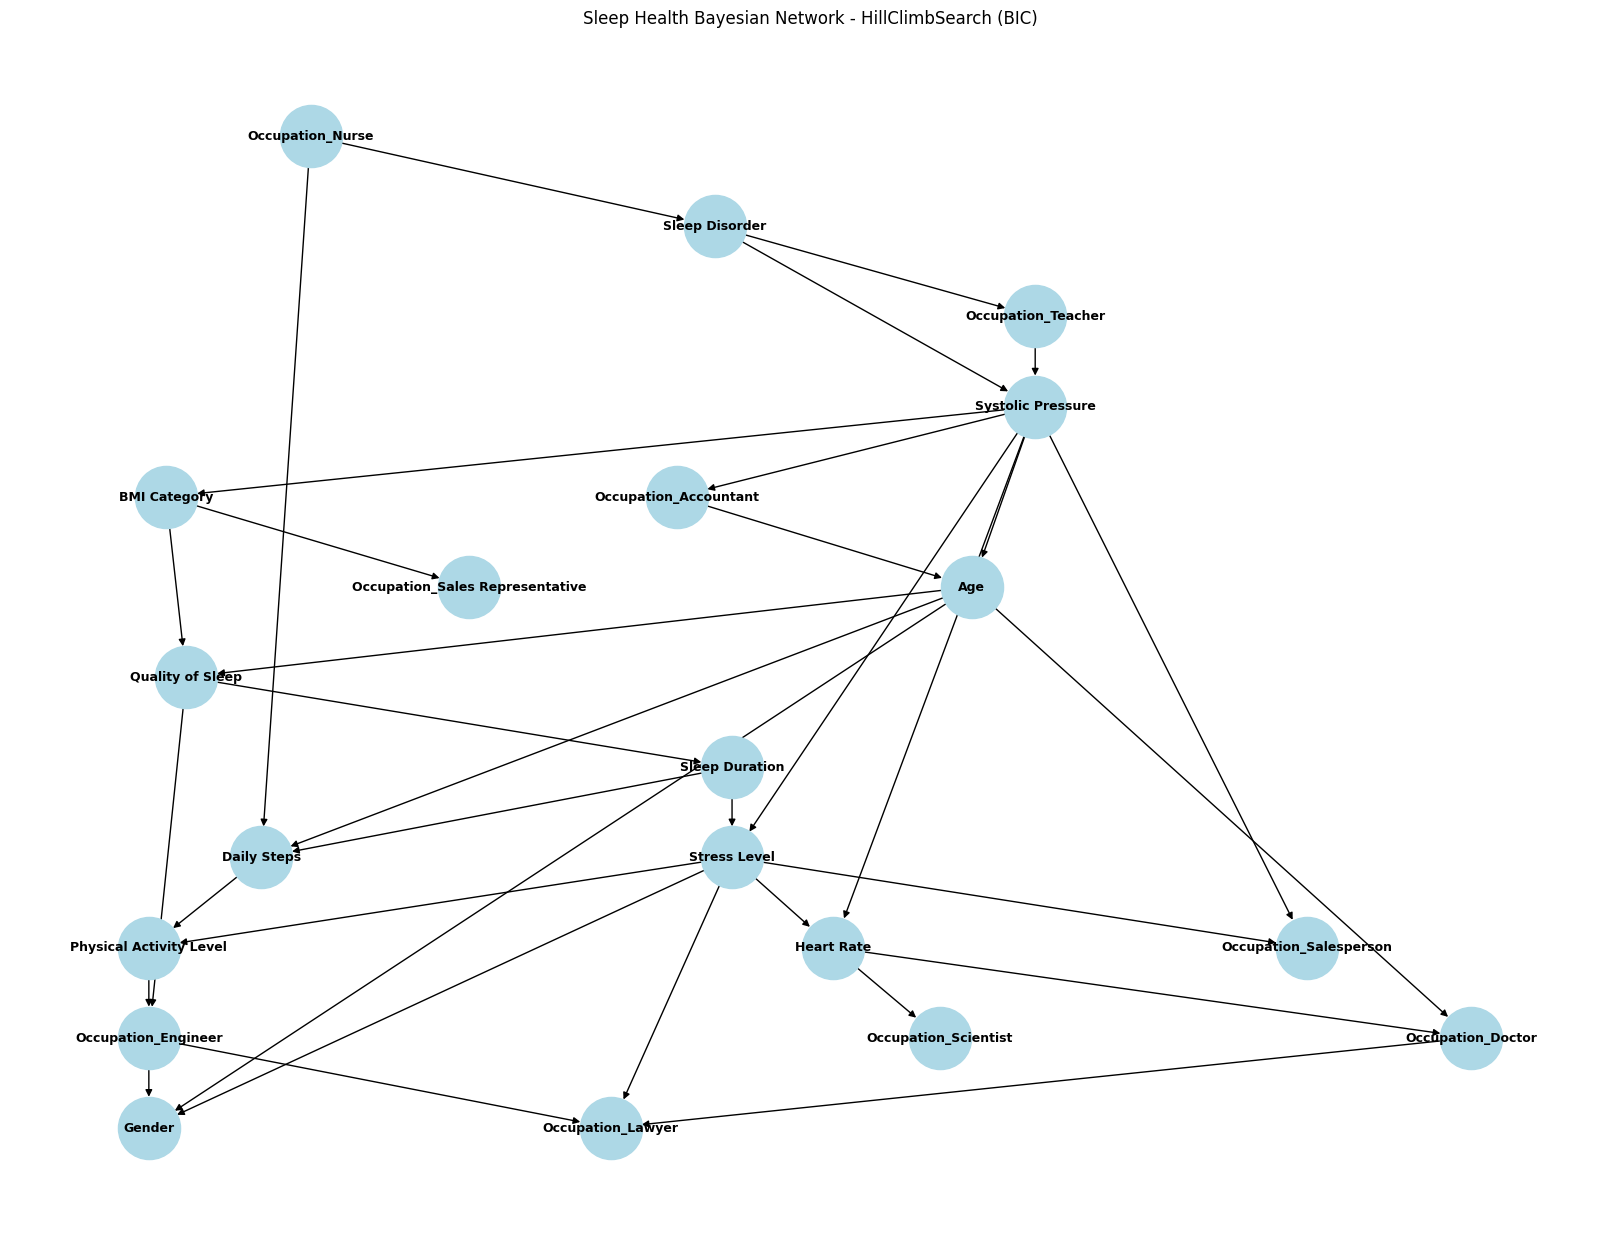

In [98]:
plt.figure(figsize=(16, 12))
G = nx.DiGraph(estimated_dag.edges())
nx.draw(
    G,
    pos=nx.nx_pydot.graphviz_layout(G, prog="dot"),
    with_labels=True,
    node_color='lightblue',
    edge_color='black',
    node_size=2000,
    font_size=9,
    font_weight='bold'
)
plt.title("Sleep Health Bayesian Network - HillClimbSearch (BIC)")
plt.show()

### Visualizing the Learned Structure

The layout confirms what the edge list suggested. Systolic Pressure, Age, and Stress Level stand out as the busiest nodes, each feeding into several other variables, so they act as hubs the rest of the network organizes around. Occupation categories cluster loosely on the outer edges of the graph, and the stress, sleep, and heart rate variables sit close together in the middle, consistent with the correlated cluster we saw earlier.
Occupation_Software Engineer and Occupation_Manager don't appear in this plot at all, since networkx only draws nodes that have at least one edge.

### Fitting the Conditional Probability Tables

The DAG from Hill Climbing only tells us which variables depend on which, not how strong those dependencies are. This cell builds a DiscreteBayesianNetwork from the learned edges and fits its CPDs from the data, turning the graph into a fully specified joint distribution we can query.

We fit with Maximum Likelihood Estimation. For each node, every conditional probability P(X = x | Parents(X) = u) is just the empirical frequency of that combination in the discretised data: count how often (x, u) occurs together, divide by how often u occurs on its own.


In [99]:
bn_model = DiscreteBayesianNetwork(estimated_dag.edges())

bn_model.fit(bn_data)

bn_model.check_model()
print("Model check passed.")
print(bn_model.get_cpds("Sleep Disorder"))

True

Model check passed.
+-------------------+---------------------+---------------------+
| Occupation_Nurse  | Occupation_Nurse(0) | Occupation_Nurse(1) |
+-------------------+---------------------+---------------------+
| Sleep Disorder(0) | 0.6976744186046512  | 0.1232876712328767  |
+-------------------+---------------------+---------------------+
| Sleep Disorder(1) | 0.05647840531561462 | 0.8356164383561644  |
+-------------------+---------------------+---------------------+
| Sleep Disorder(2) | 0.24584717607973422 | 0.0410958904109589  |
+-------------------+---------------------+---------------------+


The CPD for Sleep Disorder is a good first check. With Occupation_Nurse = 0 (not a nurse), the distribution is dominated by Sleep Disorder(0), "None", at about 70%, with smaller probabilities for Sleep Apnea (5.6%) and Insomnia (24.6%). Flip to Occupation_Nurse = 1 and the distribution flips sharply too: Sleep Apnea jumps to 83.6%, "None" drops to 12.3%, Insomnia to 4.1%. It's a striking conditional shift, and it lines up with the `Occupation_Nurse → Sleep Disorder` edge picked up by the structure search above: being a nurse is strongly associated with a Sleep Apnea diagnosis in this dataset.


### Inspecting the Local Structure Around `Sleep Disorder`

Now that the network is fitted, we can interrogate its local structure around the variable we actually care about, `Sleep Disorder`.

Parents and children only give the direct connections: who `Sleep Disorder` is conditioned on, and who is conditioned on it. For understanding what is actually relevant when querying the variable, the more useful object is the Markov blanket: parents, children, and the children's other parents (co-parents),

$$
\mathrm{MB}(X) = \mathrm{Pa}(X) \;\cup\; \mathrm{Ch}(X) \;\cup\; \left( \bigcup_{Y \in \mathrm{Ch}(X)} \mathrm{Pa}(Y) \right) \setminus \{ X \}
$$

It is the smallest set that renders $X$ conditionally independent of everything else in the graph:

$$
X \perp\!\!\!\perp Z \;\bigm|\; \mathrm{MB}(X)
\qquad \forall \, Z \in \mathcal{V} \setminus \left( \{X\} \cup \mathrm{MB}(X) \right)
$$

The quantifier matters here, and it is easy to misread. The guarantee holds once the entire blanket is observed. It says nothing about what happens when the blanket is only partially observed, or not observed at all, which is exactly the situation in the queries below, and exactly where the intuition is about to break.

Given how peripheral `Sleep Disorder` looked in the graph visualization, with one parent and two children, it is worth checking whether its Markov blanket turns out to be unexpectedly small before relying on any inference query involving it.

In [100]:
print(f"Parents of Sleep Disorder: {bn_model.get_parents('Sleep Disorder')}")
print(f"Children of Sleep Disorder: {bn_model.get_children('Sleep Disorder')}\n")

mb = bn_model.get_markov_blanket("Sleep Disorder")
print("Markov Blanket of Sleep Disorder:")
print(" ", mb)
print("\nThese are the only variables that directly affect P(Sleep Disorder | evidence).")

Parents of Sleep Disorder: ['Occupation_Nurse']
Children of Sleep Disorder: ['Systolic Pressure', 'Occupation_Teacher']

Markov Blanket of Sleep Disorder:
  ['Occupation_Nurse', 'Occupation_Teacher', 'Systolic Pressure']

These are the only variables that directly affect P(Sleep Disorder | evidence).


Sleep Disorder has one parent, Occupation_Nurse, and two children, Systolic Pressure and Occupation_Teacher. Pooling these together gives a Markov blanket of just three variables: Occupation_Teacher, Systolic Pressure, and Occupation_Nurse.

Once all three variables in the blanket are observed together, nothing else in the network can shift P(Sleep Disorder | evidence) any further. But that guarantee only holds when the full blanket is observed at once, not when only part of it is, which matters for how we read the queries coming up next.

### Querying the Network with Variable Elimination

With the network fitted, we can now compute conditional probabilities exactly, using VariableElimination. Instead of building the full joint distribution over all 22 variables, which isn't feasible at this scale, it multiplies and sums out factors one variable at a time, exploiting the DAG's factorization to keep intermediate computations small.

It's tempting to use the Markov blanket from the previous section to predict what happens here, but that guarantee doesn't actually apply to this setup. The blanket theorem says Sleep Disorder is independent of everything else once the blanket itself, Occupation_Nurse, Systolic Pressure, and Occupation_Teacher, is observed. It says nothing about conditioning on Stress Level or Quality of Sleep while leaving the blanket unobserved, which is exactly what the queries below do. With the blanket variables free, there can still be active, unblocked paths in the DAG connecting these two variables to Sleep Disorder, so a shift in the resulting distribution would be entirely consistent with the graph

In [101]:
inference_engine = VariableElimination(bn_model)

# Query 1: high stress, poor sleep quality → P(Sleep Disorder)?
q1 = inference_engine.query(
    variables=["Sleep Disorder"],
    evidence={"Stress Level": 2, "Quality of Sleep": 0},   # 2=high, 0=low
    show_progress=False
)
print("P(Sleep Disorder | Stress=high, Quality=low)")
print(q1)

# Query 2: low stress, good sleep → P(Sleep Disorder)?
q2 = inference_engine.query(
    variables=["Sleep Disorder"],
    evidence={"Stress Level": 0, "Quality of Sleep": 2},
    show_progress=False
)
print("\nP(Sleep Disorder | Stress=low, Quality=high)")
print(q2)

P(Sleep Disorder | Stress=high, Quality=low)
+-------------------+-----------------------+
| Sleep Disorder    |   phi(Sleep Disorder) |
+===================+=======================+
| Sleep Disorder(0) |                0.5828 |
+-------------------+-----------------------+
| Sleep Disorder(1) |                0.2091 |
+-------------------+-----------------------+
| Sleep Disorder(2) |                0.2081 |
+-------------------+-----------------------+

P(Sleep Disorder | Stress=low, Quality=high)
+-------------------+-----------------------+
| Sleep Disorder    |   phi(Sleep Disorder) |
+===================+=======================+
| Sleep Disorder(0) |                0.4580 |
+-------------------+-----------------------+
| Sleep Disorder(1) |                0.3655 |
+-------------------+-----------------------+
| Sleep Disorder(2) |                0.1764 |
+-------------------+-----------------------+


This result is more interesting than the "no change expected" prediction from before.

The two distributions are clearly different. With high stress and poor sleep quality, "None" sits at 58.3% and Insomnia at 20.8%. With low stress and good sleep, "None" drops to 45.8% while Sleep Apnea rises to 36.6%. So evidence on Stress Level and Quality of Sleep does move the posterior, contradicting what the Markov blanket alone suggested.

Here's the fix to that earlier reasoning. The Markov blanket only guarantees independence when the entire blanket is observed, not when a variable outside it is conditioned on while the blanket stays unobserved. Looking at the structure, there's an open path: Sleep Disorder → Systolic Pressure → Stress Level. This is a chain, and chains only block dependence when the middle node is observed. Systolic Pressure isn't part of the evidence here, so the chain stays open and information flows back from Stress Level to Sleep Disorder.

Quality of Sleep reaches Sleep Disorder through a subtler route: Quality of Sleep → Sleep Duration → Stress Level ← Systolic Pressure ← Sleep Disorder. Stress Level has two parents on this path, Sleep Duration and Systolic Pressure, making it a collider. Colliders normally block association, but conditioning on one has the opposite effect: it opens the path. Since Stress Level is part of the evidence, this path opens up too, and the remaining segment back to Sleep Disorder is an unobserved chain, so the whole route stays active.

So Stress Level reaches Sleep Disorder through a plain open chain, while Quality of Sleep reaches it through a path that only opens because Stress Level, a collider on that path, is being conditioned on.

### Comparing Against a Constraint-Based Structure: PC Algorithm

Hill Climbing gave us one structure, optimized greedily for BIC score, but it's better to check how much of that structure is an artifact of the search procedure itself versus a more robustly supported set of dependencies. We do this by learning a second structure with a fundamentally different paradigm: the PC algorithm, a constraint based method.

Where Hill Climbing asks which graph scores best overall, PC asks a more local question repeatedly: are these two variables conditionally independent given some subset of the others? It works in two phases. First, skeleton discovery: starting from a fully connected undirected graph, it tests pairs of variables for conditional independence with a chi squared test against growing subsets of the other variables, removing an edge whenever some conditioning set makes the pair independent at significance_level=0.05. Second, edge orientation: it identifies v structures (colliders, X → Z ← Y where X and Y aren't directly connected) from the pattern of independencies found, and propagates orientation rules from there to avoid introducing new v structures or cycles, though some edges can stay undirected if the data doesn't settle a direction. Using variant="stable" makes the skeleton discovery phase independent of the order variables happen to appear in the dataframe.

This makes PC considerably more conservative than Hill Climbing by construction. An edge only survives if the statistical test actively rejects independence at a fixed threshold, rather than being kept because it marginally improves a global score. We'd expect PC to recover a sparser graph, possibly with isolated nodes where no pairwise test found significant dependence, and any edges showing up in both structures would be the ones that we can trust most.

In [102]:
BaseConstraintEstimator._get_potential_sepsets = staticmethod(_get_potential_sepsets_sorted)
pc = PC(data=bn_data)
estimated_dag_pc = pc.estimate(
    variant="stable",
    ci_test="chi_square",
    significance_level=0.05,
    return_type="dag"
)

print(f"PC algorithm - Nodes: {len(estimated_dag_pc.nodes())}, Edges: {len(estimated_dag_pc.edges())}")
for e in sorted(estimated_dag_pc.edges()):
    print(f"  {e[0]}  →  {e[1]}")



  0%|          | 0/5 [00:00<?, ?it/s]

PC algorithm - Nodes: 22, Edges: 15
  Age  →  Systolic Pressure
  BMI Category  →  Age
  Daily Steps  →  Age
  Daily Steps  →  BMI Category
  Daily Steps  →  Heart Rate
  Daily Steps  →  Physical Activity Level
  Occupation_Accountant  →  Gender
  Occupation_Engineer  →  Occupation_Lawyer
  Occupation_Salesperson  →  Heart Rate
  Occupation_Teacher  →  Sleep Disorder
  Physical Activity Level  →  Stress Level
  Sleep Duration  →  Physical Activity Level
  Sleep Duration  →  Quality of Sleep
  Sleep Duration  →  Stress Level
  Stress Level  →  Quality of Sleep


The prediction holds up: PC found only 15 edges, less than half of Hill Climbing's 34. That's the kind of conservative, sparser result you'd expect from a method that only keeps an edge when a statistical test actively rejects independence. All 22 nodes are still present, but six end up with zero connections at all (Occupation_Software Engineer, Occupation_Manager, Occupation_Scientist, Occupation_Nurse, Occupation_Doctor, Occupation_Sales Representative), and eight more have just a single edge, matching the earlier note that PC tends to leave variables isolated when no pairwise test finds significant dependence at α = 0.05.

Comparing the two structures directly, the overlap is small but tells us something. Sleep Duration, Stress Level, Quality of Sleep, and Physical Activity Level show up connected to each other in both graphs, matching the stress and sleep cluster that's been a running theme through the notebook.  Beyond that the two structures diverge a lot. Hill Climbing's hub node Systolic Pressure barely registers here, with just one edge, while Age turns out more central in PC's graph than expected, with one outgoing edge to Systolic Pressure and two incoming from BMI Category and Daily Steps. Neither direction is especially causally clean, but at least it avoids the flatly implausible Occupation_Accountant causes Age edge that Hill Climbing produced.

Most relevant to our actual question: Sleep Disorder has a single edge here too, Occupation_Teacher → Sleep Disorder, different from Hill Climbing's parent, Occupation_Nurse, though both methods agree that some occupation variable directly drives the diagnosis, even if they disagree on which one. Neither Stress Level nor Quality of Sleep connects to Sleep Disorder here either, and unlike Hill Climbing's structure, PC offers no indirect path between them, since Occupation_Teacher has no other connections and Sleep Disorder is otherwise cut off from the rest of the graph.

<Figure size 1600x1200 with 0 Axes>

Text(0.5, 1.0, 'Sleep Health Bayesian Network - PC Algorithm (chi-square, α=0.05)')

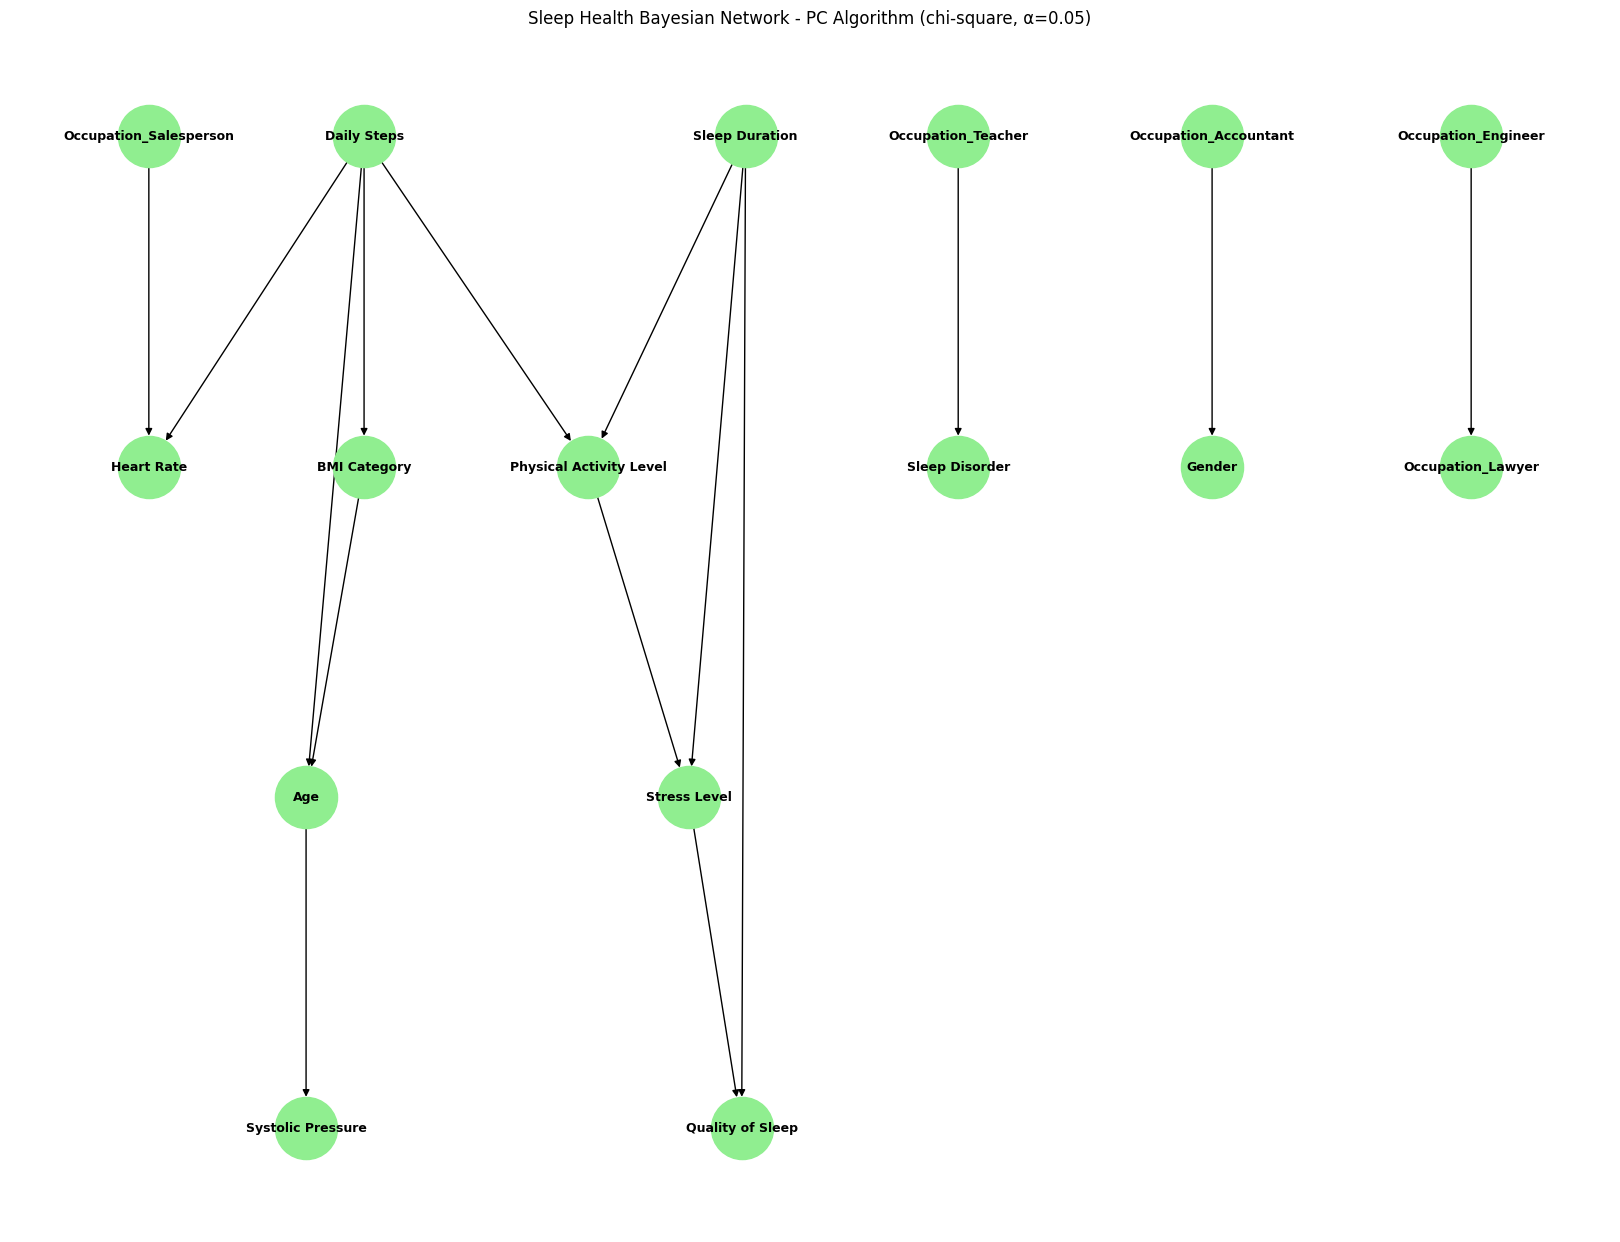

In [103]:
plt.figure(figsize=(16, 12))
G_pc = nx.DiGraph()
G_pc.add_edges_from(estimated_dag_pc.edges())

nx.draw(
    G_pc,
    pos=nx.nx_pydot.graphviz_layout(G_pc, prog="dot"),
    with_labels=True,
    node_color='lightgreen',
    edge_color='black',
    node_size=2000,
    font_size=9,
    font_weight='bold'
)
plt.title("Sleep Health Bayesian Network - PC Algorithm (chi-square, α=0.05)")
plt.show()

### Visualizing the PC Structure

The layout is much sparser than Hill Climbing's, as expected from a graph with less than half the edges. `Sleep Duration`, `Stress Level`, `Quality of Sleep` and `Physical Activity Level` form the one visibly connected chain in the middle, the same cluster that showed up in both structures. Everything else appears as short, disconnected fragments, `Occupation_Teacher → Sleep Disorder` sits on its own with no other connections, and `Age`, fed by `BMI Category` and `Daily Steps` and feeding into `Systolic Pressure`, is the closest thing to a hub this graph has.

As with the HillClimbSearch plot, `networkx` only draws nodes that appear in at least one edge, so the six fully isolated occupation categories (`Occupation_Software Engineer`, `Occupation_Manager`, `Occupation_Scientist`, `Occupation_Nurse`, `Occupation_Doctor`, `Occupation_Sales Representative`) don't appear in this figure at all, even though they're still part of the 22-node model.

### Quantifying the Agreement Between the Two Structures

The comparison above already suggested the two graphs diverge a lot. Here neither Hill Climbing's nor PC's output is a ground truth : they are estimates from the same finite, discretised dataset, produced by different learning paradigms. F1 in this context measures agreement between two estimation procedures, not correctness against reality.

Treating edge recovery as a binary classification problem over directed edges (direction counts, so A → B and B → A are different edges), with $E_{\text{HC}}$ and $E_{\text{PC}}$ the two edge sets,

$$
\mathrm{F1} = \frac{2 \, \lvert E_{\text{HC}} \cap E_{\text{PC}} \rvert}{\lvert E_{\text{HC}} \rvert + \lvert E_{\text{PC}} \rvert}
\;\in\; [0, 1]
$$

which is 0 when the two graphs share no edge and 1 when the edge sets are identical, direction included. The score is bounded above by the size mismatch alone: with 34 edges on one side and 15 on the other, even perfect recall of PC's edges would cap F1 at $2 \cdot 15 / 49 \approx 0.61$.

We rebuild both graphs explicitly with add_nodes_from before adding the edges. PC's graph has several isolated nodes that would otherwise be dropped silently, shrinking the comparison, and earlier on this raised a NetworkXError when the two node sets didn't match.

In [104]:
def f1_score(pred_model, ref_model) -> float:
    v = list(set(pred_model.nodes()) | set(ref_model.nodes()))

    G_pred = nx.DiGraph()
    G_pred.add_nodes_from(pred_model.nodes())
    G_pred.add_edges_from(pred_model.edges())

    G_ref = nx.DiGraph()
    G_ref.add_nodes_from(ref_model.nodes())
    G_ref.add_edges_from(ref_model.edges())

    pred_adj = nx.to_numpy_array(G_pred, nodelist=v, weight=None)
    ref_adj  = nx.to_numpy_array(G_ref,  nodelist=v, weight=None)

    return 2 * (pred_adj * ref_adj).sum() / (pred_adj.sum() + ref_adj.sum())

f1_hc_vs_pc = f1_score(estimated_dag, estimated_dag_pc)

print(f"F1-score (HillClimb vs PC): {f1_hc_vs_pc:.3f}")


F1-score (HillClimb vs PC): 0.122


An F1 score of 0.122 confirms that expectation: the two structures agree on very little. Since F1 combines precision and recall over the directed edge set, this low value reflects both a small absolute overlap (only about three of Hill Climbing's 34 edges and PC's 15 edges coincide, direction included) and a large mismatch in scale between the two graphs. With 34 versus 15 edges, even perfect recall of PC's edges by Hill Climbing would only produce a moderate F1 at best, since Hill Climbing carries so many extra edges PC doesn't support.

 This level of disagreement tells us a sizeable share of the dependencies Hill Climbing found, including Sleep Disorder's link to Occupation_Nurse and the Systolic Pressure centred hub structure that drove the earlier inference result, aren't corroborated by an independent, more statistically conservative method on the same data. That doesn't make them wrong. PC's stricter significance threshold and pairwise conditional testing can also miss real but subtle dependencies, especially with only 374 observations split across discretised bins. But it does mean those specific edges should be treated as hypotheses suggested by one search procedure, not well established structure.

### Validating Exact Inference with Sampling

The earlier VariableElimination result was surprising enough, Stress Level and Quality of Sleep shifting P(Sleep Disorder) despite sitting outside the Markov blanket, through an indirect path via Systolic Pressure. We use ApproxInference to independently estimate the same two conditional queries and compare against the exact VariableElimination answer.

Unlike VariableElimination, which computes the exact answer algebraically by systematically summing out irrelevant variables, ApproxInference draws samples from the network consistent with the supplied evidence and estimates the conditional probability as the empirical frequency in those samples. It's a Monte Carlo estimator, so it carries sampling noise that shrinks as the number of samples grows, but it doesn't rely on the same factorization machinery as variable elimination. If it converges to the same answer, that's strong independent confirmation the surprising result isn't a bug or misapplied evidence, but a genuine property of the fitted network.

We sweep four sample sizes, from 100 to 100,000, for each of the two evidence configurations  expecting the approximate estimates to get progressively closer to the exact value as sample size grows.

In [105]:
approx_inference_engine = ApproxInference(bn_model)

evidence_sets = {
    "Stress=high, Quality=low": {"Stress Level": 2, "Quality of Sleep": 0},
    "Stress=low, Quality=high": {"Stress Level": 0, "Quality of Sleep": 2},
}

sample_sizes = [100, 1_000, 10_000, 100_000]

for label, evidence in evidence_sets.items():
    print(f"\n=== P(Sleep Disorder | {label}) ===")

    p_exact = inference_engine.query(
        variables=["Sleep Disorder"], evidence=evidence, show_progress=False
    )

    approx_results = []
    for n in sample_sizes:
        p_approx = approx_inference_engine.query(
            variables=["Sleep Disorder"],
            evidence=evidence,
            n_samples=n,
            seed=42
        )
        approx_results.append(p_approx)
        print(f"  n_samples={n:>7}: {p_approx.values}")

    print(f"  EXACT (VariableElimination): {p_exact.values}")


=== P(Sleep Disorder | Stress=high, Quality=low) ===


  0%|          | 0/100 [00:00<?, ?it/s]

  n_samples=    100: [0.57 0.19 0.24]


  0%|          | 0/1000 [00:00<?, ?it/s]

  n_samples=   1000: [0.588 0.228 0.184]


...

  n_samples=   1000: [0.342 0.474 0.184]


  0%|          | 0/10000 [00:00<?, ?it/s]

  n_samples=  10000: [0.3597 0.4631 0.1772]


  0%|          | 0/100000 [00:00<?, ?it/s]

  n_samples= 100000: [0.45504 0.36675 0.17821]
  EXACT (VariableElimination): [0.4580311  0.36552583 0.17644307]


The validation looks exactly like we hoped. For both evidence configurations, the approximate estimates start out noisy at n_samples=100 (e.g. [0.57, 0.19, 0.24] versus the eventual [0.583, 0.209, 0.208] for the first query, already fairly close, but [0.28, 0.58, 0.14] versus [0.458, 0.366, 0.176] for the second, a much bigger gap at small sample sizes), then converge toward the exact VariableElimination answer as sample size grows, landing within about half a percentage point of the exact values by n_samples=100,000 in both cases ([0.584, 0.209, 0.207] versus exact [0.583, 0.209, 0.208]; [0.455, 0.367, 0.178] versus exact [0.458, 0.366, 0.176]). This is Monte Carlo convergence, with error shrinking roughly as sample size grows, and it's solid, independent confirmation that the earlier result, stress and sleep quality genuinely shifting P(Sleep Disorder) despite sitting outside the formal Markov blanket, wasn't an artifact of a misapplied query or a bug in VariableElimination. Two structurally different inference algorithms agree.

The second evidence set (Stress=low, Quality=high) converges more slowly and noisily than the first. Even at n_samples=1,000 it's still [0.342, 0.474, 0.184], visibly off from the eventual [0.455, 0.367, 0.176], whereas the first query is already close by n=1,000. This makes sense given how forward sampling works. ApproxInference generates samples from the joint distribution and then conditions on the subset matching the evidence, so an evidence configuration that corresponds to a rarer combination of states will naturally have fewer matching samples at any given n_samples, producing noisier early estimates. Not a flaw in the method, just a reminder that the effective sample size behind a conditional query depends on how likely that evidence is under the model in the first place.


### Visualizing the Convergence

The numbers above already show the approximate estimates closing in on the exact answer, but a bar chart makes the convergence pattern immediately obvious. We rebuild the same query (Stress=high, Quality=low) across all four sample sizes plus the exact result, lay them out side by side as grouped bars per state of Sleep Disorder, and expect the APPROX bars to visibly tighten toward the EXACT bar as sample size increases, with n_samples=100 showing the most visible deviation and n_samples=100,000 nearly indistinguishable from EXACT.

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/100000 [00:00<?, ?it/s]

<Axes: >

Text(0.5, 1.0, 'Approximate vs Exact Inference - P(Sleep Disorder | Stress=high, Quality=low)')

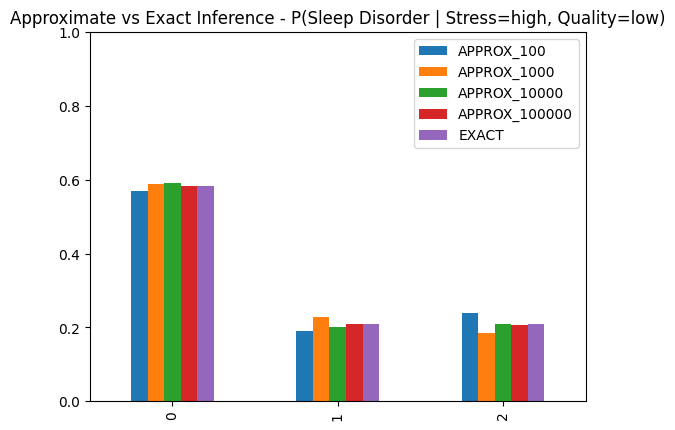

In [106]:
evidence = evidence_sets["Stress=high, Quality=low"]
p_exact = inference_engine.query(variables=["Sleep Disorder"], evidence=evidence, show_progress=False)

approx_p = []
for n in sample_sizes:
    p = approx_inference_engine.query(
        variables=["Sleep Disorder"], evidence=evidence, n_samples=n, seed=42
    )
    approx_p.append(p)

all_p = pd.DataFrame({
    ("APPROX_" + str(n)): p.values
    for n, p in zip(sample_sizes, approx_p)
})
all_p["EXACT"] = p_exact.values
all_p.index = p_exact.state_names["Sleep Disorder"]

all_p.plot.bar(ylim=(0, 1))
plt.title("Approximate vs Exact Inference - P(Sleep Disorder | Stress=high, Quality=low)")
plt.show()

The chart confirms visually what the numbers already showed. For state 0 ("None"), all five bars sit within a hair of each other around 0.58 to 0.59, with APPROX_100 only barely visible as lower. States 1 and 2 (Sleep Apnea and Insomnia) show the convergence more clearly. APPROX_100 is a clear outlier in both, overshooting on state 2 (about 0.24 versus an eventual 0.21) and undershooting on state 1 (about 0.19 versus 0.21). APPROX_1000 is also a visible outlier on these two states, just in the opposite direction: it overshoots state 1 (0.228, even higher than EXACT) and undershoots state 2 (0.184). Only from APPROX_10000 onward do the bars settle in tightly with EXACT.
